# Travelling Salesman Problem

## Introduction

Travelling salesman problem is one of the most research oriented problem which has been ongoing for decades. Finding the shortest path from different combination is a challenging task as a result of it the situation gets complicated when the number of city increases one of the reason behind this is the different combination. In this workbook
* An algorithm from single state search was chosen
* An evolutionary algorithm was chosen

There were justification behind choosing those algorithm. After choosing those algorithm by doing statistical analysis the best algorithm and best route was found.  

Reading the Dataset
We will read the dataset and csv file using pandas also we will use some more libraries like numpy and matplotlib for data manipulation and visualization.

# Part 1: Libraries and Helper Function 

In [2]:
# Installing required packages used in this notebook
!pip install pandas
!pip install numpy
!pip install seaborn
!pip install scipy

In [24]:
import pandas as pd  # For data manipulation
import numpy as np # For numerical operations
import time
import random  # For random number generation
from typing import List, Tuple # For type hinting
from itertools import product
import csv
import seaborn as sns
from scipy.stats import ttest_rel
#import warnings
#warnings.filterwarnings("ignore")


In [25]:
# Loading the dataset
cities_df = pd.read_csv('../data/cities.csv')
cities_df.head()

,City,X,Y
0,City_1,37.454012,95.071431
1,City_2,73.199394,59.865848
2,City_3,15.601864,15.599452
3,City_4,5.808361,86.617615
4,City_5,60.111501,70.807258


## Here we will select 5 cities as a part of sampling

In [26]:
# Selecting the 5 samples from dataset
sample_cities = cities_df.head(5)
#sample_cities = cities_df
sample_cities

,City,X,Y
0,City_1,37.454012,95.071431
1,City_2,73.199394,59.865848
2,City_3,15.601864,15.599452
3,City_4,5.808361,86.617615
4,City_5,60.111501,70.807258


In [27]:
#Here I am extracting the coordinates
cities = sample_cities[['X', 'Y']].values.astype(float)
cities

array([[37.45401188, 95.07143064],
       [73.19939418, 59.86584842],
       [15.60186404, 15.59945203],
       [ 5.80836122, 86.61761458],
       [60.11150117, 70.80725778]])

# Measuring distance : Now we will follow euclidean distance to find the shortest distance between 2 points.

## Helper functions

In [28]:
#Function for calculating euclidean distance
def euclidean_distance(city1: Tuple[float, float], city2: Tuple[float, float]) -> float:
    return np.sqrt((city1[0] - city2[0])**2 + (city1[1] - city2[1])**2)

In [29]:
#Sample distance calculation between 2 cities
"""
This is a sample how the line of code is calculating distance . 
From the sample_cities variable we are taking the iloc and the X and Y coordinate values. After that passing this in the euclidean 
distance function which is calculating the distance between 2 points
"""
print(euclidean_distance((sample_cities.iloc[0]['X'], sample_cities.iloc[0]['Y']), (sample_cities.iloc[1]['X'], sample_cities.iloc[1]['Y'])))

50.17136010935256


Now we will create a function which will calculate total distance from a list

In [30]:
# Here this function does a total tour and calculates the net covered distance
# Each time the loop is running it is adding distance covered and upto returning
"""
This function is calculating total distance covered. Here we are passing a list of the available paths and then it is going in 
a loop which is adding distance between 2 cities and then doing a sum
"""
def calculate_total_distance(tour: List[int], cities: np.ndarray) -> float:
    total_dist = 0.0
    for i in range(len(tour)):
        city1 = cities[tour[i]]
        city2 = cities[tour[(i + 1) % len(tour)]]
        total_dist += euclidean_distance(city1, city2)
    return total_dist

In [31]:
def cities_based_on_numbers (number):
    return cities_df.head(number)[['X', 'Y']].values.astype(float)

## Setting Global Variable

In [9]:
# Here we will select 5 cities based on sample numbers
cities_coords = cities_based_on_numbers(20)
cities_coords

array([[37.45401188, 95.07143064],
       [73.19939418, 59.86584842],
       [15.60186404, 15.59945203],
       [ 5.80836122, 86.61761458],
       [60.11150117, 70.80725778],
       [ 2.05844943, 96.99098522],
       [83.24426408, 21.23391107],
       [18.18249672, 18.34045099],
       [30.4242243 , 52.47564316],
       [43.19450186, 29.12291402],
       [61.18528947, 13.94938607],
       [29.21446485, 36.63618433],
       [45.60699842, 78.51759614],
       [19.96737822, 51.42344384],
       [59.24145689,  4.64504127],
       [60.75448519, 17.05241237],
       [ 6.5051593 , 94.88855373],
       [96.56320331, 80.83973481],
       [30.46137692,  9.7672114 ],
       [68.42330265, 44.01524937]])

# Part 2 : Single Solution Algorithm Implementation

For better understanding and clean code we will apply the theory of object orientation. We will create a class for each individual type of algorithm.
Here we will use simulated annealing algorithmy.

## Reason Behind not Choosing Hill Climbing

The reason Tabu Search is preferred over standard hill climbing is that it has the ability to move out of a poor local solution and search a wider area, which is particularly important for challenging problems like the Travelling Salesman Problem. Hill climbing search has a very simplistic approach where it usually moves from a solution to a better neighbor, getting trapped in a local optimum or a plateau in no time, with no memory of where it has been so that it does not revisit all the solutions; Tabu Search begins with a similar concept of hill climbing but employs a short-term memory component called the tabu list, also permitting moves that are not optimal, with no use of moves that are recently employed, such that it systematically forces a search in other areas and usually finds a better-quality solution as compared to hill climbing, which can be employed in a more robust algorithm where the emphasis shifts from finding a shorter route.

## Simulated Annealing

In [32]:
class SimulatedAnnealing:
    """
    Simulated Annealing algorithm for solving TSP.

    This algorithm uses a probabilistic approach to escape local optima
    by accepting worse solutions with a probability that decreases over time.

    Time Complexity: O(iterations * n) where n is number of cities
    Space Complexity: O(n) for storing the tour
    """

    def __init__(self, cities: np.ndarray, initial_temp: float = 10000,
                 cooling_rate: float = 0.995, min_temp: float = 0.1):
        """
        Initialize Simulated Annealing algorithm.
        
        Args:
            cities: Array of city coordinates
            initial_temp: Starting temperature
            cooling_rate: Rate at which temperature decreases
            min_temp: Minimum temperature threshold
        """
        self.cities = cities
        self.n_cities = len(cities)
        self.initial_temp = initial_temp
        self.cooling_rate = cooling_rate
        self.min_temp = min_temp
        self.best_tour = None
        self.best_distance = float('inf')
        self.history = []

    def get_initial_solution(self):
        """
        Generate initial random solution.

        Time Complexity: O(n)
        Space Complexity: O(n)
        """
        tour = list(range(self.n_cities))
        random.shuffle(tour)
        return tour

    def get_neighbor(self, tour: List[int]):
        """
        Generating neighbor solution using 2-opt swap.

        Time Complexity: O(n)
        Space Complexity: O(n)
        """
        new_tour = tour.copy()
        i, j = sorted(random.sample(range(self.n_cities), 2))
        new_tour[i:j+1] = reversed(new_tour[i:j+1])
        return new_tour   

    def acceptance_probability(self, current_dist: float, new_dist: float,
                              temp: float):
        """
        Here we will calculate the probability of acccepting a worse solution 
        
        Time Complexity: O(1)
        Space Complexity: O(1)
        """
        if new_dist < current_dist:
            return 1.0
        return np.exp((current_dist - new_dist) / temp) 

    def solve(self, max_iterations: int = 10000):
        """
        here max_iterations is the Maximum number of iterations to run, we need a number of iterations for this algorithm
    
        This is how the function will work. 
        It will start with a random tour, then will try a small random change in the neighbor. If the tour is better it will 
        accept it else if it is worse then it will accept with a probability which depends on the temperature. 

        """
    
        # Generating initial random solution at first 
        current_tour = self.get_initial_solution()
    
        # After getting the current tour we will calculate the total distance which we declared earlier
        current_dist = calculate_total_distance(current_tour, self.cities)
    
        # Store the current best solution
        self.best_tour = current_tour.copy()
        self.best_distance = current_dist
    

        # Here we will initialize simulated annealing temperature and iteration counter
        temperature = self.initial_temp
        iteration = 0

        ## Adding a history collector for first iteration 
        self.history = [{
            'iteration': iteration,
            'temperature': temperature,
            'current_distance': current_dist,
            'best_distance': self.best_distance,
            'tour': current_tour.copy()
        }]
        
        # In this part we call a loop this loop is under while loop and it will run until the temperature is too low
        # Also after reaching maximum iterations
        while temperature > self.min_temp and iteration < max_iterations:
    
            # Here we are generating a neighbor of the current solution 
            new_tour = self.get_neighbor(current_tour)
    
            # Now calculating the total distance of the tour using previously declared function
            new_dist = calculate_total_distance(new_tour, self.cities)

            """Here now we will decide whether to accept the new tour or reject
            We compare new distance with current distance if the current distance is smaller than new distance then we 
            accept it other wise we will accept with probability 
            """

            if self.acceptance_probability(current_dist, new_dist, temperature) > random.random():
                # Accept move
                current_tour = new_tour
                current_dist = new_dist

                if current_dist < self.best_distance:
                    self.best_tour = current_tour.copy()
                    self.best_distance = current_dist
    
            # Here we will cool down the temperature by updating the old cooling temperature with cooling rate
            # This reduces the probability of accepting worse moves
            # as the algorithm progresses.
            temperature *= self.cooling_rate
    
            # Increasing iteration counter
            iteration += 1
    
            # Saving every 100 iterations
            if iteration % 100 == 0:
                self.history.append({
                    'iteration': iteration,
                    'temperature': temperature,
                    'current_distance': current_dist,
                    'best_distance': self.best_distance,
                    'tour': current_tour.copy()
                })
    
        return self.best_tour, self.best_distance


## Running the experiment on simulated annealing

In [11]:

print("Single  1: SIMULATED ANNEALING")

# Set seed for reproducibility
random.seed(42)
np.random.seed(42)

# Initialize and run simulated annealing
sa = SimulatedAnnealing(
    cities=cities_coords,
    initial_temp=10000,
    cooling_rate=0.995,
    min_temp=0.1
)
# Starting the timer to measure execution time
start_time = time.time()
# Measuring total execution time
sa_best_tour, sa_best_distance = sa.solve(max_iterations=10000)
sa_time = time.time() - start_time

print(f"\nHyperparameters:")
print(f"Initial Temperature: {sa.initial_temp}")
print(f"Cooling Rate: {sa.cooling_rate}")
print(f"Minimum Temperature: {sa.min_temp}")
print(f"Max Iterations: 10000")

print(f"\nResults:")
print(f"Best Tour: {[f'City_{i+1}' for i in sa_best_tour]}")
print(f"Best Distance: {sa_best_distance:.4f}")
print(f"Execution Time: {sa_time:.4f} seconds")
print(f"Iterations Completed: {len(sa.history) * 100}")

# Saving simulated annealing results
sa_tour_sequence = [f"City_{i+1}" for i in sa_best_tour]
sa_results_df = pd.DataFrame({
    'Position': range(1, len(sa_tour_sequence) + 1),
    'City': sa_tour_sequence
})


Single  1: SIMULATED ANNEALING

Hyperparameters:
Initial Temperature: 10000
Cooling Rate: 0.995
Minimum Temperature: 0.1
Max Iterations: 10000

Results:
Best Tour: ['City_7', 'City_20', 'City_2', 'City_18', 'City_5', 'City_13', 'City_1', 'City_17', 'City_6', 'City_4', 'City_14', 'City_9', 'City_12', 'City_10', 'City_8', 'City_3', 'City_19', 'City_15', 'City_11', 'City_16']
Best Distance: 386.6267
Execution Time: 0.0992 seconds
Iterations Completed: 2300


## Tabu Search 

First we will create a class about tabu search to implement the tabu search feature. Using this we will find difference between the time and space complexity for 5 and 10 solution. Then according to that we will take decision which single solution algorithm we will chose to compare with genetic algorithm 

In [34]:
# We will consider this one as better option because we are passing neighbor sample size, stall limit comparing to the previous one
class TabuSearch:
    """
    Enhanced Tabu Search for TSP with:
    - neighborhood sampling
    - stall detection
    - diversification
    - aspiration criterion
    """

    def __init__(self,cities,tabu_size=20,max_iterations=1000,neighborhood_sample_size=None,stall_limit=50,aspiration=True,diversify_after=None):
        self.cities = cities
        self.n = len(cities)

        # Hyperparameters
        self.tabu_size = tabu_size
        self.max_iterations = max_iterations
        self.neighborhood_sample_size = neighborhood_sample_size
        self.stall_limit = stall_limit
        self.aspiration = aspiration
        self.diversify_after = diversify_after

        # Internal
        self.best_tour = None
        self.best_distance = float("inf")
        self.history = []


    def get_initial_solution(self):
        tour = list(range(self.n))
        random.shuffle(tour)
        return tour


    def get_neighbors(self, tour):
        """
        Generate neighbors using all possible 2-opt swaps.

        Time Complexity: O(n^2)
        Space Complexity: O(n^2) for storing neighbors
        """

        neighbors = []
        all_pairs = [(i, j) for i in range(self.n - 1)
                            for j in range(i + 1, self.n)]

        # Sampling for speed
        if self.neighborhood_sample_size is not None:
            pairs = random.sample(
                all_pairs,
                min(self.neighborhood_sample_size, len(all_pairs))
            )
        else:
            pairs = all_pairs

        for i, j in pairs:
            new_tour = tour.copy()
            new_tour[i], new_tour[j] = new_tour[j], new_tour[i]
            neighbors.append((new_tour, (i, j)))

        return neighbors


    def solve(self):
        """
        Main Tabu Search loop.

        Steps:
        1. We will start with a random solution
        2. Evaluate all 2-opt neighbors
        3. Pick best non-tabu (or improving tabu) move
        4. Update tabu list
        5. Track global best
        """
        # Initial solution
        current_tour = self.get_initial_solution()
        current_distance = calculate_total_distance(current_tour, self.cities)

        self.best_tour = current_tour.copy()
        self.best_distance = current_distance

        tabu_list = []
        stall_counter = 0

        for iteration in range(1, self.max_iterations + 1):

            neighbors = self.get_neighbors(current_tour)

            best_move = None
            best_neighbor = None
            best_neighbor_distance = float("inf")

            for tour_candidate, move in neighbors:
                dist = calculate_total_distance(tour_candidate, self.cities)

                # Check tabu
                tabu_forbidden = move in tabu_list

                # Aspiration criterion: override tabu if better than global best
                if tabu_forbidden and not (self.aspiration and dist < self.best_distance):
                    continue

                # Pick best neighbor
                if dist < best_neighbor_distance:
                    best_neighbor_distance = dist
                    best_neighbor = tour_candidate
                    best_move = move

            # If no valid neighbors, allow tabu moves
            if best_neighbor is None:
                best_neighbor, best_move = min(
                    neighbors,
                    key=lambda x: calculate_total_distance(x[0], self.cities)
                )
                best_neighbor_distance = calculate_total_distance(best_neighbor, self.cities)

            # Update state
            current_tour = best_neighbor
            current_distance = best_neighbor_distance

            # Update tabu list
            tabu_list.append(best_move)
            if len(tabu_list) > self.tabu_size:
                tabu_list.pop(0)

            # Check improvement
            if current_distance < self.best_distance:
                self.best_tour = current_tour.copy()
                self.best_distance = current_distance
                stall_counter = 0  # reset stall
            else:
                stall_counter += 1

            # Early stop on stall limit
            if self.stall_limit and stall_counter >= self.stall_limit:
                break

            # Diversify if requested
            if self.diversify_after and stall_counter >= self.diversify_after:
                current_tour = self.get_initial_solution()
                current_distance = calculate_total_distance(current_tour, self.cities)
                stall_counter = 0

            # Save history every few iterations
            if iteration % 10 == 0:
                self.history.append({
                    "iteration": iteration,
                    "current_distance": current_distance,
                    "best_distance": self.best_distance,
                    'tour': current_tour.copy()
                })

        return self.best_tour, self.best_distance

## Running the experiment on Tabu Search

In [14]:
print("Single  2: TABU SEARCH")

# Set seed for reproducibility
random.seed(42)
ts = TabuSearch(cities=cities_coords, tabu_size=10, max_iterations=500)
start = time.time()
ts_best_tour, ts_best_distance = ts.solve()
ts_time = time.time() - start

print(f'Best Tabu tour (5 cities): {[f"City_{i+1}" for i in ts_best_tour]}')
print(f'Best Tabu distance: {ts_best_distance:.3f}, Execution time: {ts_time:.4f}s')

Single  2: TABU SEARCH
Best Tabu tour (5 cities): ['City_4', 'City_6', 'City_17', 'City_1', 'City_13', 'City_5', 'City_18', 'City_2', 'City_20', 'City_7', 'City_16', 'City_11', 'City_15', 'City_19', 'City_3', 'City_8', 'City_10', 'City_12', 'City_9', 'City_14']
Best Tabu distance: 386.627, Execution time: 0.7875s


In [15]:
# This tabu search is with neighborhood sample size and stall limit
print("Single  2: TABU SEARCH")

# Set seed for reproducibility
random.seed(42)

ts = TabuSearch(
    cities=cities_coords,
    tabu_size=10,                 # length of tabu list
    max_iterations=500,           # max allowed iterations
    neighborhood_sample_size=200, # sample 200 neighbors instead of full n^2
    stall_limit=80,               # stop early if no improvement for 80 iterations
    aspiration=True,              # allow tabu override if it improves global best
    diversify_after=120           # restart if stuck too long
)


start = time.time()
ts_best_tour, ts_best_distance = ts.solve()
ts_time = time.time() - start

print(f"Best Tabu tour: {[f'City_{i+1}' for i in ts_best_tour]}")
print(f"Best Tabu distance: {ts_best_distance:.3f}, Execution time: {ts_time:.4f}s")


Single  2: TABU SEARCH
Best Tabu tour: ['City_4', 'City_6', 'City_17', 'City_1', 'City_13', 'City_5', 'City_18', 'City_2', 'City_20', 'City_7', 'City_15', 'City_11', 'City_16', 'City_10', 'City_19', 'City_3', 'City_8', 'City_12', 'City_9', 'City_14']
Best Tabu distance: 386.430, Execution time: 1.4093s


The time complexity we saw in here it shows that the execution time difference and covered distance difference is so low. In this context we will try with larger set of datas and find the best one. 

In [16]:
print ('Simulated Annealing')
# Set seed for reproducibility
random.seed(42)
np.random.seed(42)

# Initialize and run simulated annealing
sa = SimulatedAnnealing(
    cities=cities_coords,
    initial_temp=10000,
    cooling_rate=0.995,
    min_temp=0.1
)

start_time = time.time()
sa_best_tour, sa_best_distance = sa.solve(max_iterations=10000)
sa_time = time.time() - start_time

print(f"\nResults:")
print(f"Best Tour: {[f'City_{i+1}' for i in sa_best_tour]}")
print(f"Best Distance: {sa_best_distance:.4f}")
print(f"Execution Time: {sa_time:.4f} seconds")
print(f"Iterations Completed: {len(sa.history) * 100}")

# Saving simulated annealing results
sa_tour_sequence = [f"City_{i+1}" for i in sa_best_tour]
sa_results_df = pd.DataFrame({
    'Position': range(1, len(sa_tour_sequence) + 1),
    'City': sa_tour_sequence
})

##
print ('\n\n')
print("TABU SEARCH")

# Set seed for reproducibility
random.seed(42)
ts = TabuSearch(cities=cities_coords, tabu_size=10, max_iterations=1000 ,neighborhood_sample_size=200,stall_limit=80)
start = time.time()
ts_best_tour, ts_best_distance = ts.solve()
ts_time = time.time() - start

print(f'Best Tabu tour : {[f"City_{i+1}" for i in ts_best_tour]}')
print(f'Best Tabu distance: {ts_best_distance:.3f}, Execution time: {ts_time:.4f}s')

Simulated Annealing

Results:
Best Tour: ['City_7', 'City_20', 'City_2', 'City_18', 'City_5', 'City_13', 'City_1', 'City_17', 'City_6', 'City_4', 'City_14', 'City_9', 'City_12', 'City_10', 'City_8', 'City_3', 'City_19', 'City_15', 'City_11', 'City_16']
Best Distance: 386.6267
Execution Time: 0.0906 seconds
Iterations Completed: 2300



TABU SEARCH
Best Tabu tour : ['City_4', 'City_6', 'City_17', 'City_1', 'City_13', 'City_5', 'City_18', 'City_2', 'City_20', 'City_7', 'City_15', 'City_11', 'City_16', 'City_10', 'City_19', 'City_3', 'City_8', 'City_12', 'City_9', 'City_14']
Best Tabu distance: 386.430, Execution time: 1.3866s


As we can see comparing the results the execution time is more for tabu search and for simulated annealing it is very less time just for 20 cities. Even though simulated annealing is showing more efficiency in here but tabu search wins in this context as our goal is to find the shortest distance. 

## Tabu Search Analysis

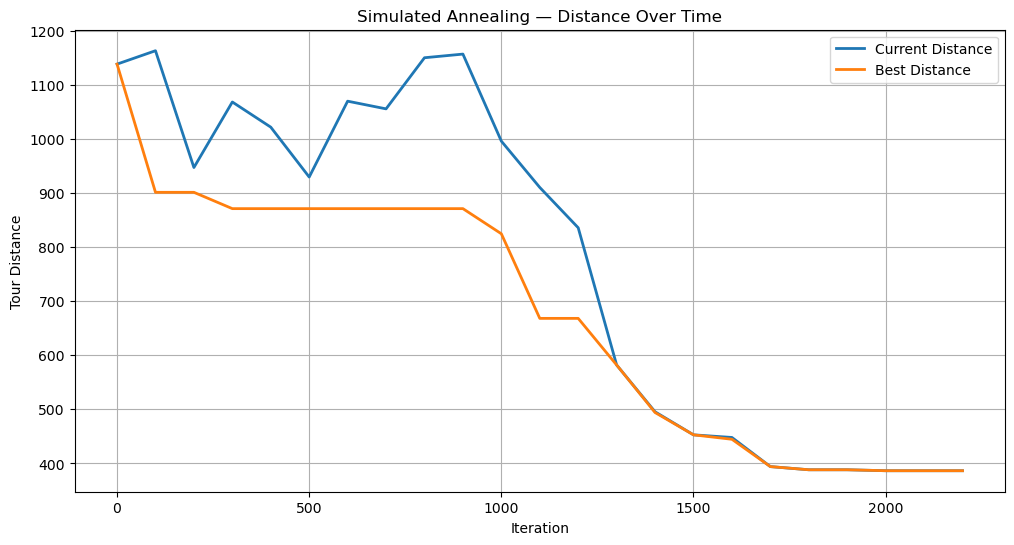

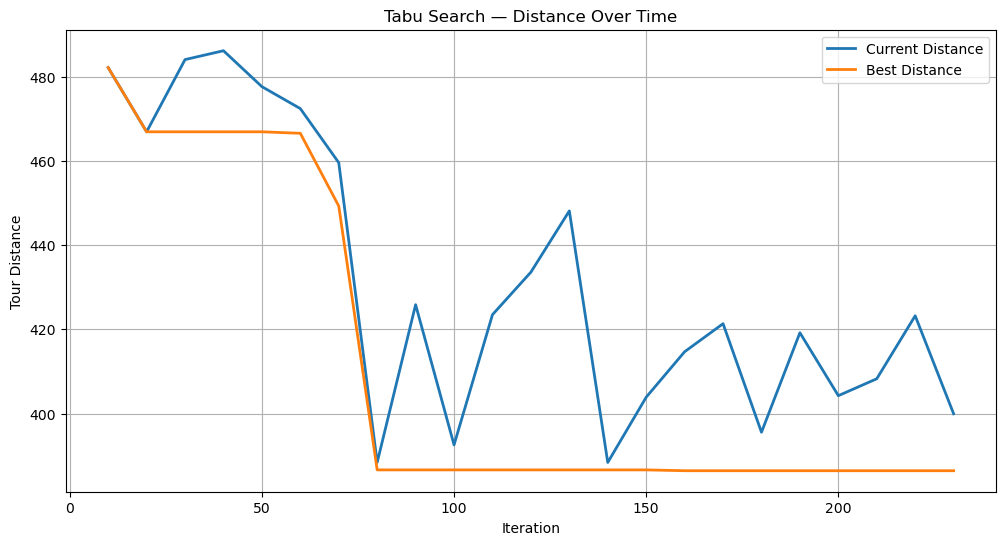

In [17]:
# Generative ai help was taken for plotting the graph
import matplotlib.pyplot as plt

# This is the plot for simulated annealing
def plot_sa_history(sa_history):
    """
    Plot of Simulated Annealing performance over iterations.
    Here sa_history is the list of dictionaries which contains iteration , temperature , current_distance and best_distance
    We have appended inside sa history in the solve function 
    """
    iterations = [h['iteration'] for h in sa_history]
    current_distances = [h['current_distance'] for h in sa_history]
    best_distances = [h['best_distance'] for h in sa_history]

    plt.figure(figsize=(12, 6))
    plt.plot(iterations, current_distances, label="Current Distance", linewidth=2)
    plt.plot(iterations, best_distances, label="Best Distance", linewidth=2)

    plt.xlabel("Iteration")
    plt.ylabel("Tour Distance")
    plt.title("Simulated Annealing — Distance Over Time")
    plt.grid(True)
    plt.legend()
    plt.show()

# Calling the function using sa
plot_sa_history(sa.history)

# This is the plot for tabu search 


def plot_tabu_history(ts_history):
    """
    Plot Tabu Search performance over iterations.
    ts_history is the list of dictionaries with:
        - iteration
        - current_distance
        - best_distance
    """
    iterations = [h['iteration'] for h in ts_history]
    current_distances = [h['current_distance'] for h in ts_history]
    best_distances = [h['best_distance'] for h in ts_history]

    plt.figure(figsize=(12, 6))
    plt.plot(iterations, current_distances, label="Current Distance", linewidth=2)
    plt.plot(iterations, best_distances, label="Best Distance", linewidth=2)

    plt.xlabel("Iteration")
    plt.ylabel("Tour Distance")
    plt.title("Tabu Search — Distance Over Time")
    plt.grid(True)
    plt.legend()
    plt.show()

# Example usage:
plot_tabu_history(ts.history)




This graph shows how the tour distance changes over Simulated Annealing iterations for the 20‑city instance drawn cities.csv coordinates.

The blue line is the distance of the tour that the algorithm is currently exploring at the moments logged to sa.history, it moves up and down because simulated annealing sometimes accepts worse tour based on probability to escape local optima.

The orange line is the best (shortest) tour distance found so far, which quickly drops to a low value near the start and then stays flat because no better tour is discovered later in the run.

The fact that the blue line keeps oscillating while the orange line is flat means the algorithm is still exploring different tours, but all of them are worse than the best one it has already found, so the global best solution does not improve after that early point.

On the other hand for tabu search reaching the minimum distance doesnot take much iterations unlike simulated annealing. As we can see simulated annealing took between 1000 to 1500 to reach minimum distance where tabu reached faster within 200 iterations it was less than 400 which is nearly the minimum distance. 

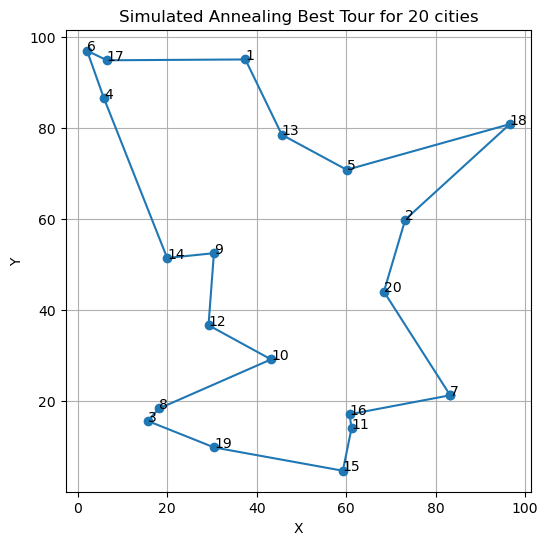

In [18]:
# Plot best tour found
def plot_tour(coords, tour, title="TSP Tour"):
    tour_c = tour + [tour[0]]  # close the loop
    xs = coords[tour_c, 0]
    ys = coords[tour_c, 1]

    plt.figure(figsize=(6, 6))
    plt.plot(xs, ys, marker='o')
    for i, txt in enumerate(tour):
        plt.annotate(f"{txt+1}", (coords[tour[i]][0], coords[tour[i]][1]))
    plt.title(title)
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.grid(True)
    plt.show()
plot_tour(cities_coords, sa_best_tour, title="Simulated Annealing Best Tour for 20 cities")

## Scalibility Testing

For the simulated annealing we have created the algorithm to measure the optimum path. Now we will do scalibility testing and put them in a csv file for further analysis

## Scalibility Testing for Simulated Annealing and Tabu Search

In [19]:
# This function will run simulated annealing based on the number of cities. We will change the number of cities 10,20,30,40,50
# After that we will keep the results in a csv file for future analysis 
# From the csv we will get the view how it is improving distance slowly
def run_sa_with_brief_log (num_cities,
                initial_temp=10000,
                cooling_rate=0.995,
                min_temp=0.1,
                max_iterations=10000):
    """
    Running Simulated Annealing once for a given problem size.
    Also saving per-iteration tour and distance in a CSV file.
    """
    cities = cities_based_on_numbers(num_cities)

    # reproducibility
    random.seed(42)
    np.random.seed(42)

    # Calling simulated annealing class
    sa = SimulatedAnnealing(
        cities=cities,
        initial_temp=initial_temp,
        cooling_rate=cooling_rate,
        min_temp=min_temp
    )

    start_time = time.time()
    best_tour, best_distance = sa.solve(max_iterations=max_iterations)
    elapsed = time.time() - start_time

    # Each row: iteration, current_distance, best_distance, route as string
    hist_rows = []
    for h in sa.history:
        tour = h['tour']
        tour_cities = " -> ".join([f"City_{i+1}" for i in tour])
        hist_rows.append({
            "iteration": h["iteration"],
            "temperature": h["temperature"],
            "current_distance": h["current_distance"],
            "best_distance": h["best_distance"],
            "route": tour_cities
        })

    hist_df = pd.DataFrame(hist_rows)

    # Save to CSV, e.g. sa_history_20cities.csv
    hist_filename = f"../results/sa_history_{num_cities}cities.csv"
    hist_df.to_csv(hist_filename, index=False)
    print(f"Per-iteration SA history saved to {hist_filename}")

    # brief result for scalability summary 
    result = {
        "n_cities": num_cities,
        "best_distance": best_distance,
        "time_sec": elapsed,
        "iterations_logged": len(sa.history) * 5  # since you log every 5 iters
    }
    return result



In [20]:
# For each run this function will let us find the time and space complexity
def run_sa_path_finding(num_cities,
                initial_temp=10000,
                cooling_rate=0.995,
                min_temp=0.1,
                max_iterations=10000):
    """
    Run Simulated Annealing once for a given problem size.
    Returns brief metrics for scalability analysis.
    """
    cities = cities_based_on_numbers(num_cities)

    # reproducibility
    random.seed(42)
    np.random.seed(42)

    sa = SimulatedAnnealing(
        cities=cities,
        initial_temp=initial_temp,
        cooling_rate=cooling_rate,
        min_temp=min_temp
    )

    start_time = time.time()
    best_tour, best_distance = sa.solve(max_iterations=max_iterations)
    elapsed = time.time() - start_time

    # brief result: only what we need
    return {
        "n_cities": num_cities,
        "best_distance": best_distance,
        "time_sec": elapsed,
        # if you log every 100 iterations, each history row = 100 iters
        "iterations_effective": len(sa.history) * 100
    }


In [21]:
# In here we will measure with different city size and collect the time complexity
city_sizes = [5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
sa_results = []

print("Simulated Annealing – scalability test")

for n in city_sizes:
    # run_sa_once now also saves sa_history_{n}cities.csv internally
    res = run_sa_path_finding(num_cities=n)
    sa_results.append(res)
    print(f"{n:2d} cities -> "
          f"best_distance={res['best_distance']:.3f}, "
          f"time={res['time_sec']:.4f}s, "
          f"iters≈{res['iterations_effective']}")

# Build DataFrame with brief metrics
sa_scal_df = pd.DataFrame(sa_results)

print("\nSA scalability summary")
print(sa_scal_df[["n_cities", "best_distance", "time_sec",
                  "iterations_effective"]].to_string(index=False))

# Save overall scalability table for plots / report
sa_scal_df.to_csv("../results/sa_history_10-50_cities.csv", index=False)
print("\nSaved overall scalability results to sa_scalability_10_50.csv")


Simulated Annealing – scalability test
 5 cities -> best_distance=227.346, time=0.0371s, iters≈2300
10 cities -> best_distance=290.307, time=0.0551s, iters≈2300
15 cities -> best_distance=320.526, time=0.0644s, iters≈2300
20 cities -> best_distance=386.627, time=0.0823s, iters≈2300
25 cities -> best_distance=463.845, time=0.0973s, iters≈2300
30 cities -> best_distance=523.782, time=0.1181s, iters≈2300
35 cities -> best_distance=558.850, time=0.1332s, iters≈2300
40 cities -> best_distance=582.591, time=0.1531s, iters≈2300
45 cities -> best_distance=687.274, time=0.1698s, iters≈2300
50 cities -> best_distance=755.074, time=0.1897s, iters≈2300

SA scalability summary
 n_cities  best_distance  time_sec  iterations_effective
        5     227.345519  0.037095                  2300
       10     290.306774  0.055108                  2300
       15     320.525666  0.064411                  2300
       20     386.626677  0.082255                  2300
       25     463.844632  0.097306        

In [22]:
city_sizes = [10, 20, 30, 40, 50]
all_results = []

for n in city_sizes:
    res = run_sa_with_brief_log(n)   # Finding history of path finding
    all_results.append(res)


Per-iteration SA history saved to ../results/sa_history_10cities.csv
Per-iteration SA history saved to ../results/sa_history_20cities.csv
Per-iteration SA history saved to ../results/sa_history_30cities.csv
Per-iteration SA history saved to ../results/sa_history_40cities.csv
Per-iteration SA history saved to ../results/sa_history_50cities.csv


## Tabu search scalibility testing

In [56]:
# This function will run tabu search based on the number of cities. We will change the number of cities 10,20,30,40,50
# After that we will keep the results in a csv file for future analysis 
# From the csv we will get the view how it is improving distance slowly
def run_ts_with_brief_log(num_cities,
                          tabu_size=10,
                          max_iterations=2000, neighborhood_sample_size=200,stall_limit=80):
    """
    Running Tabu Search once for a given problem size.
    Also saving per-iteration tour and distance in a CSV file.
    """
    cities = cities_based_on_numbers(num_cities)

    # reproducibility
    random.seed(42)
    np.random.seed(42)

    # Calling tabu search class
    ts = TabuSearch(
        cities=cities,
        tabu_size=tabu_size,
        max_iterations=max_iterations,
        neighborhood_sample_size = neighborhood_sample_size, 
        stall_limit = stall_limit
    )

    start_time = time.time()
    best_tour, best_distance = ts.solve()
    elapsed = time.time() - start_time

    # Each row: iteration, temperature, current_distance, best_distance, route as string
    hist_rows = []
    for h in ts.history:
        tour = h['tour']
        tour_cities = " -> ".join([f"City_{i+1}" for i in tour])
        hist_rows.append({
            "iteration": h["iteration"],
            "current_distance": h["current_distance"],
            "best_distance": h["best_distance"],
            "route": tour_cities
        })

    hist_df = pd.DataFrame(hist_rows)

    # Save to CSV, ts_history_20cities.csv
    hist_filename = f"../results/ts_history_{num_cities}cities.csv"
    hist_df.to_csv(hist_filename, index=False)
    print(f"Per-iteration TS history saved to {hist_filename}")

    # brief result for scalability summary
    result = {
        "n_cities": num_cities,
        "best_distance": best_distance,
        "time_sec": elapsed,
        "iterations_logged": len(ts.history) * 5  # since you log every 5 iters
    }
    return result

In [57]:
def run_ts_path_finding(num_cities,
                        tabu_size=10,
                        max_iterations=2000, neighborhood_sample_size=200,stall_limit=80):
    """
    Run Tabu Search once for a given problem size.
    Returns brief metrics for scalability analysis and complexity calculation.
    """
    cities = cities_based_on_numbers(num_cities)

    # reproducibility
    random.seed(42)
    np.random.seed(42)

    ts = TabuSearch(
        cities=cities,
        tabu_size=tabu_size,
        max_iterations=max_iterations,
        neighborhood_sample_size = neighborhood_sample_size, 
        stall_limit = stall_limit
    )

    start_time = time.time()
    best_tour, best_distance = ts.solve()
    elapsed = time.time() - start_time

    # brief result: only what we need
    return {
        "n_cities": num_cities,
        "best_distance": best_distance,
        "time_sec": elapsed,
        # iterations logged (tabu doesn't multiply like SA's logging interval)
        "iterations_effective": len(ts.history)
    }


In [25]:
"""
Here we will evaluate how Tabu search scales as the number of cities increases in this problem. For each predefined city size the algorithm is 
executed with a fixed iteration limit of 2000
"""
# In here we will measure with different city size and collect the time complexity
city_sizes = [5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
ts_results = []

print("Tabu Search – scalability test")

for n in city_sizes:
    # run_ts_path_finding now measures time and distance for scalability analysis
    res = run_ts_path_finding(num_cities=n, max_iterations=2000)
    ts_results.append(res)
    print(f"{n:2d} cities -> "
          f"best_distance={res['best_distance']:.3f}, "
          f"time={res['time_sec']:.4f}s, "
          f"iters≈{res['iterations_effective']}")

# Build DataFrame with brief metrics
ts_scal_df = pd.DataFrame(ts_results)

print("\nTS scalability summary")
print(ts_scal_df[["n_cities", "best_distance", "time_sec",
                  "iterations_effective"]].to_string(index=False))

# Save overall scalability table for plots / report
ts_scal_df.to_csv("../results/ts_history_5-50_cities.csv", index=False)
print("\nSaved overall scalability results to ts_scalability_5_50.csv")


Tabu Search – scalability test
 5 cities -> best_distance=227.346, time=0.0196s, iters≈8
10 cities -> best_distance=290.307, time=0.0738s, iters≈8
15 cities -> best_distance=320.526, time=0.3077s, iters≈12
20 cities -> best_distance=386.430, time=1.3776s, iters≈23
25 cities -> best_distance=496.080, time=0.7696s, iters≈9
30 cities -> best_distance=453.902, time=1.9923s, iters≈21
35 cities -> best_distance=555.021, time=2.8037s, iters≈25
40 cities -> best_distance=569.324, time=4.8180s, iters≈38
45 cities -> best_distance=687.306, time=6.1183s, iters≈43
50 cities -> best_distance=638.062, time=5.4747s, iters≈35

TS scalability summary
 n_cities  best_distance  time_sec  iterations_effective
        5     227.345519  0.019647                     8
       10     290.306774  0.073789                     8
       15     320.525666  0.307740                    12
       20     386.429689  1.377578                    23
       25     496.079576  0.769593                     9
       30     45

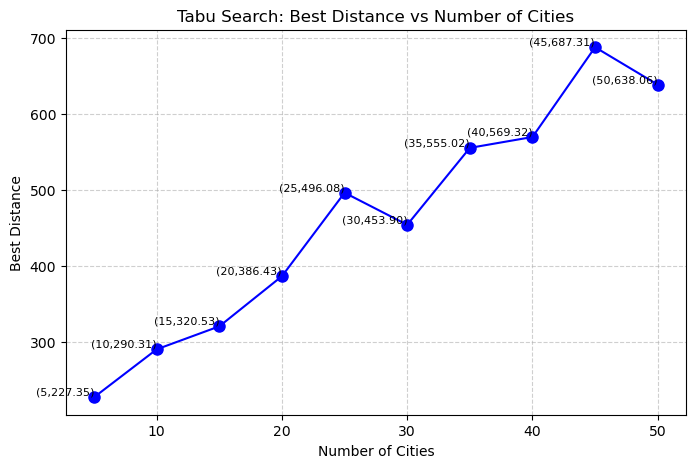

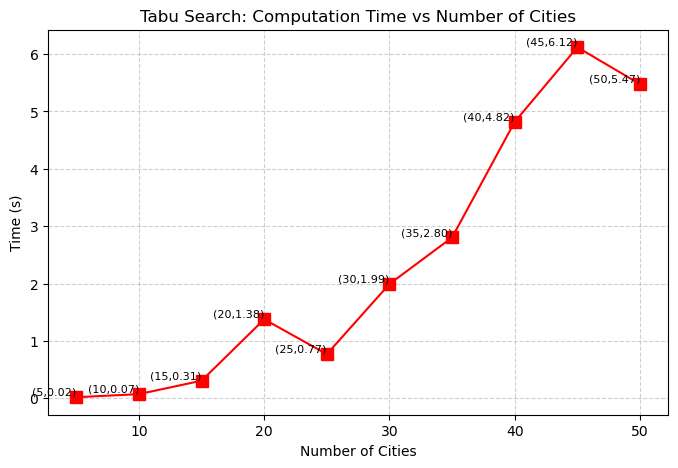

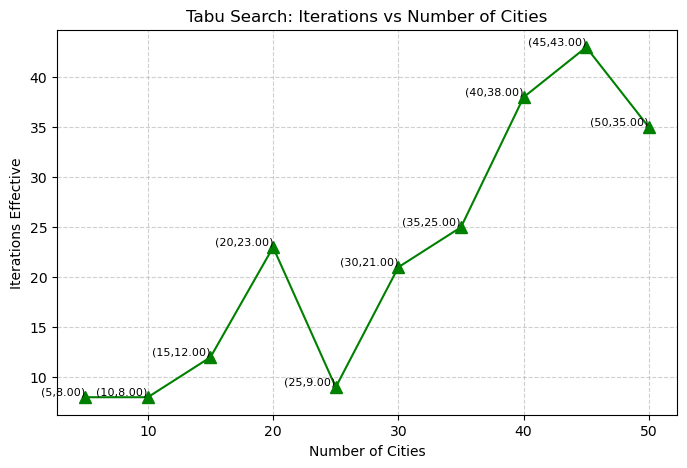

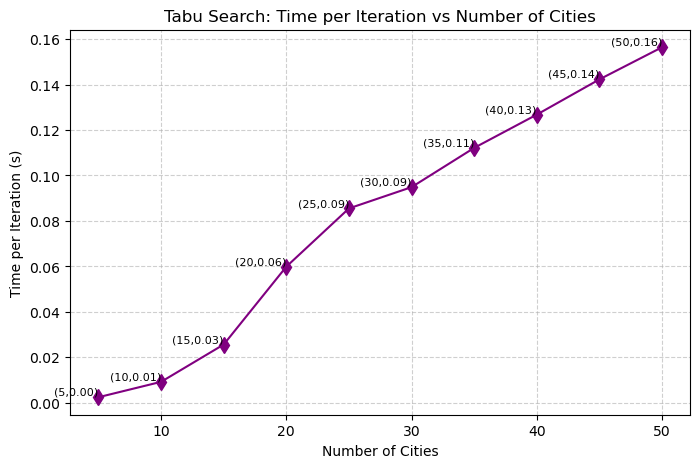

In [10]:
# Load CSV
df = pd.read_csv("../results/ts_history_5-50_cities.csv")

# Function to add coordinates on points
def annotate_points(x, y):
    for i, j in zip(x, y):
        plt.text(i, j, f'({i},{j:.2f})', fontsize=8, ha='right', va='bottom')

# Plot 1: Best Distance vs Number of Cities
plt.figure(figsize=(8,5))
plt.plot(df['n_cities'], df['best_distance'], marker='o', color='blue', linestyle='-', markersize=8)
annotate_points(df['n_cities'], df['best_distance'])
plt.title('Tabu Search: Best Distance vs Number of Cities')
plt.xlabel('Number of Cities')
plt.ylabel('Best Distance')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Plot 2: Computation Time vs Number of Cities
plt.figure(figsize=(8,5))
plt.plot(df['n_cities'], df['time_sec'], marker='s', color='red', linestyle='-', markersize=8)
annotate_points(df['n_cities'], df['time_sec'])
plt.title('Tabu Search: Computation Time vs Number of Cities')
plt.xlabel('Number of Cities')
plt.ylabel('Time (s)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Plot 3: Iterations Effective vs Number of Cities
plt.figure(figsize=(8,5))
plt.plot(df['n_cities'], df['iterations_effective'], marker='^', color='green', linestyle='-', markersize=8)
annotate_points(df['n_cities'], df['iterations_effective'])
plt.title('Tabu Search: Iterations vs Number of Cities')
plt.xlabel('Number of Cities')
plt.ylabel('Iterations Effective')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Time per Iteration
df['time_per_iteration'] = df['time_sec'] / df['iterations_effective']
plt.figure(figsize=(8,5))
plt.plot(df['n_cities'], df['time_per_iteration'], marker='d', color='purple', linestyle='-', markersize=8)
annotate_points(df['n_cities'], df['time_per_iteration'])
plt.title('Tabu Search: Time per Iteration vs Number of Cities')
plt.xlabel('Number of Cities')
plt.ylabel('Time per Iteration (s)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

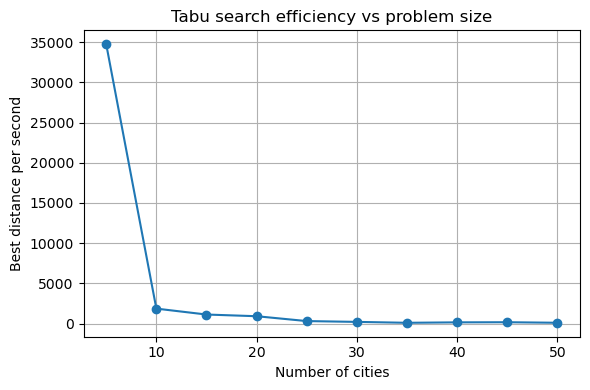

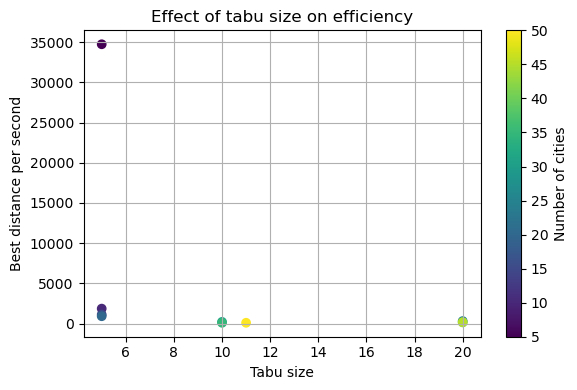

In [12]:
# Load CSV
df = pd.read_csv("../results/tabu_best_results_best_hyperparameters.csv")  # use your filename

# Efficiency metric: lower is better distance, but we also want speed
# Here: distance per second (smaller = better solution faster)
df["distance_per_second"] = df["best_distance"] / df["execution_time"]

#Efficiency vs number of cities
plt.figure(figsize=(6,4))
plt.plot(df["num_cities"], df["distance_per_second"], marker="o")
plt.xlabel("Number of cities")
plt.ylabel("Best distance per second")
plt.title("Tabu search efficiency vs problem size")
plt.grid(True)
plt.tight_layout()
plt.show()

# 2) Efficiency vs tabu size (colour-coded by problem size)
plt.figure(figsize=(6,4))
sc = plt.scatter(df["tabu_size"], df["distance_per_second"],
                 c=df["num_cities"], cmap="viridis")
plt.xlabel("Tabu size")
plt.ylabel("Best distance per second")
plt.title("Effect of tabu size on efficiency")
plt.colorbar(sc, label="Number of cities")
plt.grid(True)
plt.tight_layout()
plt.show()

In [26]:
city_sizes = [10, 20, 30, 40, 50]
all_results = []

for n in city_sizes:
    res = run_ts_with_brief_log(n)   # Finding history of path finding
    all_results.append(res)


Per-iteration TS history saved to ../results/ts_history_10cities.csv
Per-iteration TS history saved to ../results/ts_history_20cities.csv
Per-iteration TS history saved to ../results/ts_history_30cities.csv
Per-iteration TS history saved to ../results/ts_history_40cities.csv
Per-iteration TS history saved to ../results/ts_history_50cities.csv


## Side by side graph for simulated annealing and tabu search

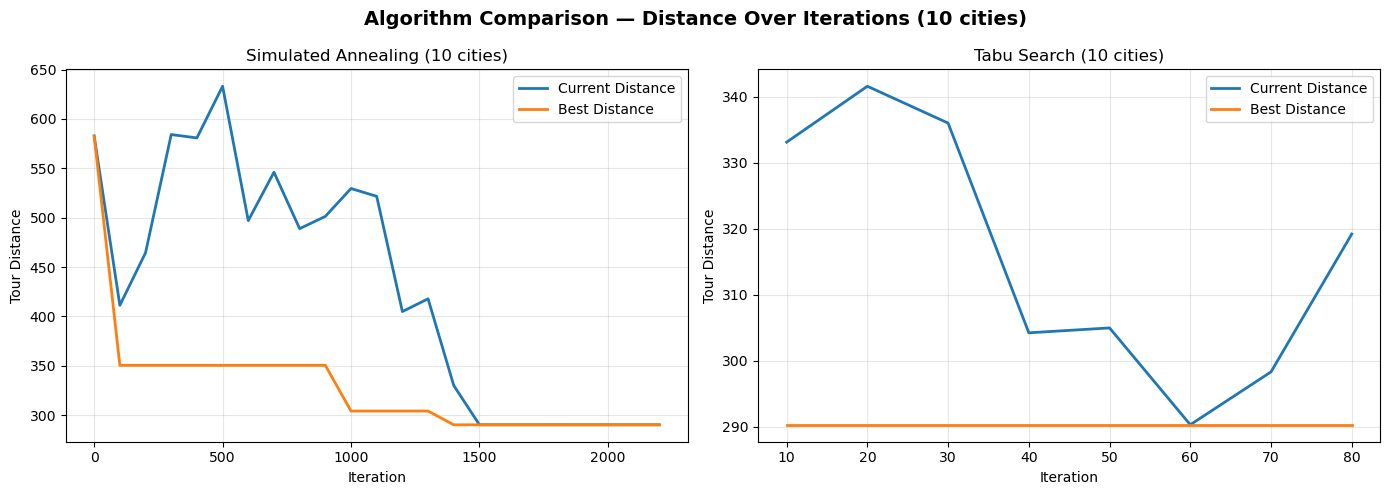

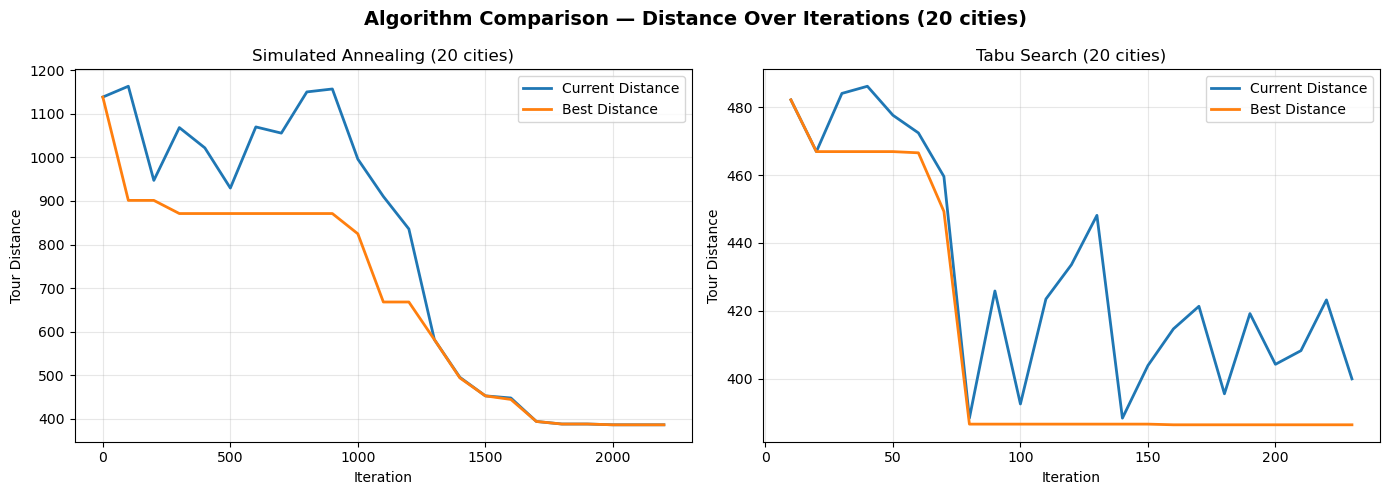

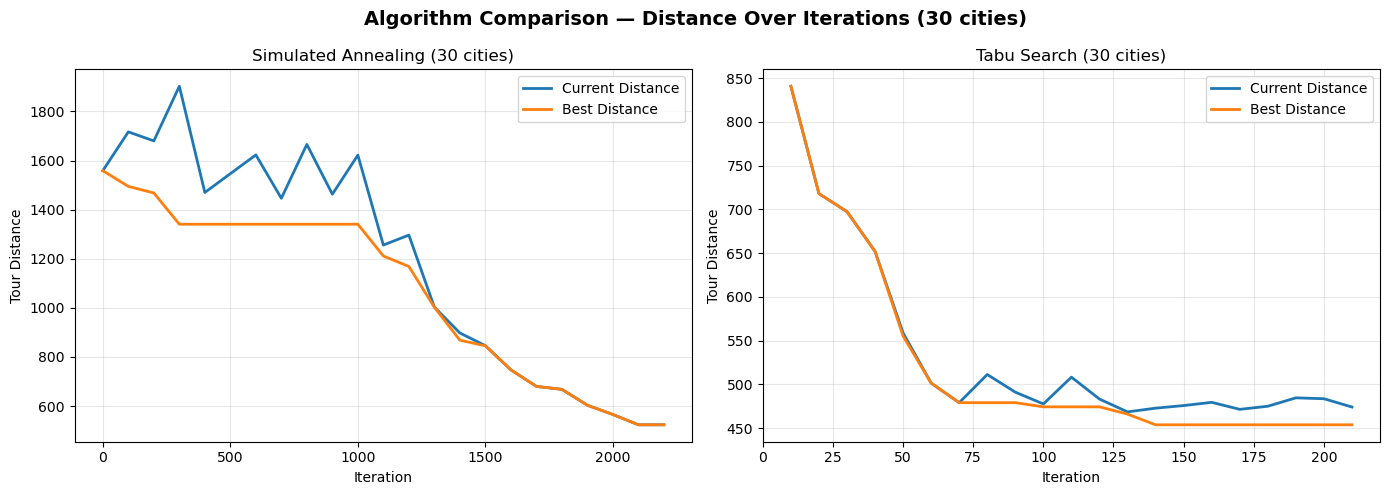

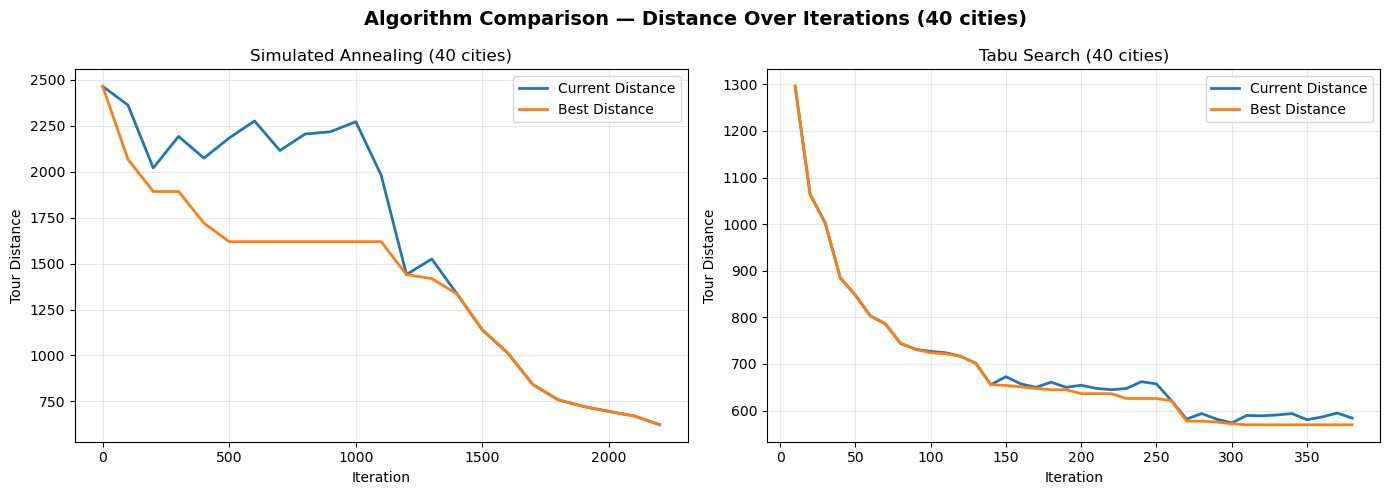

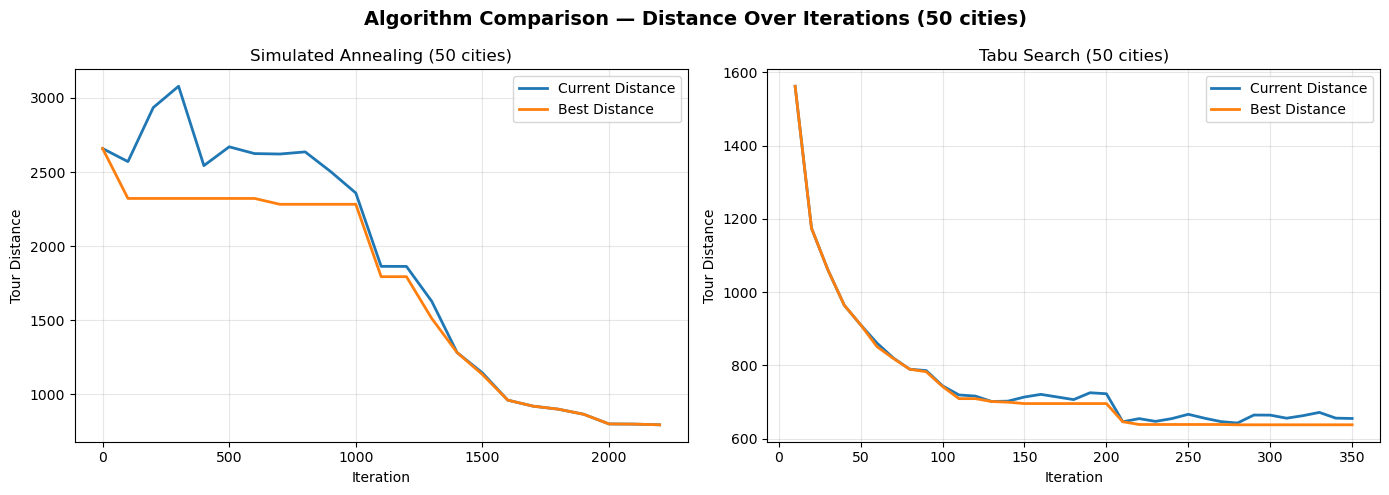

In [27]:
# Generative ai help was taken for plotting this graph
city_sizes = [10, 20, 30, 40, 50]

for n in city_sizes:
    # Load both CSVs
    sa_df = pd.read_csv(f"../results/sa_history_{n}cities.csv")
    ts_df = pd.read_csv(f"../results/ts_history_{n}cities.csv")
    
    # Create figure with 2 subplots side by side
    fig, (ax1_sa, ax1_ts) = plt.subplots(1, 2, figsize=(14, 5))

    # Simulated Annealing
    ax1_sa.plot(sa_df["iteration"], sa_df["current_distance"],label="Current Distance", color="tab:blue", linewidth=2)
    ax1_sa.plot(sa_df["iteration"], sa_df["best_distance"],label="Best Distance", color="tab:orange", linewidth=2)
    ax1_sa.set_xlabel("Iteration")
    ax1_sa.set_ylabel("Tour Distance")
    ax1_sa.grid(True, alpha=0.3)
    ax1_sa.legend(loc="upper right")
    ax1_sa.set_title(f"Simulated Annealing ({n} cities)")

    # Tabu Search 
    ax1_ts.plot(ts_df["iteration"], ts_df["current_distance"],label="Current Distance", color="tab:blue", linewidth=2)
    ax1_ts.plot(ts_df["iteration"], ts_df["best_distance"],label="Best Distance", color="tab:orange", linewidth=2)
    ax1_ts.set_xlabel("Iteration")
    ax1_ts.set_ylabel("Tour Distance")
    ax1_ts.grid(True, alpha=0.3)
    ax1_ts.legend(loc="upper right")
    ax1_ts.set_title(f"Tabu Search ({n} cities)")

    plt.suptitle(f"Algorithm Comparison — Distance Over Iterations ({n} cities)", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()



### Comparison: Tabu Search vs Simulated Annealing

| **Metric**                | **Simulated Annealing (SA)**                                | **Tabu Search (TS)**                                  |
|---------------------------|-------------------------------------------------------------|-------------------------------------------------------|
| **Convergence Speed**     | Gradual improvement; best distance improves slowly over iterations | Very fast convergence; best distance stabilizes within first ~50 iterations |
| **Stability of Current Distance** | Highly fluctuating; large oscillations in current distance | Very stable after initial iterations; small oscillations |
| **Best Distance Quality** | Improves over time but requires many iterations to reach near-optimal | Achieves near-optimal solution almost immediately |
| **Performance on Larger Problems (50 cities)** | Slower convergence; requires >1500 iterations for good solution | Consistent performance; near-optimal within ~50 iterations |
| **Exploration vs Exploitation** | Strong exploration early, but slower exploitation later | Aggressive exploitation with memory-based diversification |


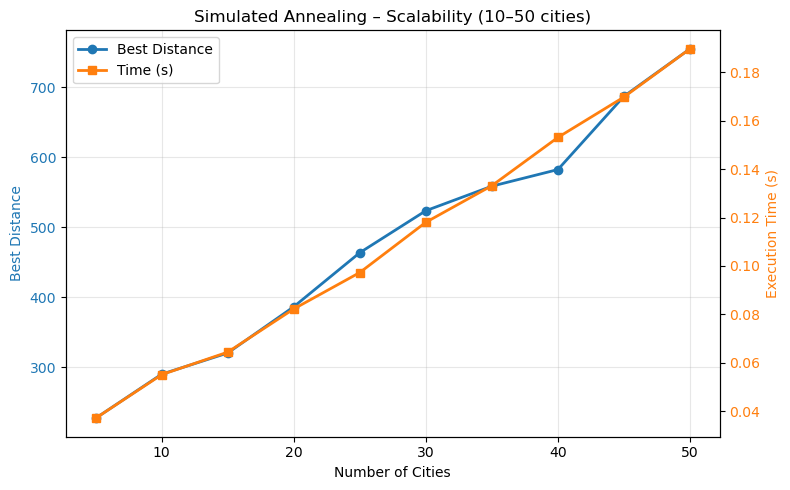

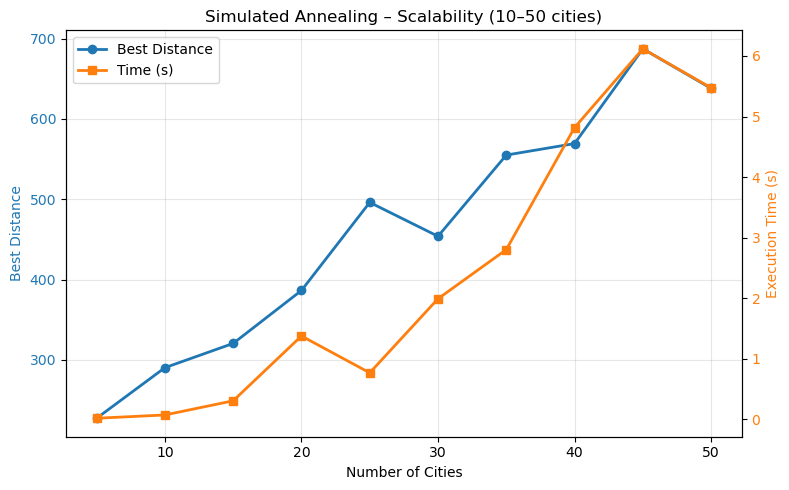

In [28]:
"""
Here we visualize how both simulated annealing and tabu search scales as the number of city increases. Both metrics are plotted 
against the number of cities so the curves can be compared within the same plot
"""

df = pd.read_csv("../results/sa_history_10-50_cities.csv")
# Creating a figure with a primary axis
fig, ax1 = plt.subplots(figsize=(8, 5))

# Plotting best distance vs number of cities
ax1.plot(df["n_cities"], df["best_distance"], marker="o",color="tab:blue", label="Best Distance", linewidth=2)
ax1.set_xlabel("Number of Cities")
ax1.set_ylabel("Best Distance", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.grid(True, alpha=0.3)

# Creating secondary Y-axis for execution time
ax2 = ax1.twinx()
ax2.plot(df["n_cities"], df["time_sec"], marker="s",color="tab:orange", label="Time (s)", linewidth=2)
ax2.set_ylabel("Execution Time (s)", color="tab:orange")
ax2.tick_params(axis="y", labelcolor="tab:orange")

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.title("Simulated Annealing – Scalability (10–50 cities)")
plt.tight_layout()
plt.show()


## Tabu search scalibility 
df = pd.read_csv("../results/ts_history_5-50_cities.csv")
# Creating figure and primary axis
fig, ax1 = plt.subplots(figsize=(8, 5))

# Plotting best distance vs number of cities
ax1.plot(df["n_cities"], df["best_distance"], marker="o",color="tab:blue", label="Best Distance", linewidth=2)
ax1.set_xlabel("Number of Cities")
ax1.set_ylabel("Best Distance", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.grid(True, alpha=0.3)

# Secondary axis for execution time
ax2 = ax1.twinx()
ax2.plot(df["n_cities"], df["time_sec"], marker="s",color="tab:orange", label="Time (s)", linewidth=2)
ax2.set_ylabel("Execution Time (s)", color="tab:orange")
ax2.tick_params(axis="y", labelcolor="tab:orange")

# Merging legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.title("Simulated Annealing – Scalability (10–50 cities)")
plt.tight_layout()
plt.show()

## Side by Side Comparison between SA and Tabu for distance and time covered 

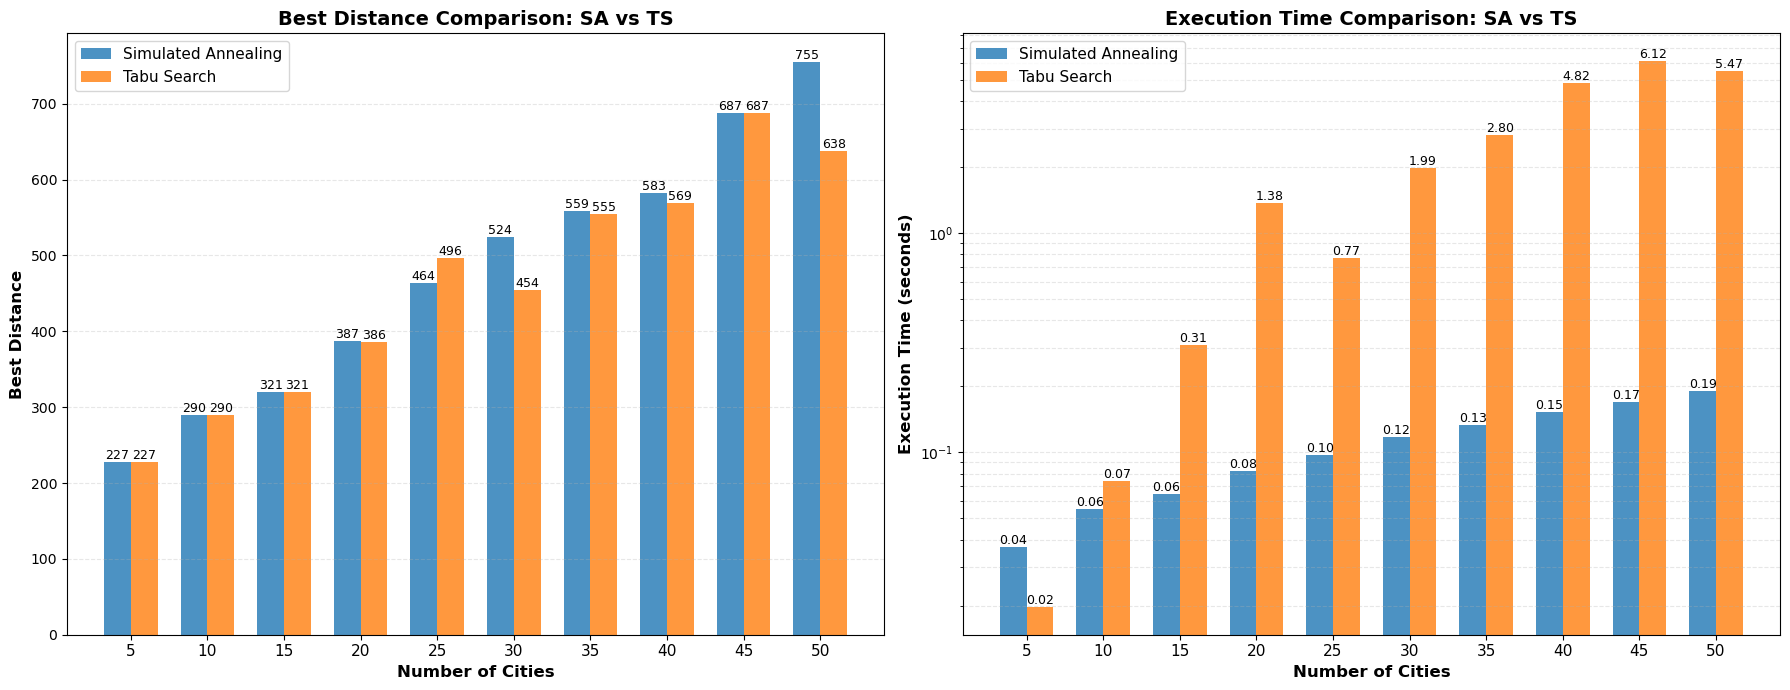

SIMULATED ANNEALING vs TABU SEARCH - PERFORMANCE COMPARISON
Cities     SA Distance        TS Distance        SA Time (s)     TS Time (s)    
5          227.35             227.35             0.0371          0.0196         
10         290.31             290.31             0.0551          0.0738         
15         320.53             320.53             0.0644          0.3077         
20         386.63             386.43             0.0823          1.3776         
25         463.84             496.08             0.0973          0.7696         
30         523.78             453.90             0.1181          1.9923         
35         558.85             555.02             0.1332          2.8037         
40         582.59             569.32             0.1531          4.8180         
45         687.27             687.31             0.1698          6.1183         
50         755.07             638.06             0.1897          5.4747         


In [29]:
# Generative ai help was taken in this part for generating side by side graph
# Load data from CSV files
sa_df = pd.read_csv('../results/sa_history_10-50_cities.csv') # Even though it is 10-50 cities but it was logged 5-50 cities
ts_df = pd.read_csv('../results/ts_history_5-50_cities.csv')

# Create figure with two subplots with more space
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Set bar width and positions
x = np.arange(len(sa_df['n_cities']))
width = 0.35

#Chart 1: Best Distance Comparison 
bars1 = ax1.bar(x - width/2, sa_df['best_distance'], width, label='Simulated Annealing', color='#1f77b4', alpha=0.8)
bars2 = ax1.bar(x + width/2, ts_df['best_distance'], width, label='Tabu Search', color='#ff7f0e', alpha=0.8)

ax1.set_xlabel('Number of Cities', fontsize=12, fontweight='bold')
ax1.set_ylabel('Best Distance', fontsize=12, fontweight='bold')
ax1.set_title('Best Distance Comparison: SA vs TS', fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(sa_df['n_cities'], fontsize=11)
ax1.legend(fontsize=11, loc='upper left')
ax1.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on bars with better positioning
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.0f}',
                ha='center', va='bottom', fontsize=9)

#  Execution Time Comparison 
bars3 = ax2.bar(x - width/2, sa_df['time_sec'], width, label='Simulated Annealing', color='#1f77b4', alpha=0.8)
bars4 = ax2.bar(x + width/2, ts_df['time_sec'], width, label='Tabu Search', color='#ff7f0e', alpha=0.8)

ax2.set_xlabel('Number of Cities', fontsize=12, fontweight='bold')
ax2.set_ylabel('Execution Time (seconds)', fontsize=12, fontweight='bold')
ax2.set_title('Execution Time Comparison: SA vs TS', fontsize=14, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(sa_df['n_cities'], fontsize=11)
ax2.set_yscale('log')  # Log scale for better visualization
ax2.legend(fontsize=11, loc='upper left')
ax2.grid(axis='y', alpha=0.3, linestyle='--', which='both')

# Add value labels on bars
for bars in [bars3, bars4]:
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('sa_vs_ts_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Print comparison table
print("SIMULATED ANNEALING vs TABU SEARCH - PERFORMANCE COMPARISON")
print(f"{'Cities':<10} {'SA Distance':<18} {'TS Distance':<18} {'SA Time (s)':<15} {'TS Time (s)':<15}")
for i in range(len(sa_df)):
    print(f"{sa_df['n_cities'].iloc[i]:<10} {sa_df['best_distance'].iloc[i]:<18.2f} {ts_df['best_distance'].iloc[i]:<18.2f} {sa_df['time_sec'].iloc[i]:<15.4f} {ts_df['time_sec'].iloc[i]:<15.4f}")



## Winner in Single Search

From the analysis we can say a thing. Tabu search finds the optimum solution faster than simulated annealing. And the result is significant. Comparing time complexity and covering distance we can say even though at some point sa showed better but from our analysis we can say as tabu reaches optimum faster where simulated annealing takes time in this place also sometimes accepts bad solution. But simulated annealing outperforms in time complexity. As our goal is to achieve minimum distance so Tabu search will be the winner in single search

## Hyper parameter tuning

Hyper parameter in a function are the parameters which help the function to determine a result as a helper variable. In here we will tune by changing the parameters tabu sizes, max iteration. Also we will perform grid search and random search. In the grid search we will use the method of systematic approach in a frequency on the other hand random search will happen by taking values randomly. 

### Grid Search

The grid search combination coding help was taken using generative ai. Here we will perform grid search and for different number of cities we will get different hyper parameters. We will save this combination inside a csv file

For preventing randomness we will use a seed for preventing grid search and random search generating result in different random ness. Here we will use the seed 42

In [30]:
seed = 42

In [31]:
def grid_search_tabu(
    tabu_sizes,
    max_iterations_list,
    neighborhood_sizes,
    stall_limits,
    num_cities_list,        # List of different city counts (10,20,30,...)
    csv_filename="tabu_tuning_results.csv"
):
    """
    Performing grid search over Tabu Search hyperparameters for different city sizes.

    Parameters:
    tabu_sizes: list of tabu list lengths
    max_iterations_list: list of iteration budgets
    neighborhood_sizes: number of 2-opt samples to evaluate per iteration
    stall_limits: stopping rules for consecutive no-improvement iterations
    num_cities_list: list of city counts
    csv_filename: output file to store best hyperparameters

    The function writes a CSV containing:
    num_cities, tabu_size, max_iterations, neighborhood_size, stall_limit, best_distance
    """
    # Creating CSV with headers
    with open(csv_filename, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow([
            "num_cities",
            "tabu_size",
            "max_iterations",
            "neighborhood_size",
            "stall_limit",
            "best_distance"
        ])

        # Loop over different city counts
        for num_cities in num_cities_list:
            print(f"\nRunning Grid Search for {num_cities} Cities ")

            # Load cities for this run
            cities = cities_based_on_numbers(num_cities)

            best_distance_overall = float("inf")
            best_params_overall = None

            # Generate all combos over all combinations
            for tabu_size, max_iter, neigh_size, stall_limit in product(tabu_sizes,max_iterations_list,neighborhood_sizes,stall_limits):
                params = {
                    "tabu_size": tabu_size,
                    "max_iterations": max_iter,
                    "neighborhood_sample_size": neigh_size,
                    "stall_limit": stall_limit,
                    "aspiration": True,
                    "diversify_after": None
                }

                random.seed(seed)
                np.random.seed(seed)
                # Run Tabu Search
                ts = TabuSearch(
                    cities=cities,
                    tabu_size=params["tabu_size"],
                    max_iterations=params["max_iterations"],
                    neighborhood_sample_size=params["neighborhood_sample_size"],
                    stall_limit=params["stall_limit"],
                    aspiration=True,
                    diversify_after=None
                )

                best_tour, best_distance = ts.solve()

                # Tracking best for this num_cities
                if best_distance < best_distance_overall:
                    best_distance_overall = best_distance
                    best_params_overall = {
                        "tabu_size": tabu_size,
                        "max_iterations": max_iter,
                        "neighborhood_size": neigh_size,
                        "stall_limit": stall_limit
                    }

            print(f" Best for {num_cities} cities → {best_params_overall} | Dist = {best_distance_overall:.3f}")

            # Saving only ONE best row for this num_cities
            writer.writerow([
                num_cities,
                best_params_overall["tabu_size"],
                best_params_overall["max_iterations"],
                best_params_overall["neighborhood_size"],
                best_params_overall["stall_limit"],
                best_distance_overall
            ])
            f.flush()
            
    print("\nGrid Search Complete — results saved in:", csv_filename)

Implementation

In [32]:
tabu_sizes = [5, 10, 20]
max_iterations_list = [300, 500]
neighborhood_sizes = [100, 200, None]
stall_limits = [50, 80]
num_cities_list = [5,10,15,20,25,30,35,40,45,50]


In [33]:
grid_search_tabu(
    tabu_sizes,
    max_iterations_list,
    neighborhood_sizes,
    stall_limits,
    num_cities_list,
    csv_filename="../results/tabu__tuning_results_grid_search.csv"
)



Running Grid Search for 5 Cities 
 Best for 5 cities → {'tabu_size': 5, 'max_iterations': 300, 'neighborhood_size': 100, 'stall_limit': 50} | Dist = 227.346

Running Grid Search for 10 Cities 
 Best for 10 cities → {'tabu_size': 5, 'max_iterations': 300, 'neighborhood_size': 100, 'stall_limit': 80} | Dist = 290.307

Running Grid Search for 15 Cities 
 Best for 15 cities → {'tabu_size': 5, 'max_iterations': 300, 'neighborhood_size': 100, 'stall_limit': 50} | Dist = 320.526

Running Grid Search for 20 Cities 
 Best for 20 cities → {'tabu_size': 5, 'max_iterations': 300, 'neighborhood_size': 100, 'stall_limit': 50} | Dist = 386.430

Running Grid Search for 25 Cities 
 Best for 25 cities → {'tabu_size': 20, 'max_iterations': 300, 'neighborhood_size': None, 'stall_limit': 50} | Dist = 478.346

Running Grid Search for 30 Cities 
 Best for 30 cities → {'tabu_size': 10, 'max_iterations': 300, 'neighborhood_size': 200, 'stall_limit': 50} | Dist = 453.902

Running Grid Search for 35 Cities 
 Be

### Random Search

In [34]:
"""
This section is random search based tuning of tabu search. Here we are tuning parameters based on random search. This runs in a loop under cities also.
The number of cities increases based in the 
"""

def random_search_tabu(
    tabu_sizes,
    max_iterations_list,
    neighborhood_sizes,
    stall_limits,
    num_cities_list,        # List of different city counts
    n_trials=20,            # Number of random trials per city count
    csv_filename="tabu_random_tuning_results.csv"
):
    # Create CSV with headers
    with open(csv_filename, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow([
            "num_cities",
            "tabu_size",
            "max_iterations",
            "neighborhood_size",
            "stall_limit",
            "best_distance"
        ])

        # Loop over different city counts
        for num_cities in num_cities_list:
            print(f"\nRunning Random Search for {num_cities} Cities ")

            # Load cities for this run
            cities = cities_based_on_numbers(num_cities)

            best_distance_overall = float("inf")
            best_params_overall = None

            # Considering neighborhood size
            
            for trial in range(1, n_trials + 1):
                # Filter out None values
                valid_neigh_sizes = [n for n in neighborhood_sizes if n is not None]
                
                # Then pick random integer in range
                neigh_size = random.randint(min(valid_neigh_sizes), max(valid_neigh_sizes))
                # Pick from min, max, or None
                choices = [min(valid_neigh_sizes), max(valid_neigh_sizes), None]

                # Randomly sample one combination
                tabu_size = random.randint(min(tabu_sizes), max(tabu_sizes))
                max_iter = random.randint(min(max_iterations_list) , max(max_iterations_list))
                neigh_size = random.choice(choices)
                stall_limit = random.randint(min(stall_limits), max(stall_limits))

                params = {
                    "tabu_size": tabu_size,
                    "max_iterations": max_iter,
                    "neighborhood_sample_size": neigh_size,
                    "stall_limit": stall_limit,
                    "aspiration": True,
                    "diversify_after": None
                }
                # Putting seed for random
                random.seed(seed)
                np.random.seed(seed)
                # Initialize and run Tabu Search with sampled parameters
                ts = TabuSearch(
                    cities=cities,
                    tabu_size=tabu_size,
                    max_iterations=max_iter,
                    neighborhood_sample_size=neigh_size,
                    stall_limit=stall_limit,
                    aspiration=True,
                    diversify_after=None
                )

                best_tour, best_distance = ts.solve()

                # Track best for this num_cities
                if best_distance < best_distance_overall:
                    best_distance_overall = best_distance
                    best_params_overall = {
                        "tabu_size": tabu_size,
                        "max_iterations": max_iter,
                        "neighborhood_size": neigh_size,
                        "stall_limit": stall_limit
                    }

                #print(f"Trial {trial}/{n_trials}: Distance={best_distance:.3f} | Params={params}")

            # Save best result for this number of cities
            writer.writerow([
                num_cities,
                best_params_overall["tabu_size"],
                best_params_overall["max_iterations"],
                best_params_overall["neighborhood_size"],
                best_params_overall["stall_limit"],
                best_distance_overall
            ])
            f.flush()
            print(f"Best for {num_cities} cities → {best_params_overall} | Dist = {best_distance_overall:.3f}")

    print("\nRandom Search Complete — results saved in:", csv_filename)


In [35]:
random_search_tabu(
    tabu_sizes=[5,10,20],
    max_iterations_list=[300,500],
    neighborhood_sizes=[100,200,None],
    stall_limits=[50,80],
    num_cities_list=[5,10,15,20,25,30,35,40,45,50],
    n_trials=20,
    csv_filename="../results/tabu_tuning_results_random_search.csv"
)



Running Random Search for 5 Cities 
Best for 5 cities → {'tabu_size': 8, 'max_iterations': 396, 'neighborhood_size': 100, 'stall_limit': 67} | Dist = 227.346

Running Random Search for 10 Cities 
Best for 10 cities → {'tabu_size': 12, 'max_iterations': 335, 'neighborhood_size': None, 'stall_limit': 53} | Dist = 290.307

Running Random Search for 15 Cities 
Best for 15 cities → {'tabu_size': 15, 'max_iterations': 447, 'neighborhood_size': None, 'stall_limit': 74} | Dist = 320.526

Running Random Search for 20 Cities 
Best for 20 cities → {'tabu_size': 20, 'max_iterations': 377, 'neighborhood_size': None, 'stall_limit': 76} | Dist = 386.430

Running Random Search for 25 Cities 
Best for 25 cities → {'tabu_size': 20, 'max_iterations': 490, 'neighborhood_size': 100, 'stall_limit': 73} | Dist = 503.816

Running Random Search for 30 Cities 
Best for 30 cities → {'tabu_size': 10, 'max_iterations': 497, 'neighborhood_size': 200, 'stall_limit': 60} | Dist = 453.902

Running Random Search for 3

## Grid Search and Random Search Comparison

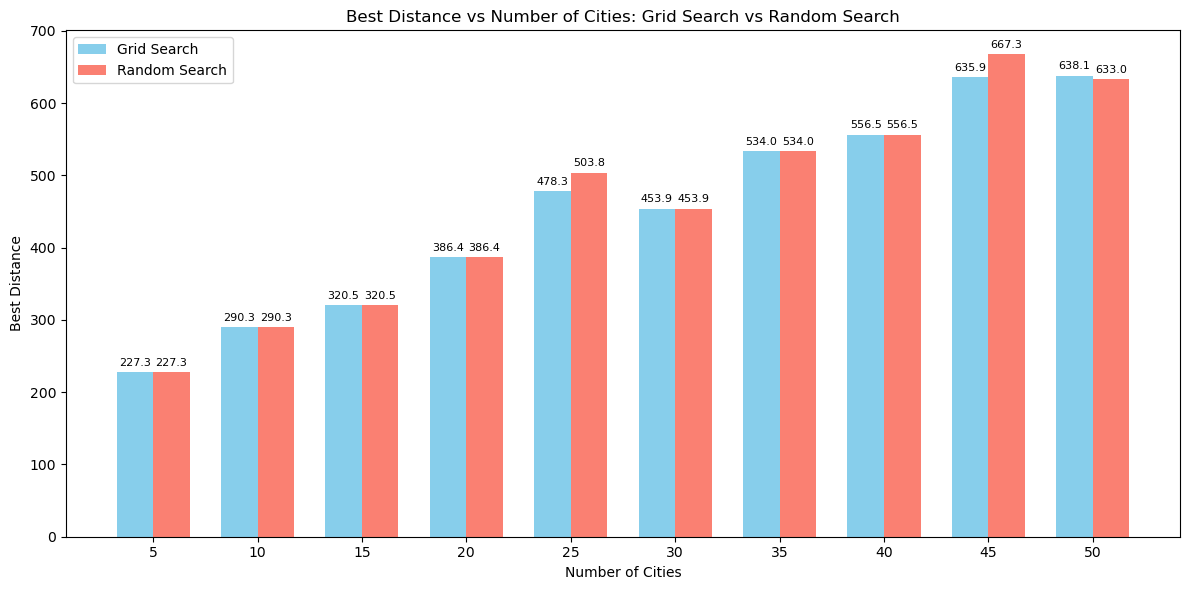

In [36]:
grid_df = pd.read_csv("../results/tabu__tuning_results_grid_search.csv")
random_df = pd.read_csv("../results/tabu_tuning_results_random_search.csv")

# Make sure both dataframes are sorted by num_cities
grid_df = grid_df.sort_values("num_cities")
random_df = random_df.sort_values("num_cities")

num_cities = grid_df["num_cities"]
grid_distances = grid_df["best_distance"]
random_distances = random_df["best_distance"]

# Set up bar positions
x = np.arange(len(num_cities))  # positions for groups
width = 0.35  # width of each bar

fig, ax = plt.subplots(figsize=(12,6))

# Plot bars
bars1 = ax.bar(x - width/2, grid_distances, width, label='Grid Search', color='skyblue')
bars2 = ax.bar(x + width/2, random_distances, width, label='Random Search', color='salmon')

# Labels and titles
ax.set_xlabel("Number of Cities")
ax.set_ylabel("Best Distance")
ax.set_title("Best Distance vs Number of Cities: Grid Search vs Random Search")
ax.set_xticks(x)
ax.set_xticklabels(num_cities)
ax.legend()

# Optional: show value on top of each bar
def autolabel(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.1f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0,3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=8)

autolabel(bars1)
autolabel(bars2)

plt.tight_layout()
plt.show()

Now we will take the best from 2 and put that inside another csv with the best hyper parameters

In [3]:
# Load results
grid_df = pd.read_csv("../results/tabu__tuning_results_grid_search.csv")
random_df = pd.read_csv("../results/tabu_tuning_results_random_search.csv")

# Combine both
combined_df = pd.concat([grid_df, random_df], ignore_index=True)

# For each number of cities, pick the row with the minimum best_distance
best_df = combined_df.loc[combined_df.groupby("num_cities")["best_distance"].idxmin()]

# Optional: reset index
best_df = best_df.reset_index(drop=True)

# Save to CSV
best_df.to_csv("../results/tabu_best_hyperparameters.csv", index=False)

print("Best hyperparameters saved to '../results/tabu_best_hyperparameters.csv'")
best_df

Best hyperparameters saved to '../results/tabu_best_hyperparameters.csv'


,num_cities,tabu_size,max_iterations,neighborhood_size,stall_limit,best_distance
0,5,5,300,100.0,50,227.345519
1,10,5,300,100.0,80,290.306774
2,15,5,300,100.0,50,320.525666
3,20,5,300,100.0,50,386.429689
4,25,20,300,NaN,50,478.346154
5,30,10,300,200.0,50,453.902302
6,35,10,300,NaN,50,534.003983
7,40,20,300,200.0,50,556.478718
8,45,20,300,200.0,50,635.939260
9,50,11,477,200.0,75,632.953882


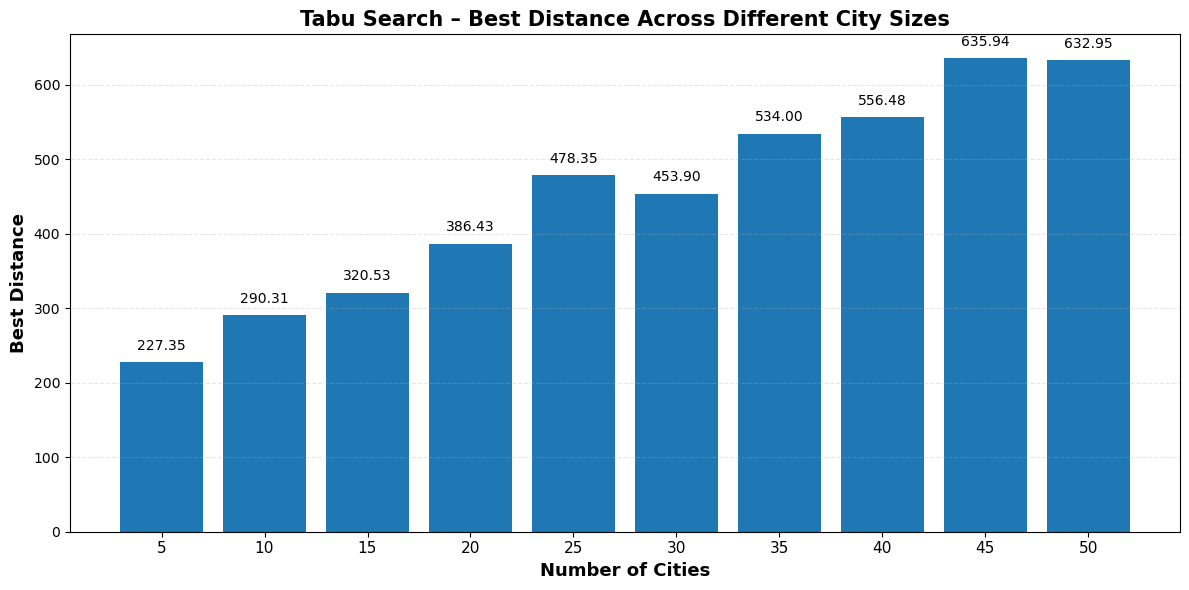

In [6]:
# Load best hyperparameters file
best_df = pd.read_csv("../results/tabu_best_hyperparameters.csv")

plt.figure(figsize=(12, 6))

# X positions and bar values
x = np.arange(len(best_df["num_cities"]))
distances = best_df["best_distance"]

bars = plt.bar(x, distances)

# Labels
plt.xlabel("Number of Cities", fontsize=13, fontweight="bold")
plt.ylabel("Best Distance", fontsize=13, fontweight="bold")
plt.title("Tabu Search – Best Distance Across Different City Sizes", fontsize=15, fontweight="bold")

# X-axis ticks
plt.xticks(x, best_df["num_cities"], fontsize=11)

# Adding numbers above the bars (clean spacing)
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + (0.02 * distances.max()),   # slight offset to avoid overlap
        f"{height:.2f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

# Optional grid
plt.grid(axis="y", alpha=0.3, linestyle="--")

plt.tight_layout()
plt.show()

In [38]:
best_df = pd.read_csv("../results/tabu_best_hyperparameters.csv")

for idx, row in best_df.iterrows():
    # Extracting best stored hyper parameters
    num_cities = int(row["num_cities"])
    tabu_size = int(row["tabu_size"])
    max_iterations = int(row["max_iterations"])
    # Handling neighborhood size
    neighborhood_size = int(row["neighborhood_size"]) if not pd.isna(row["neighborhood_size"]) else None
    stall_limit = int(row["stall_limit"])

    print(f"\nRunning Tabu Search for {num_cities} cities with best hyperparameters:" )
    print(f"tabu_size={tabu_size}, max_iterations={max_iterations}, neighborhood_size={neighborhood_size}, stall_limit={stall_limit}")

    # Get cities coordinates
    cities = cities_based_on_numbers(num_cities)

    random.seed(seed)
    np.random.seed(seed)
    # Run Tabu Search
    ts = TabuSearch(
        cities=cities,
        tabu_size=tabu_size,
        max_iterations=max_iterations,
        neighborhood_sample_size=neighborhood_size,
        stall_limit=stall_limit,
        aspiration=True,
        diversify_after=None
    )

    # Running the algorithm and measure execution time
    start_time = time.time()
    best_tour, best_distance = ts.solve()
    elapsed_time = time.time() - start_time

    print(f"Best tour: {[f'City_{i+1}' for i in best_tour]}")
    print(f"Best distance: {best_distance:.3f}, Execution time: {elapsed_time:.3f}s")


Running Tabu Search for 5 cities with best hyperparameters:
tabu_size=5, max_iterations=300, neighborhood_size=100, stall_limit=50
Best tour: ['City_5', 'City_2', 'City_3', 'City_4', 'City_1']
Best distance: 227.346, Execution time: 0.008s

Running Tabu Search for 10 cities with best hyperparameters:
tabu_size=5, max_iterations=300, neighborhood_size=100, stall_limit=80
Best tour: ['City_3', 'City_9', 'City_4', 'City_6', 'City_1', 'City_5', 'City_2', 'City_7', 'City_10', 'City_8']
Best distance: 290.307, Execution time: 0.144s

Running Tabu Search for 15 cities with best hyperparameters:
tabu_size=5, max_iterations=300, neighborhood_size=100, stall_limit=50
Best tour: ['City_11', 'City_15', 'City_10', 'City_3', 'City_8', 'City_12', 'City_9', 'City_14', 'City_4', 'City_6', 'City_1', 'City_13', 'City_5', 'City_2', 'City_7']
Best distance: 320.526, Execution time: 0.266s

Running Tabu Search for 20 cities with best hyperparameters:
tabu_size=5, max_iterations=300, neighborhood_size=100, 

In [39]:
"""
This script reads the best hyper parameters obtained from previous tuning and re runs tabu search for each city size. 
It measures best tour found , tour distance and execution time. 
"""
best_df = pd.read_csv("../results/tabu_best_hyperparameters.csv")

results = []

for idx, row in best_df.iterrows():
    num_cities = int(row["num_cities"])
    tabu_size = int(row["tabu_size"])
    max_iterations = int(row["max_iterations"])
    neighborhood_size = int(row["neighborhood_size"]) if not pd.isna(row["neighborhood_size"]) else None
    stall_limit = int(row["stall_limit"])

    print(f"\nRunning Tabu Search for {num_cities} cities with best hyperparameters:" )
    print(f"tabu_size={tabu_size}, max_iterations={max_iterations}, neighborhood_size={neighborhood_size}, stall_limit={stall_limit}")

    # Get cities coordinates
    cities = cities_based_on_numbers(num_cities)

    # Fix randomness
    random.seed(seed)
    np.random.seed(seed)

    # Run Tabu Search
    ts = TabuSearch(
        cities=cities,
        tabu_size=tabu_size,
        max_iterations=max_iterations,
        neighborhood_sample_size=neighborhood_size,
        stall_limit=stall_limit,
        aspiration=True,
        diversify_after=None
    )

    start_time = time.time()
    best_tour, best_distance = ts.solve()
    elapsed_time = time.time() - start_time

    print(f"Best tour: {[f'City_{i+1}' for i in best_tour]}")
    print(f"Best distance: {best_distance:.3f}, Execution time: {elapsed_time:.3f}s")

    # Store results
    results.append([
        num_cities,
        tabu_size,
        max_iterations,
        neighborhood_size,
        stall_limit,
        best_distance,
        elapsed_time
    ])

# Save results to CSV
output_csv = "../results/tabu_best_results_best_hyperparameters.csv"
with open(output_csv, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["num_cities", "tabu_size", "max_iterations", "neighborhood_size", "stall_limit", "best_distance", "execution_time"])
    writer.writerows(results)

print(f"\nAll results saved to: {output_csv}")


Running Tabu Search for 5 cities with best hyperparameters:
tabu_size=5, max_iterations=300, neighborhood_size=100, stall_limit=50
Best tour: ['City_5', 'City_2', 'City_3', 'City_4', 'City_1']
Best distance: 227.346, Execution time: 0.007s

Running Tabu Search for 10 cities with best hyperparameters:
tabu_size=5, max_iterations=300, neighborhood_size=100, stall_limit=80
Best tour: ['City_3', 'City_9', 'City_4', 'City_6', 'City_1', 'City_5', 'City_2', 'City_7', 'City_10', 'City_8']
Best distance: 290.307, Execution time: 0.156s

Running Tabu Search for 15 cities with best hyperparameters:
tabu_size=5, max_iterations=300, neighborhood_size=100, stall_limit=50
Best tour: ['City_11', 'City_15', 'City_10', 'City_3', 'City_8', 'City_12', 'City_9', 'City_14', 'City_4', 'City_6', 'City_1', 'City_13', 'City_5', 'City_2', 'City_7']
Best distance: 320.526, Execution time: 0.286s

Running Tabu Search for 20 cities with best hyperparameters:
tabu_size=5, max_iterations=300, neighborhood_size=100, 

As per now we have got the best hyper parameters with least distance using the same seed and same hyper parameters we will use this result to compare with evolution algorithm and find the best one which performs best.

# Part 3 : Evolutionary Algorithm Implementation

An evolutionary algorithm is a type of optimization algorithm that follows the pattern of biological evolution. It works by creating an initial population of random candidate solutions and iteratively refining them. After refining for a specific time, the solution gets better and comes in the position of fitness. We can compare it with the mutation of genes, where the mutation depends on the environmental factors. And for suiting the environment, mutation makes the species smarter. 
Here for evolutionary algorithm we follow these process 
* Creation of Initial population
* Do a mutation in every iteration
* Take the best mutation

For the travelling salesman problem, we will select the algorithm with the optimum solution between genetic algorithm and ant colony optimisation, then we will select the best one between them. 

## Genetic Algorithm

In [35]:
class GeneticAlgorithm:
    """
    Genetic Algorithm (GA) for solving TSP.

    GA maintains a population of candidate tours and evolves them through
    selection, crossover, and mutation.

    Time Complexity: O(iterations * population_size * n)
    Space Complexity: O(population_size * n)
    """

    def __init__(self, cities: np.ndarray, population_size: int = 50,crossover_rate: float = 0.9, mutation_rate: float = 0.02,
                 tournament_size: int = 5, max_generations: int = 1000):
        """
        Initialize Genetic Algorithm.

        Args:
            cities: Array of city coordinates
            population_size: Number of individuals in the population
            mutation_rate: Probability of mutation
            crossover_rate: Probability of crossover
            tournament_size: Number of individuals sampled for tournament selection
            max_iterations: Maximum iterations
        """
        self.cities = cities
        self.n_cities = len(cities)

        self.population_size = population_size
        self.mutation_rate = mutation_rate
        self.crossover_rate = crossover_rate
        self.tournament_size = tournament_size
        self.max_generations = max_generations
        
        # Population and fitness scores
        self.population = []
        self.scores = []

        # Tracking the best tour and distance
        self.best_tour = None
        self.best_distance = float('inf')

        # Storing history for analysis
        self.history = []


    # Initialization

    def initialize_population(self):
        for _ in range(self.population_size):
            # Creating a random tour
            tour = list(range(self.n_cities))
            random.shuffle(tour)
            # Compute the total distance
            dist = calculate_total_distance(tour, self.cities)

            self.population.append(tour)
            self.scores.append(dist)

            # Updating global best if improved
            if dist < self.best_distance:
                self.best_distance = dist
                self.best_tour = tour.copy()


    # Tournament Selection

    def tournament_selection(self):
        # Random selection sample a few individuals
        selected = random.sample(range(self.population_size), self.tournament_size)

        # Returning the one with shortest distance
        best_idx = min(selected, key=lambda i: self.scores[i])
        return self.population[best_idx]


    # Order Crossover (OX)

    def ordered_crossover(self, parent1, parent2):
        if random.random() > self.crossover_rate:
            return parent1.copy()

        # Random select a segment from parent1
        start, end = sorted(random.sample(range(self.n_cities), 2))
        child = [-1] * self.n_cities

        # Copy middle slice from parent1
        child[start:end+1] = parent1[start:end+1]

        # Fill remaining from parent2 in order
        pointer = 0
        for city in parent2:
            if city not in child:
                while child[pointer] != -1:
                    pointer += 1
                child[pointer] = city
        return child


    # Swap Mutation

    def mutate(self, tour):
        if random.random() < self.mutation_rate:
            i, j = random.sample(range(self.n_cities), 2)
            tour[i], tour[j] = tour[j], tour[i]
        return tour    

    # Main GA Loop
    def solve(self):
        self.initialize_population()

        # Save initial state
        self.history.append({
            'iteration': 0,
            'current_distance': min(self.scores),
            'best_distance': self.best_distance,
            'tour': self.population[np.argmin(self.scores)].copy(),
            'best_tour': self.best_tour.copy()
        })

        for iteration in range(1, self.max_generations + 1):
            new_population = []

            # Create next generation
            for _ in range(self.population_size):
                # Parent selection
                parent1 = self.tournament_selection()
                parent2 = self.tournament_selection()

                # Applying crossover and mutation
                child = self.ordered_crossover(parent1, parent2)
                child = self.mutate(child)

                new_population.append(child)

            # Updating population and evaluation fitness
            self.population = new_population
            self.scores = [calculate_total_distance(t, self.cities) for t in self.population]

            # Current best
            idx = np.argmin(self.scores)
            current_distance = self.scores[idx]
            current_tour = self.population[idx]

            # Global best
            if current_distance < self.best_distance:
                self.best_distance = current_distance
                self.best_tour = current_tour.copy()

            # Save history every 5 iterations
            if iteration % 5 == 0:
                self.history.append({
                    'iteration': iteration,
                    'current_distance': current_distance,
                    'best_distance': self.best_distance,
                    'tour': current_tour.copy(),
                    'best_tour': self.best_tour.copy()
                })

        return self.best_tour, self.best_distance


## How to use Genetic Algorithm

In [41]:
num_cities = 20
cities = cities_based_on_numbers(num_cities)

In [42]:
# We will perform in here based on default values
random.seed(seed)
np.random.seed(seed)

# Run GA
ga = GeneticAlgorithm(
    cities=cities,
    population_size=50,       # typical default
    crossover_rate=0.9,
    mutation_rate=0.02,
    tournament_size=5,
    max_generations=1000
)

start_time = time.time()
best_tour, best_distance = ga.solve()
elapsed_time = time.time() - start_time

In [43]:
print(f"Best tour for {num_cities} cities: {[f'City_{i+1}' for i in best_tour]}")
print(f"Best distance: {best_distance:.3f}, Execution time: {elapsed_time:.3f}s")

Best tour for 20 cities: ['City_20', 'City_2', 'City_18', 'City_5', 'City_1', 'City_17', 'City_6', 'City_4', 'City_13', 'City_19', 'City_3', 'City_8', 'City_14', 'City_9', 'City_12', 'City_10', 'City_16', 'City_11', 'City_15', 'City_7']
Best distance: 462.296, Execution time: 2.497s


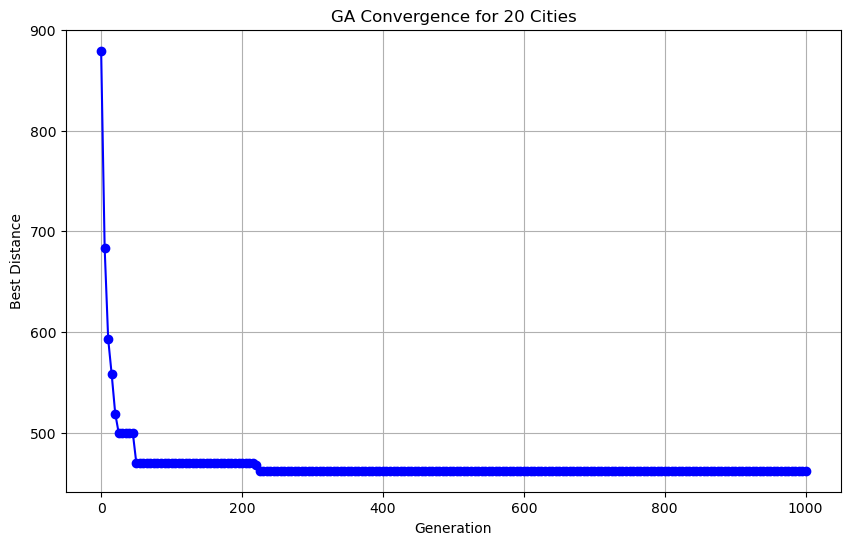

In [44]:
iterations = [h['iteration'] for h in ga.history]
best_scores = [h['best_distance'] for h in ga.history]

plt.figure(figsize=(10, 6))
plt.plot(iterations, best_scores, marker='o', linestyle='-', color='blue')
plt.title(f'GA Convergence for {num_cities} Cities')
plt.xlabel('Generation')
plt.ylabel('Best Distance')
plt.grid(True)
plt.show()



## Scalibility Test For GA

In [45]:
# Running genetic algorithm with brief log
def run_ga_with_brief_log(
        num_cities,
        population_size=50,
        crossover_rate=0.9,
        mutation_rate=0.02,
        tournament_size=5,
        max_generations=1000
):
    """
    Running Genetic Algorithm for a given number of cities.
    Saving per-generation logs (tour, distances) to CSV.
    """

    # Generate city coordinates
    cities = cities_based_on_numbers(num_cities)

    # Random seed for choosing random path
    random.seed(42)
    np.random.seed(42)

    # Initialize GA with specified hyperparameters
    ga = GeneticAlgorithm(
        cities=cities,
        population_size=population_size,
        crossover_rate=crossover_rate,
        mutation_rate=mutation_rate,
        tournament_size=tournament_size,
        max_generations=max_generations
    )

    # Running GA and measuring time
    start_time = time.time()
    best_tour, best_distance = ga.solve()
    elapsed = time.time() - start_time

    # prepare log rows
    hist_rows = []
    for h in ga.history:
        tour = h['tour']
        # Converting tour indices to readable city names
        tour_cities = " -> ".join([f"City_{i+1}" for i in tour])

        hist_rows.append({
            "iteration": h["iteration"],
            "current_distance": h["current_distance"],
            "best_distance": h["best_distance"],
            "route": tour_cities
        })

    # Converting history to dataframe
    hist_df = pd.DataFrame(hist_rows)

    # Save CSV file
    hist_filename = f"../results/ga_history_{num_cities}cities.csv"
    hist_df.to_csv(hist_filename, index=False)
    print(f"GA history saved to {hist_filename}")

    # return summary for scalability table
    result = {
        "n_cities": num_cities,
        "best_distance": best_distance,
        "time_sec": elapsed,
        "generations_logged": len(ga.history) * 5    # because you log every 5 gens
    }
    return result


In [36]:
"""
This function run_ga_path_finding and run_ga_with_brief_log does the same thing almost except run_ga_with_brief_log does keep the track of visited cities
"""
def run_ga_path_finding(
        num_cities,
        population_size=50,
        crossover_rate=0.9,
        mutation_rate=0.02,
        tournament_size=5,
        max_generations=1000
):
    """
    Run GA once for scalability evaluation.
    Returns only key metrics (no CSV).
    """

    # Generating coordinates for the specified number of cities
    cities = cities_based_on_numbers(num_cities)

    random.seed(42)
    np.random.seed(42)

    # Initialising the GA with selected hyperparameters
    ga = GeneticAlgorithm(
        cities=cities,
        population_size=population_size,
        crossover_rate=crossover_rate,
        mutation_rate=mutation_rate,
        tournament_size=tournament_size,
        max_generations=max_generations
    )

    # Measuring execution time
    start_time = time.time()

    # Running genetic algorithm
    best_tour, best_distance = ga.solve()
    # Calculating total runtime
    elapsed = time.time() - start_time

    # Summary return 
    return {
        "n_cities": num_cities,
        "best_distance": best_distance,
        "time_sec": elapsed,
        "generations_effective": len(ga.history) * 5    # logs every 5 gens
    }


In [47]:
# In here we will measure with different city size and collect the time complexity
city_sizes = [5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
ga_results = []

print("Genetic Algorithm – scalability test")

for n in city_sizes:
    # run_ga_path_finding simply returns brief metrics (like SA version)
    res = run_ga_path_finding(num_cities=n)
    ga_results.append(res)
    print(f"{n:2d} cities -> "
          f"best_distance={res['best_distance']:.3f}, "
          f"time={res['time_sec']:.4f}s, "
          f"gens≈{res['generations_effective']}")

# Build DataFrame with brief metrics
ga_scal_df = pd.DataFrame(ga_results)

print("\nGA scalability summary")
print(ga_scal_df[[
    "n_cities", "best_distance", "time_sec", "generations_effective"
]].to_string(index=False))

# Save overall scalability table
ga_scal_df.to_csv("../results/ga_history_10-50_cities.csv", index=False)
print("\nSaved overall scalability results to ga_history_10-50_cities.csv")


Genetic Algorithm – scalability test
 5 cities -> best_distance=227.346, time=1.0274s, gens≈1005
10 cities -> best_distance=290.307, time=1.4311s, gens≈1005
15 cities -> best_distance=353.223, time=1.8981s, gens≈1005
20 cities -> best_distance=462.296, time=2.4476s, gens≈1005
25 cities -> best_distance=489.284, time=3.0335s, gens≈1005
30 cities -> best_distance=546.489, time=3.3660s, gens≈1005
35 cities -> best_distance=723.091, time=3.8328s, gens≈1005
40 cities -> best_distance=797.392, time=4.4415s, gens≈1005
45 cities -> best_distance=937.486, time=4.9082s, gens≈1005
50 cities -> best_distance=998.730, time=5.5262s, gens≈1005

GA scalability summary
 n_cities  best_distance  time_sec  generations_effective
        5     227.345519  1.027406                   1005
       10     290.306774  1.431100                   1005
       15     353.223137  1.898059                   1005
       20     462.295820  2.447643                   1005
       25     489.284274  3.033483               

In [48]:
city_sizes = [10, 20, 30, 40, 50]
all_results = []

for n in city_sizes:
    res = run_ga_with_brief_log(n)   # Finding history of path finding
    all_results.append(res)

GA history saved to ../results/ga_history_10cities.csv
GA history saved to ../results/ga_history_20cities.csv
GA history saved to ../results/ga_history_30cities.csv
GA history saved to ../results/ga_history_40cities.csv
GA history saved to ../results/ga_history_50cities.csv


## Ant Colony Optimization

In [37]:
class AntColonyOptimization:
    """
    Ant Colony Optimization (ACO) for solving TSP.

    ACO maintains a set of artificial ants which build solutions
    probabilistically using pheromone trails and heuristic information.

    Time Complexity: O(iterations * n_ants * n^2)
    Space Complexity: O(n^2) for pheromone matrix
    """

    def __init__(self, cities: np.ndarray, n_ants: int = 30, alpha: float = 1.0, beta: float = 5.0, 
                 evaporation_rate: float = 0.5, q: float = 100, max_iterations: int = 1000):
        """
        Initialize ACO.

        Args:
            cities: Array of city coordinates
            n_ants: Number of ants
            alpha: Influence of pheromone
            beta: Influence of heuristic (1/distance)
            evaporation_rate: Pheromone evaporation coefficient
            q: Pheromone deposit factor
            max_iterations: Maximum iterations
        """
        self.cities = cities
        self.n_cities = len(cities)
        self.n_ants = n_ants
        self.alpha = alpha
        self.beta = beta
        self.evaporation_rate = evaporation_rate
        self.q = q
        self.max_iterations = max_iterations

        # Initialize pheromone matrix
        self.pheromone = np.ones((self.n_cities, self.n_cities))
        # Compute heuristic info
        self.eta = 1 / (np.linalg.norm(cities[:, np.newaxis] - cities[np.newaxis, :], axis=2) + 1e-10)  # heuristic: 1/distance

        # Track best tour and distance
        self.best_tour = None
        self.best_distance = float('inf')
        self.history = []

    def construct_solution(self):
        """Each ant builds a tour based on probabilities from pheromone and heuristic."""
        tours = []
        distances = []

        for _ in range(self.n_ants):
            # Initialize unvisited cities and random selected start
            unvisited = list(range(self.n_cities))
            start = random.choice(unvisited)
            tour = [start]
            unvisited.remove(start)

            while unvisited: # Loop continues untill all cities are visited
                current = tour[-1] # Current city is the last one
                probs = [] # Initialize list to store probability score
                for city in unvisited:
                    tau = self.pheromone[current, city] ** self.alpha # Pheromone influence
                    eta = self.eta[current, city] ** self.beta # Heuristic influence
                    probs.append(tau * eta) # Combine pheromone and heuristic 
                probs = np.array(probs)
                probs /= probs.sum() # Normalize raw scores into a probability distribution (sum=1)
                next_city = np.random.choice(unvisited, p=probs)
                tour.append(next_city) # Add selected city to the current tour
                unvisited.remove(next_city) # Removing selected city from unvisited list to avoid revisiting

            tour_distance = calculate_total_distance(tour, self.cities)
            tours.append(tour)
            distances.append(tour_distance)

            # Update global best
            if tour_distance < self.best_distance:
                self.best_distance = tour_distance
                self.best_tour = tour.copy()

        return tours, distances

    def update_pheromone(self, tours, distances):
        """Evaporate pheromone and deposit new pheromone based on tour quality."""
        self.pheromone *= (1 - self.evaporation_rate)
        for tour, dist in zip(tours, distances):
            for i in range(len(tour)):
                a, b = tour[i], tour[(i + 1) % self.n_cities]
                self.pheromone[a, b] += self.q / dist
                self.pheromone[b, a] += self.q / dist

    def solve(self):
        """Main ACO loop."""
        for iteration in range(1, self.max_iterations + 1):
            # Each ant constructs a solution
            tours, distances = self.construct_solution()
            self.update_pheromone(tours, distances)

            # Save history every 5 iterations
            if iteration % 5 == 0:
                best_idx = np.argmin(distances)
                self.history.append({
                    'iteration': iteration,
                    'best_distance': self.best_distance,
                    'current_distance': distances[best_idx],
                    'best_tour': self.best_tour.copy(),
                    'current_tour': tours[best_idx].copy()
                })

        return self.best_tour, self.best_distance


## How to use ant colony optimization

In [50]:
random.seed(seed)
np.random.seed(seed)

# Run ACO
aco = AntColonyOptimization(
    cities=cities,
    n_ants=30,                # typical default
    alpha=1.0,             # pheromone influence
    beta=5.0,                 # heuristic influence
    evaporation_rate=0.5, # pheromone evaporation
    q=100, # pheromone deposit factor
    max_iterations=1000   # maximum iterations
)
best_tour_labels = [f"City_{i+1}" for i in best_tour]  # convert indices to City_X format

start_time = time.time()
best_tour, best_distance = aco.solve()
elapsed_time = time.time() - start_time

print(f"ACO Best Distance: {best_distance:.3f}")
print(f"Elapsed Time: {elapsed_time:.2f}s")
print(f"Best tour for {len(cities)} cities: {best_tour_labels}")

ACO Best Distance: 386.430
Elapsed Time: 16.32s
Best tour for 20 cities: ['City_20', 'City_2', 'City_18', 'City_5', 'City_1', 'City_17', 'City_6', 'City_4', 'City_13', 'City_19', 'City_3', 'City_8', 'City_14', 'City_9', 'City_12', 'City_10', 'City_16', 'City_11', 'City_15', 'City_7']


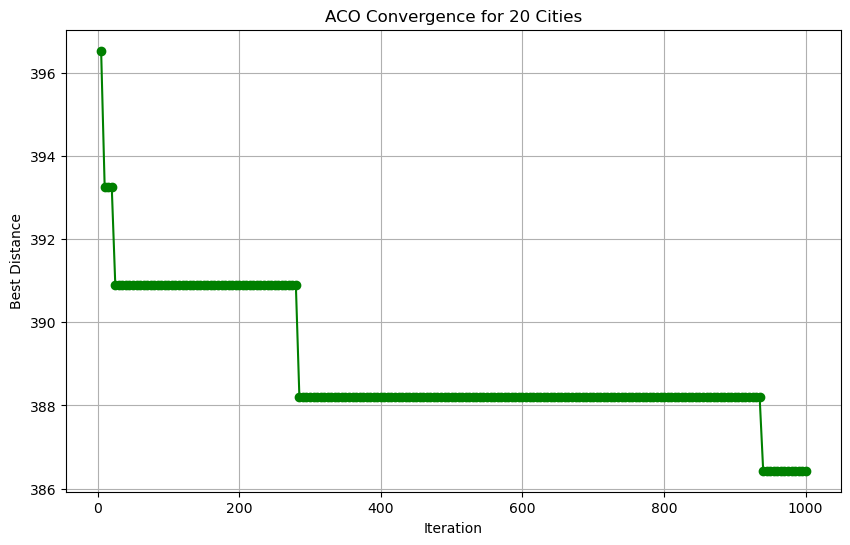

In [51]:
iterations = [h['iteration'] for h in aco.history]
best_scores = [h['best_distance'] for h in aco.history]

plt.figure(figsize=(10, 6))
plt.plot(iterations, best_scores, marker='o', linestyle='-', color='green')
plt.title(f'ACO Convergence for {num_cities} Cities')
plt.xlabel('Iteration')
plt.ylabel('Best Distance')
plt.grid(True)
plt.show()


## Scalibility Test For ACO

In [38]:
# Running ACO with brief log tracks the visited cities for each iteration and stores them in the log
def run_aco_with_brief_log(
        num_cities,
        n_ants=30,
        alpha=1.0,
        beta=5.0,
        evaporation_rate=0.5,
        q=100,
        max_iterations=1000
):
    """
    Run Ant Colony Optimization for a given number of cities.
    Save per-iteration logs (tour, distances) to CSV.
    """
    # Preparing city coordinates
    cities = cities_based_on_numbers(num_cities)

    random.seed(42)
    np.random.seed(42)

    # Initialize ACO object and hyperparameters
    aco = AntColonyOptimization(
        cities=cities,
        n_ants=n_ants,
        alpha=alpha,
        beta=beta,
        evaporation_rate=evaporation_rate,
        q=q,
        max_iterations=max_iterations
    )

    # Running optimization and measuring execution time
    start_time = time.time()
    best_tour, best_distance = aco.solve()
    elapsed = time.time() - start_time

    # prepare log rows
    hist_rows = []
    for h in aco.history:
        tour = h['current_tour']
        tour_cities = " -> ".join([f"City_{i+1}" for i in tour])

        hist_rows.append({
            "iteration": h["iteration"],
            "current_distance": h["current_distance"],
            "best_distance": h["best_distance"],
            "route": tour_cities
        })

    hist_df = pd.DataFrame(hist_rows)

    # Save CSV file
    hist_filename = f"../results/aco_history_{num_cities}cities.csv"
    hist_df.to_csv(hist_filename, index=False)
    print(f"ACO history saved to {hist_filename}")

    # return summary for scalability table
    result = {
        "n_cities": num_cities,
        "best_distance": best_distance,
        "time_sec": elapsed,
        "iterations_logged": len(aco.history) * 5  # because history logged every 5 iterations
    }
    return result


In [39]:
"""
This function and the previous one does almost same thing except run_aco_with_brief_log tracks the visited cities and keep them saved
"""
def run_aco_path_finding(
        num_cities,
        n_ants=30,
        alpha=1.0,
        beta=5.0,
        evaporation_rate=0.5,
        q=100,
        max_iterations=1000
):
    """
    Run ACO once for scalability evaluation.
    Returns only key metrics (no CSV).
    """

    # Generative city coordinate 
    cities = cities_based_on_numbers(num_cities)

    random.seed(42)
    np.random.seed(42)

    # Initializing ACO with selected parameters 
    aco = AntColonyOptimization(
        cities=cities,
        n_ants=n_ants,
        alpha=alpha,
        beta=beta,
        evaporation_rate=evaporation_rate,
        q=q,
        max_iterations=max_iterations
    )

    # Counting time
    start_time = time.time()
    best_tour, best_distance = aco.solve()
    # Calculating elapsed time
    elapsed = time.time() - start_time

    return {
        "n_cities": num_cities,
        "best_distance": best_distance,
        "time_sec": elapsed,
        "iterations_effective": len(aco.history) * 5   # because history logged every 5 iterations
    }


In [54]:
# Measure ACO performance across different city sizes
city_sizes = [5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
aco_results = []

print("Ant Colony Optimization – scalability test")

for n in city_sizes:
    # run_aco_path_finding returns brief metrics
    res = run_aco_path_finding(num_cities=n)
    aco_results.append(res)
    print(f"{n:2d} cities -> "
          f"best_distance={res['best_distance']:.3f}, "
          f"time={res['time_sec']:.4f}s, "
          f"iters≈{res['iterations_effective']}")

# Build DataFrame with brief metrics
aco_scal_df = pd.DataFrame(aco_results)

print("\nACO scalability summary")
print(aco_scal_df[[
    "n_cities", "best_distance", "time_sec", "iterations_effective"
]].to_string(index=False))

# Save overall scalability table
aco_scal_df.to_csv("../results/aco_history_5-50_cities.csv", index=False)
print("\nSaved overall scalability results to aco_history_5-50_cities.csv")


Ant Colony Optimization – scalability test
 5 cities -> best_distance=227.346, time=3.1877s, iters≈1000
10 cities -> best_distance=290.307, time=7.0026s, iters≈1000
15 cities -> best_distance=320.526, time=11.4272s, iters≈1000
20 cities -> best_distance=386.430, time=16.4702s, iters≈1000
25 cities -> best_distance=407.308, time=21.7103s, iters≈1000
30 cities -> best_distance=455.057, time=27.3100s, iters≈1000
35 cities -> best_distance=466.889, time=34.2885s, iters≈1000
40 cities -> best_distance=494.493, time=39.5513s, iters≈1000
45 cities -> best_distance=537.832, time=46.6821s, iters≈1000
50 cities -> best_distance=566.751, time=55.3176s, iters≈1000

ACO scalability summary
 n_cities  best_distance  time_sec  iterations_effective
        5     227.345519  3.187654                  1000
       10     290.306774  7.002596                  1000
       15     320.525666 11.427159                  1000
       20     386.429689 16.470206                  1000
       25     407.307567 21.7

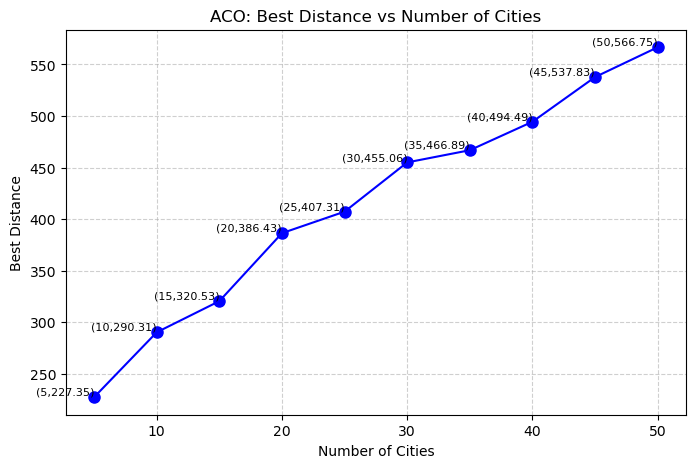

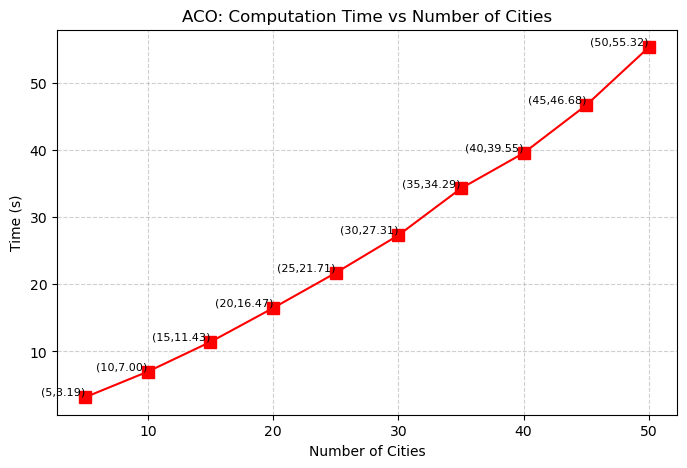

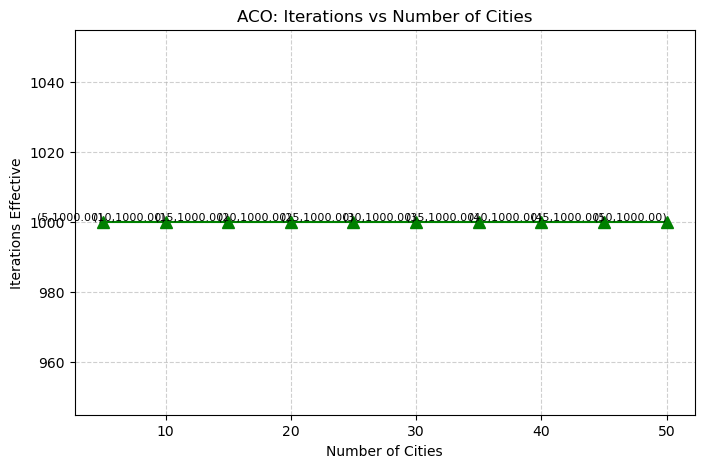

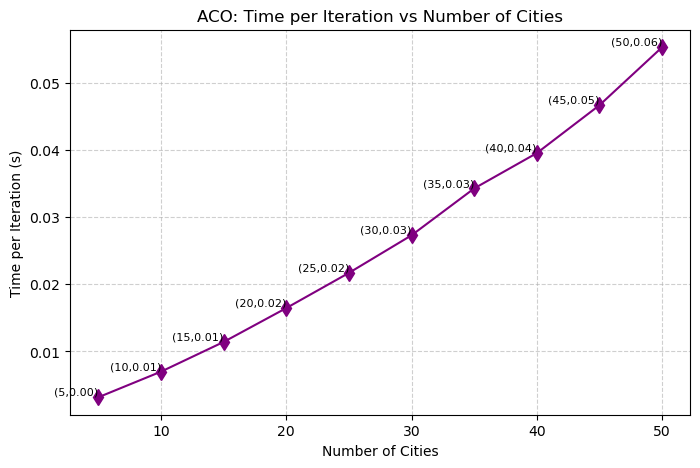

In [5]:
# Load CSV
df = pd.read_csv("../results/aco_history_5-50_cities.csv")

# Function to add coordinates on points
def annotate_points(x, y):
    for i, j in zip(x, y):
        plt.text(i, j, f'({i},{j:.2f})', fontsize=8, ha='right', va='bottom')

# Plot 1: Best Distance vs Number of Cities
plt.figure(figsize=(8,5))
plt.plot(df['n_cities'], df['best_distance'], marker='o', color='blue', linestyle='-', markersize=8)
annotate_points(df['n_cities'], df['best_distance'])
plt.title('ACO: Best Distance vs Number of Cities')
plt.xlabel('Number of Cities')
plt.ylabel('Best Distance')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Plot 2: Computation Time vs Number of Cities
plt.figure(figsize=(8,5))
plt.plot(df['n_cities'], df['time_sec'], marker='s', color='red', linestyle='-', markersize=8)
annotate_points(df['n_cities'], df['time_sec'])
plt.title('ACO: Computation Time vs Number of Cities')
plt.xlabel('Number of Cities')
plt.ylabel('Time (s)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Plot 3: Iterations Effective vs Number of Cities
plt.figure(figsize=(8,5))
plt.plot(df['n_cities'], df['iterations_effective'], marker='^', color='green', linestyle='-', markersize=8)
annotate_points(df['n_cities'], df['iterations_effective'])
plt.title('ACO: Iterations vs Number of Cities')
plt.xlabel('Number of Cities')
plt.ylabel('Iterations Effective')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Time per Iteration
df['time_per_iteration'] = df['time_sec'] / df['iterations_effective']
plt.figure(figsize=(8,5))
plt.plot(df['n_cities'], df['time_per_iteration'], marker='d', color='purple', linestyle='-', markersize=8)
annotate_points(df['n_cities'], df['time_per_iteration'])
plt.title('ACO: Time per Iteration vs Number of Cities')
plt.xlabel('Number of Cities')
plt.ylabel('Time per Iteration (s)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [55]:
city_sizes = [10, 20, 30, 40, 50]
all_results = []

for n in city_sizes:
    res = run_aco_with_brief_log(n)   # Finding history of path finding
    all_results.append(res)

ACO history saved to ../results/aco_history_10cities.csv
ACO history saved to ../results/aco_history_20cities.csv
ACO history saved to ../results/aco_history_30cities.csv
ACO history saved to ../results/aco_history_40cities.csv
ACO history saved to ../results/aco_history_50cities.csv


## Side by side comparison between GA and ACO

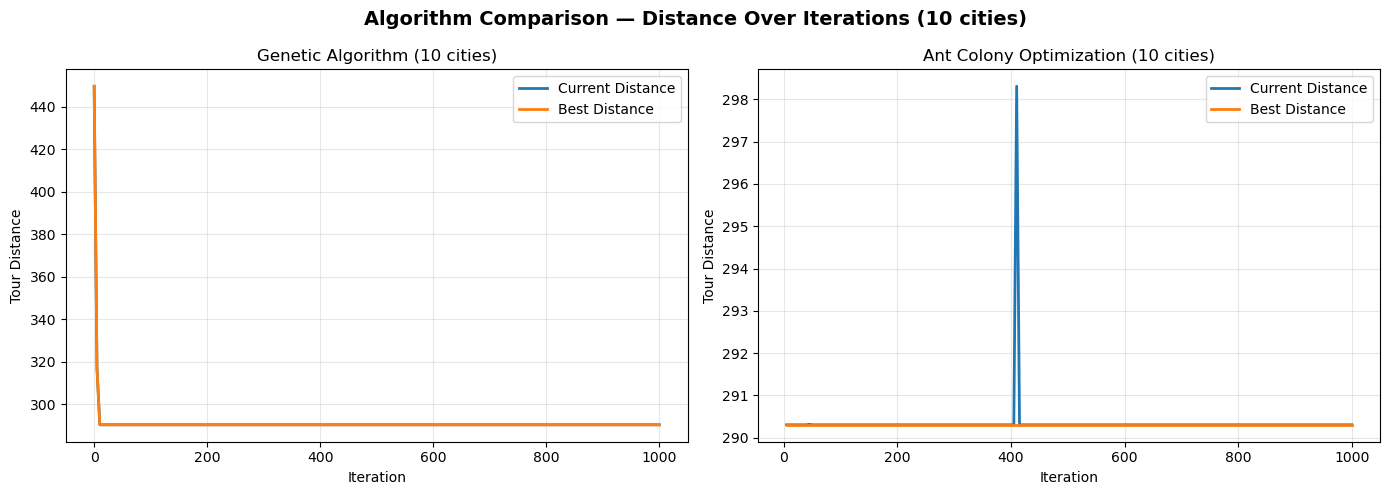

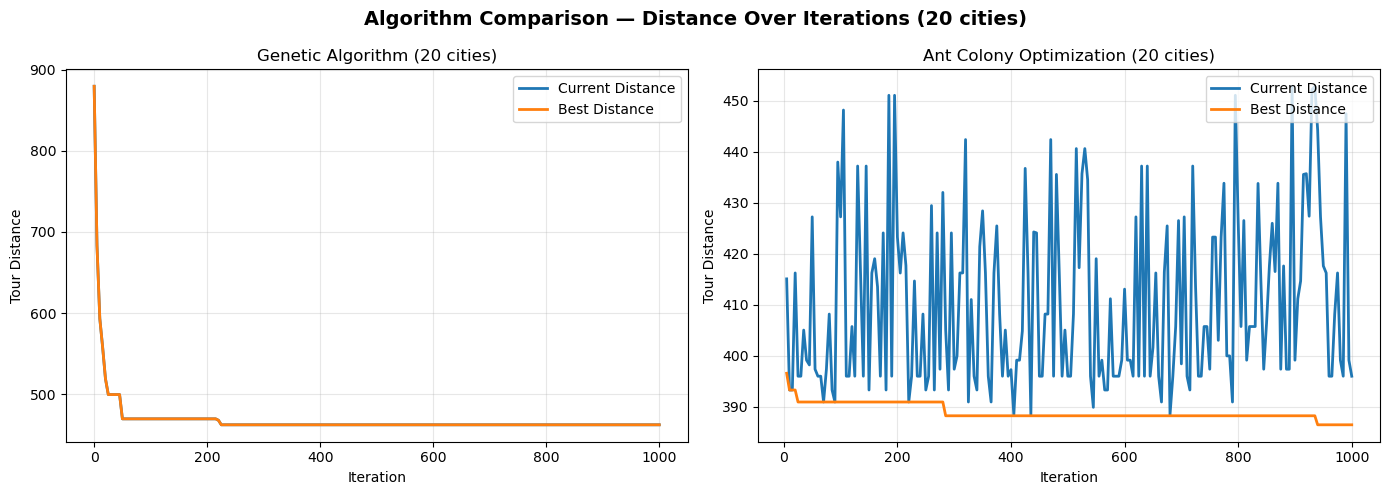

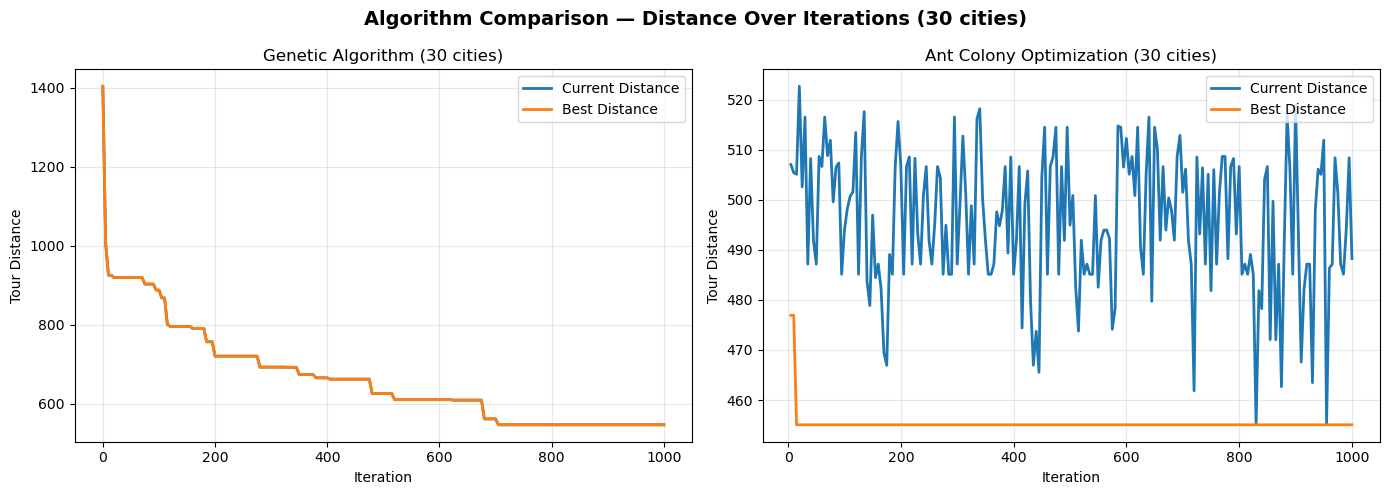

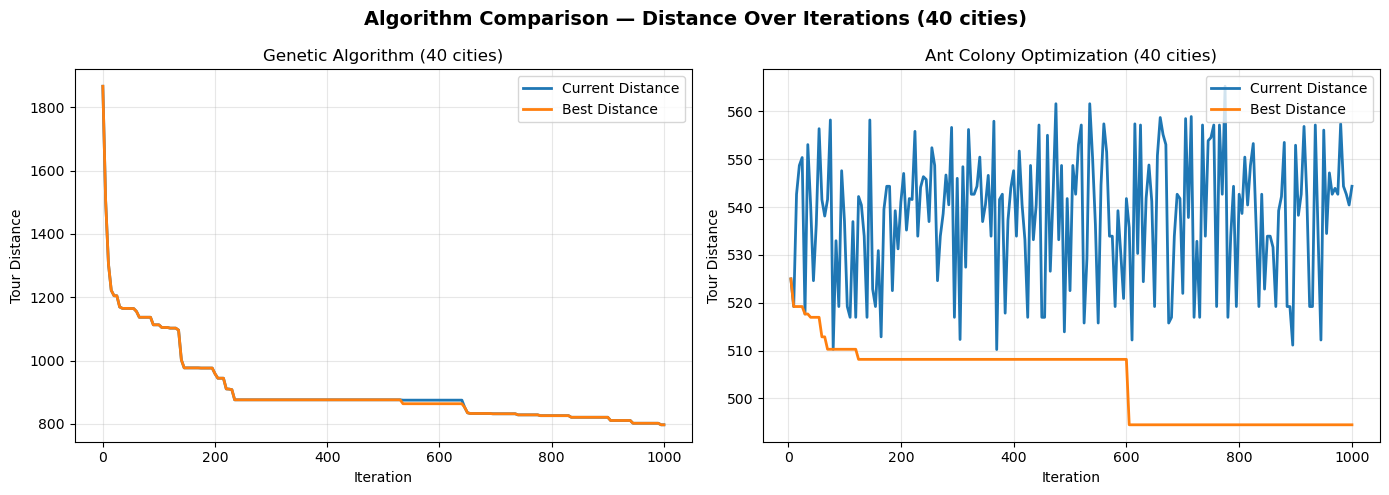

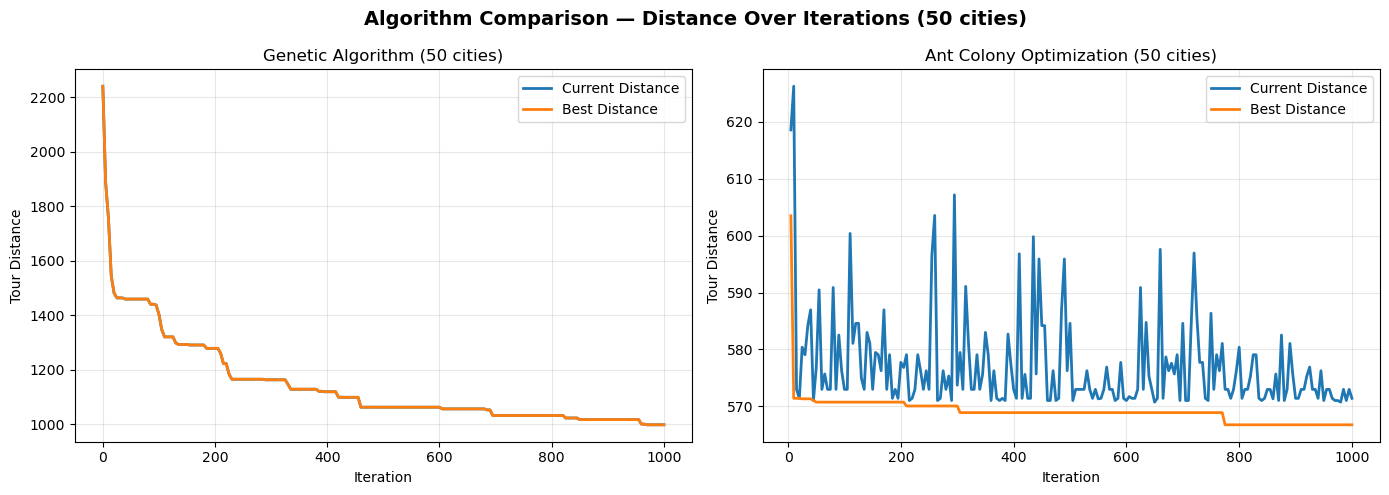

In [56]:
# Generative ai help was taken for plotting this graph
city_sizes = [10, 20, 30, 40, 50]

for n in city_sizes:
    # Load both CSVs
    sa_df = pd.read_csv(f"../results/ga_history_{n}cities.csv")
    ts_df = pd.read_csv(f"../results/aco_history_{n}cities.csv")
    
    # Create figure with 2 subplots side by side
    fig, (ax1_sa, ax1_ts) = plt.subplots(1, 2, figsize=(14, 5))

    # Genetic algorithm
    ax1_sa.plot(sa_df["iteration"], sa_df["current_distance"],label="Current Distance", color="tab:blue", linewidth=2)
    ax1_sa.plot(sa_df["iteration"], sa_df["best_distance"],label="Best Distance", color="tab:orange", linewidth=2)
    ax1_sa.set_xlabel("Iteration")
    ax1_sa.set_ylabel("Tour Distance")
    ax1_sa.grid(True, alpha=0.3)
    ax1_sa.legend(loc="upper right")
    ax1_sa.set_title(f"Genetic Algorithm ({n} cities)")

    # Ant colony optimization 
    ax1_ts.plot(ts_df["iteration"], ts_df["current_distance"],label="Current Distance", color="tab:blue", linewidth=2)
    ax1_ts.plot(ts_df["iteration"], ts_df["best_distance"],label="Best Distance", color="tab:orange", linewidth=2)
    ax1_ts.set_xlabel("Iteration")
    ax1_ts.set_ylabel("Tour Distance")
    ax1_ts.grid(True, alpha=0.3)
    ax1_ts.legend(loc="upper right")
    ax1_ts.set_title(f"Ant Colony Optimization ({n} cities)")

    plt.suptitle(f"Algorithm Comparison — Distance Over Iterations ({n} cities)", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()


Based on this graph, ACO clearly achieves a significantly shorter tour than GA, and it does so in far fewer “effective” iterations, even though both are run for 1000 iterations.

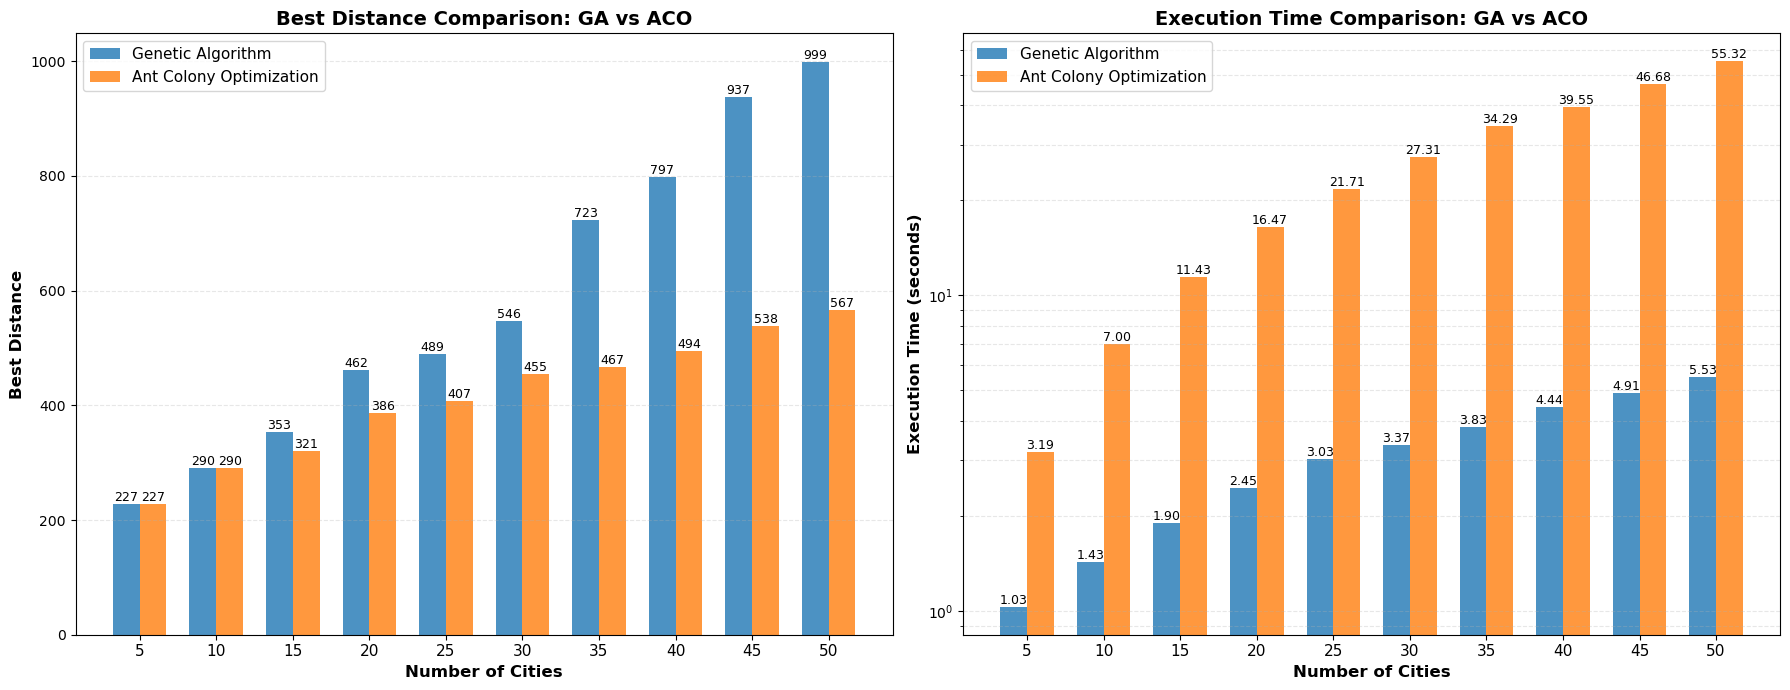

GENETIC ALGORITHM vs ANT COLONY OPTIMIZATION - PERFORMANCE COMPARISON
Cities     GA Distance        ACO Distance       GA Time (s)     ACO Time (s)   
5          227.35             227.35             1.0274          3.1877         
10         290.31             290.31             1.4311          7.0026         
15         353.22             320.53             1.8981          11.4272        
20         462.30             386.43             2.4476          16.4702        
25         489.28             407.31             3.0335          21.7103        
30         546.49             455.06             3.3660          27.3100        
35         723.09             466.89             3.8328          34.2885        
40         797.39             494.49             4.4415          39.5513        
45         937.49             537.83             4.9082          46.6821        
50         998.73             566.75             5.5262          55.3176        


In [57]:
# Load data from CSV files
ga_df = pd.read_csv('../results/ga_history_10-50_cities.csv')
aco_df = pd.read_csv('../results/aco_history_5-50_cities.csv')

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Set bar width and positions
x = np.arange(len(ga_df['n_cities']))
width = 0.35

# Chart 1: Best Distance Comparison 
bars1 = ax1.bar(x - width/2, ga_df['best_distance'], width, label='Genetic Algorithm', color='#1f77b4', alpha=0.8)
bars2 = ax1.bar(x + width/2, aco_df['best_distance'], width, label='Ant Colony Optimization', color='#ff7f0e', alpha=0.8)

ax1.set_xlabel('Number of Cities', fontsize=12, fontweight='bold')
ax1.set_ylabel('Best Distance', fontsize=12, fontweight='bold')
ax1.set_title('Best Distance Comparison: GA vs ACO', fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(ga_df['n_cities'], fontsize=11)
ax1.legend(fontsize=11, loc='upper left')
ax1.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.0f}',
                ha='center', va='bottom', fontsize=9)

#Chart 2: Execution Time Comparison 
bars3 = ax2.bar(x - width/2, ga_df['time_sec'], width, label='Genetic Algorithm', color='#1f77b4', alpha=0.8)
bars4 = ax2.bar(x + width/2, aco_df['time_sec'], width, label='Ant Colony Optimization', color='#ff7f0e', alpha=0.8)

ax2.set_xlabel('Number of Cities', fontsize=12, fontweight='bold')
ax2.set_ylabel('Execution Time (seconds)', fontsize=12, fontweight='bold')
ax2.set_title('Execution Time Comparison: GA vs ACO', fontsize=14, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(ga_df['n_cities'], fontsize=11)
ax2.set_yscale('log')  # Log scale for better visualization
ax2.legend(fontsize=11, loc='upper left')
ax2.grid(axis='y', alpha=0.3, linestyle='--', which='both')

# Add value labels on bars
for bars in [bars3, bars4]:
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('ga_vs_aco_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Print comparison table
print("GENETIC ALGORITHM vs ANT COLONY OPTIMIZATION - PERFORMANCE COMPARISON")
print(f"{'Cities':<10} {'GA Distance':<18} {'ACO Distance':<18} {'GA Time (s)':<15} {'ACO Time (s)':<15}")
for i in range(len(ga_df)):
    print(f"{ga_df['n_cities'].iloc[i]:<10} "
          f"{ga_df['best_distance'].iloc[i]:<18.2f} "
          f"{aco_df['best_distance'].iloc[i]:<18.2f} "
          f"{ga_df['time_sec'].iloc[i]:<15.4f} "
          f"{aco_df['time_sec'].iloc[i]:<15.4f}")


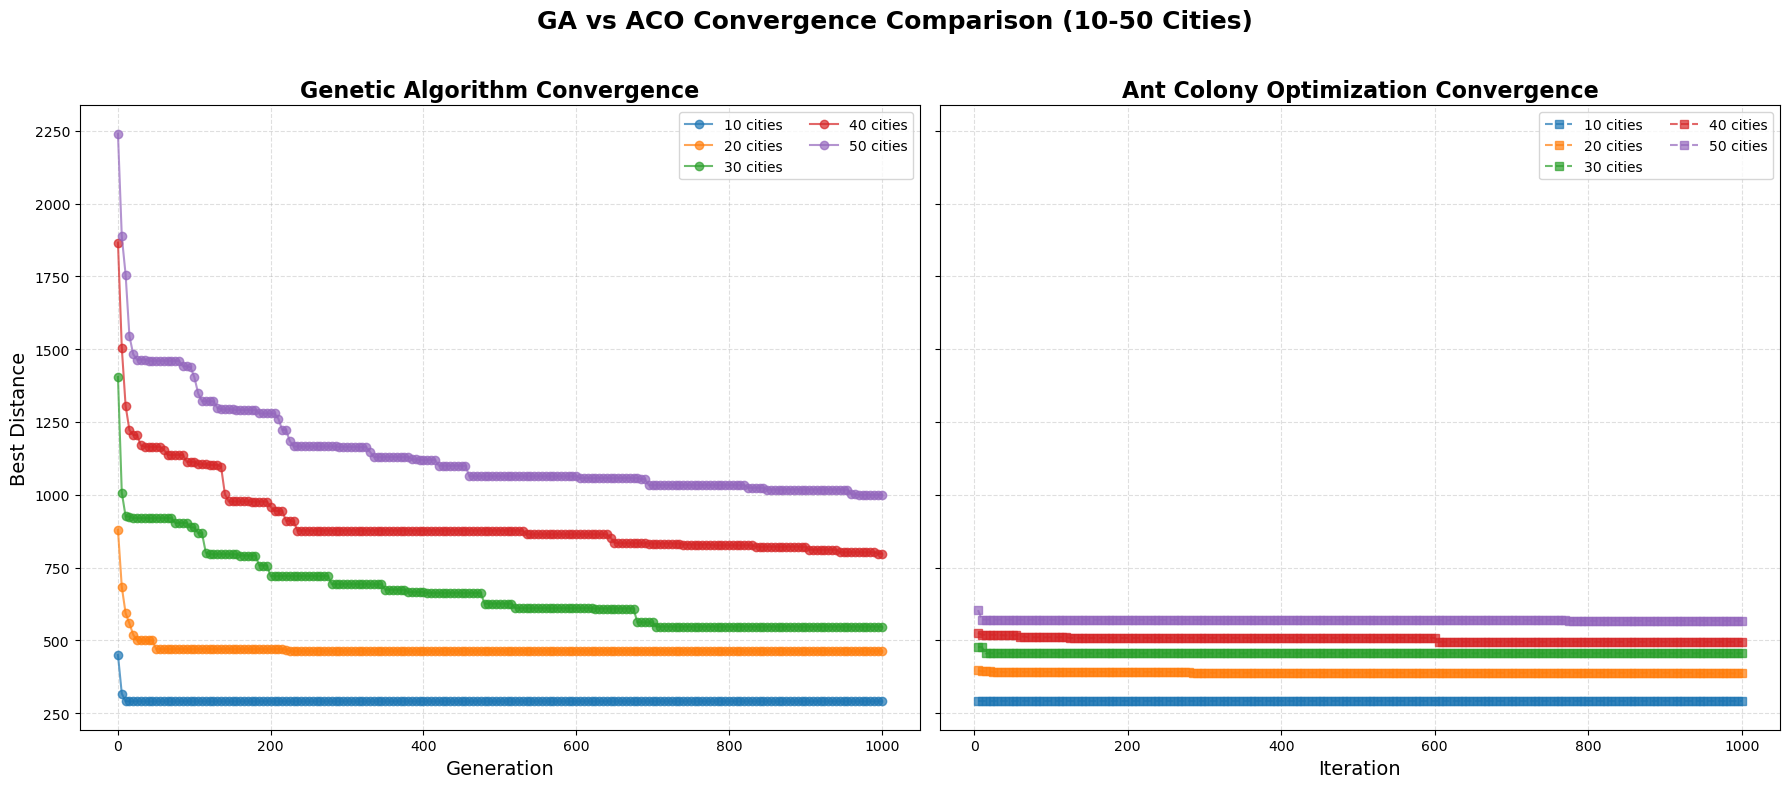

In [58]:
# Generative ai help was taken in this part
city_sizes = [10, 20, 30, 40, 50]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8), sharey=True)

# GA Convergence 
for n in city_sizes:
    ga_hist_file = f'../results/ga_history_{n}cities.csv'
    ga_hist_df = pd.read_csv(ga_hist_file)
    
    ax1.plot(ga_hist_df['iteration'], ga_hist_df['best_distance'],
             marker='o', linestyle='-', label=f'{n} cities', alpha=0.7)

ax1.set_title('Genetic Algorithm Convergence', fontsize=16, fontweight='bold')
ax1.set_xlabel('Generation', fontsize=14)
ax1.set_ylabel('Best Distance', fontsize=14)
ax1.grid(True, linestyle='--', alpha=0.4)
ax1.legend(fontsize=10, ncol=2)

#ACO Convergence
for n in city_sizes:
    aco_hist_file = f'../results/aco_history_{n}cities.csv'
    aco_hist_df = pd.read_csv(aco_hist_file)
    
    ax2.plot(aco_hist_df['iteration'], aco_hist_df['best_distance'],
             marker='s', linestyle='--', label=f'{n} cities', alpha=0.7)

ax2.set_title('Ant Colony Optimization Convergence', fontsize=16, fontweight='bold')
ax2.set_xlabel('Iteration', fontsize=14)
ax2.grid(True, linestyle='--', alpha=0.4)
ax2.legend(fontsize=10, ncol=2)

plt.suptitle('GA vs ACO Convergence Comparison (10-50 Cities)', fontsize=18, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('../results/ga_vs_aco_convergence_10-50_sidebyside.png', dpi=300)
plt.show()

## Winner in Evolutionary Algorithm

Without hyper parameter tuning and with basic parameters these are the facts that are considered 
* ACO’s best‑distance lines are smooth with very small drops later on, indicating stable, incremental improvements.
* GA’s best‑distance lines show many small downward steps over the whole run, which means it keeps making small fixes but never reaches ACO’s quality.
* ACO works directly on edges between cities, reinforcing good edges via pheromone which is natural for TSP and preserves high-quality sub-tours
* Finding the minimum distance is the goal, and ACO performs better than GA

So from this brief analysis we can say in evolution algorithm winner is Ant colony optimization

## Hyperparameter Tuning

| Parameter          | Importance for tuning | Reason                                         |
|-------------------|---------------------|-----------------------------------------------|
| `n_ants`           | High                  | Balances exploration vs computation           |
| `alpha`            | High                  | Controls exploitation of pheromone           |
| `beta`             | High                  | Controls greedy behavior based on distances  |
| `evaporation_rate` | Moderate-High         | Prevents premature convergence               |
| `q`                | Moderate              | Determines strength of pheromone reinforcement |
| `max_iterations`   | Low                   | Mainly for runtime control                   |


We will consider these parameters to hyper tune

## Grid Search

In [41]:
"""
This function performs a full grid search over multiple ACO hyperparameters for different problem sizes, 
evaluating every combination to identify the best-performing settings for each number of cities. 
For each city size, it records only the best hyperparameter configuration and its corresponding shortest tour distance into a CSV file.
"""
def grid_search_aco(
    n_ants_list,
    alpha_list,
    beta_list,
    evaporation_rate_list,
    q_list,
    max_iterations_list,
    num_cities_list,        # List of city counts (e.g., 10,20,30,...)
    csv_filename="aco_tuning_results.csv"
):
    """
    Here we are performing grid search over different hyperparameter combination for ACO. For each number of cities, it runs all combinations of 
    hyperparameters and stores only the best result in a csv file
    """
    # Create CSV with headers
    with open(csv_filename, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow([
            "num_cities",
            "n_ants",
            "alpha",
            "beta",
            "evaporation_rate",
            "q",
            "max_iterations",
            "best_distance"
        ])

        # Loop over different city counts
        for num_cities in num_cities_list:
            print(f"\nRunning Grid Search for {num_cities} Cities")

            cities = cities_based_on_numbers(num_cities)

            best_distance_overall = float("inf")
            best_params_overall = None

            # Generate all hyperparameter combinations
            for n_ants, alpha, beta, evap, q_val, max_iter in product(
                n_ants_list, alpha_list, beta_list, evaporation_rate_list, q_list, max_iterations_list
            ):
                random.seed(seed)
                np.random.seed(seed)

                # Initialize ACO with current hyperparameters
                aco = AntColonyOptimization(
                    cities=cities,
                    n_ants=n_ants,
                    alpha=alpha,
                    beta=beta,
                    evaporation_rate=evap,
                    q=q_val,
                    max_iterations=max_iter
                )

                best_tour, best_distance = aco.solve()

                # Track best for this city size
                if best_distance < best_distance_overall:
                    best_distance_overall = best_distance
                    best_params_overall = {
                        "n_ants": n_ants,
                        "alpha": alpha,
                        "beta": beta,
                        "evaporation_rate": evap,
                        "q": q_val,
                        "max_iterations": max_iter
                    }

            print(f" Best for {num_cities} cities → {best_params_overall} | Dist = {best_distance_overall:.3f}")

            # Save only the best row for this city size
            writer.writerow([
                num_cities,
                best_params_overall["n_ants"],
                best_params_overall["alpha"],
                best_params_overall["beta"],
                best_params_overall["evaporation_rate"],
                best_params_overall["q"],
                best_params_overall["max_iterations"],
                best_distance_overall
            ])
            f.flush()

    print("\nACO Grid Search Complete — results saved in:", csv_filename)

In [60]:
# Define search space
n_ants_list = [10, 20, 30]
alpha_list = [1, 1.5, 2]
beta_list = [3, 4, 5]
evaporation_rate_list = [0.3, 0.5, 0.7]
q_list = [50, 100]
max_iterations_list = [100, 150]

# Select city sizes
num_cities_list = [5,10,15,20,25,30,35,40,45,50]

# Run grid search
grid_search_aco( 
    n_ants_list=n_ants_list,
    alpha_list=alpha_list,
    beta_list=beta_list,
    evaporation_rate_list=evaporation_rate_list,
    q_list=q_list,
    max_iterations_list=max_iterations_list,
    num_cities_list=num_cities_list,
    csv_filename="../results/aco_tuning_results_grid_search.csv"
)



Running Grid Search for 5 Cities
 Best for 5 cities → {'n_ants': 10, 'alpha': 1, 'beta': 3, 'evaporation_rate': 0.3, 'q': 50, 'max_iterations': 100} | Dist = 227.346

Running Grid Search for 10 Cities
 Best for 10 cities → {'n_ants': 10, 'alpha': 1, 'beta': 3, 'evaporation_rate': 0.3, 'q': 50, 'max_iterations': 100} | Dist = 290.307

Running Grid Search for 15 Cities
 Best for 15 cities → {'n_ants': 10, 'alpha': 1, 'beta': 3, 'evaporation_rate': 0.3, 'q': 50, 'max_iterations': 100} | Dist = 320.526

Running Grid Search for 20 Cities
 Best for 20 cities → {'n_ants': 30, 'alpha': 1, 'beta': 3, 'evaporation_rate': 0.3, 'q': 100, 'max_iterations': 100} | Dist = 386.430

Running Grid Search for 25 Cities
 Best for 25 cities → {'n_ants': 30, 'alpha': 1, 'beta': 5, 'evaporation_rate': 0.3, 'q': 100, 'max_iterations': 100} | Dist = 407.308

Running Grid Search for 30 Cities
 Best for 30 cities → {'n_ants': 10, 'alpha': 2, 'beta': 3, 'evaporation_rate': 0.5, 'q': 100, 'max_iterations': 100} | 

## Random Search

In [40]:
# Generative AI help was taken in this part
"""
This function performs random hyperparameter search for ACO by sampling parameter values within defined ranges and evaluating them across multiple TSP sizes. 
For each city count, it keeps only the best-performing parameter combination (lowest tour distance) and saves these optimal results into a CSV file.

"""
def random_search_aco(
    n_samples,
    num_cities_list,
    n_ants_range,
    alpha_range,
    beta_range,
    evaporation_range,
    q_range,
    max_iter_range,
    csv_filename="aco_random_search_results.csv"
):
    """
    Perform random search for ACO hyperparameters.
    Saves ONLY the best hyperparameters per city.
    """

    with open(csv_filename, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow([
            "num_cities",
            "n_ants",
            "alpha",
            "beta",
            "evaporation_rate",
            "q",
            "max_iterations",
            "best_distance"
        ])

        for num_cities in num_cities_list:
            print(f"\nRandom Search for {num_cities} cities...")

            cities = cities_based_on_numbers(num_cities)

            best_distance_overall = float("inf")
            best_params = None

            for _ in range(n_samples):

                # Random sampling of hyperparameters
                params = {
                    "n_ants": random.randint(*n_ants_range),
                    "alpha": random.uniform(*alpha_range),
                    "beta": random.uniform(*beta_range),
                    "evaporation_rate": random.uniform(*evaporation_range),
                    "q": random.randint(*q_range),
                    "max_iterations": random.randint(*max_iter_range)
                }

                # New seed each run (important!)
                random.seed()
                np.random.seed()

                # Running ACO
                aco = AntColonyOptimization(
                    cities=cities,
                    n_ants=params["n_ants"],
                    alpha=params["alpha"],
                    beta=params["beta"],
                    evaporation_rate=params["evaporation_rate"],
                    q=params["q"],
                    max_iterations=params["max_iterations"]
                )

                best_tour, best_distance = aco.solve()

                # Track best result
                if best_distance < best_distance_overall:
                    best_distance_overall = best_distance
                    best_params = params.copy()

            print(f" Best Params for {num_cities}: {best_params}  | Dist = {best_distance_overall:.3f}")

            # Save only BEST row
            writer.writerow([
                num_cities,
                best_params["n_ants"],
                best_params["alpha"],
                best_params["beta"],
                best_params["evaporation_rate"],
                best_params["q"],
                best_params["max_iterations"],
                best_distance_overall
            ])
            f.flush()

    print("\nRandom Search Completed — Best results saved to:", csv_filename)


In [62]:
n_samples = 20   # number of random samplings per city size
num_cities_list = [5,10,15,20,25,30,35,40,45,50]

n_ants_range = (10, 50)              # integer
alpha_range = (1.0, 3.0)             # float
beta_range = (2.0, 6.0)              # float
evaporation_range = (0.1, 0.8)       # float
q_range = (20, 150)                  # integer
max_iter_range = (50, 200)           # integer


In [63]:
random_search_aco(
    n_samples=n_samples,
    num_cities_list=num_cities_list,
    n_ants_range=n_ants_range,
    alpha_range=alpha_range,
    beta_range=beta_range,
    evaporation_range=evaporation_range,
    q_range=q_range,
    max_iter_range=max_iter_range,
    csv_filename="../results/aco_random_search_results.csv"
)



Random Search for 5 cities...
 Best Params for 5: {'n_ants': 19, 'alpha': 1.0692988874630118, 'beta': 4.476706195383583, 'evaporation_rate': 0.2720493454716718, 'q': 95, 'max_iterations': 177}  | Dist = 227.346

Random Search for 10 cities...
 Best Params for 10: {'n_ants': 12, 'alpha': 2.393034257827269, 'beta': 5.138666456741171, 'evaporation_rate': 0.671130184631103, 'q': 30, 'max_iterations': 172}  | Dist = 290.307

Random Search for 15 cities...
 Best Params for 15: {'n_ants': 43, 'alpha': 1.647529681708751, 'beta': 3.226275522823206, 'evaporation_rate': 0.44713471607094735, 'q': 98, 'max_iterations': 112}  | Dist = 320.526

Random Search for 20 cities...
 Best Params for 20: {'n_ants': 27, 'alpha': 1.7570193677965398, 'beta': 5.413188719298994, 'evaporation_rate': 0.2670361538750611, 'q': 89, 'max_iterations': 55}  | Dist = 388.198

Random Search for 25 cities...
 Best Params for 25: {'n_ants': 21, 'alpha': 1.2419943728590266, 'beta': 2.3499405440428474, 'evaporation_rate': 0.63

## Comparison Between Grid search and Random search

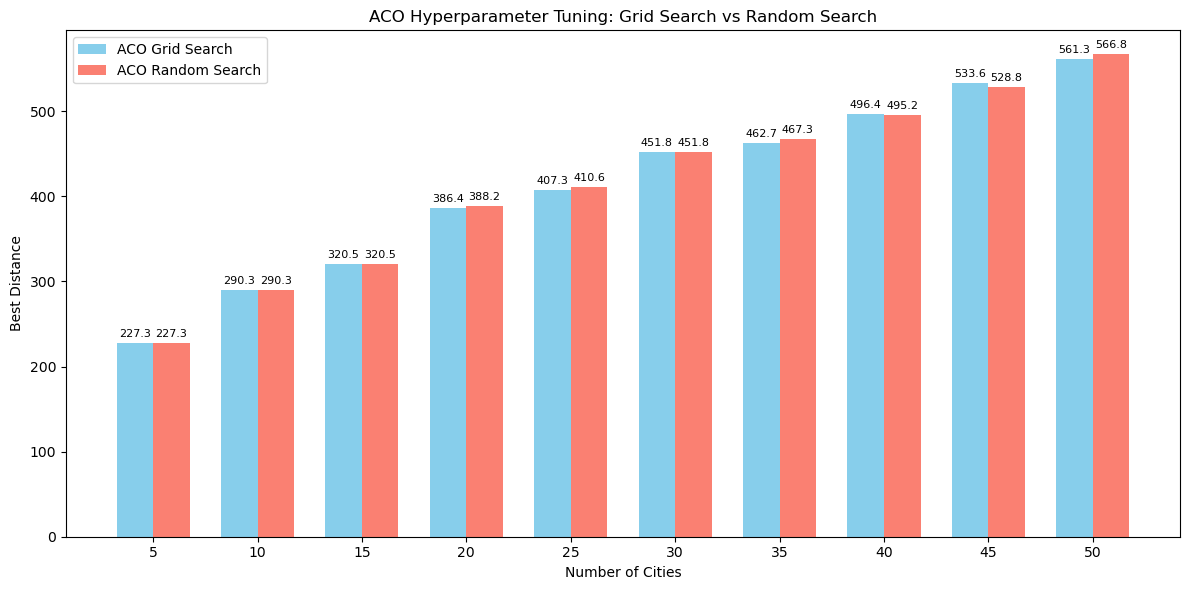

In [58]:
"""
Comparing distance between the best hyper tuned parameters
"""
grid_df = pd.read_csv("../results/aco_tuning_results_grid_search.csv")
random_df = pd.read_csv("../results/aco_random_search_results.csv")

# Sort by number of cities
grid_df = grid_df.sort_values("num_cities")
random_df = random_df.sort_values("num_cities")

num_cities = grid_df["num_cities"]
grid_distances = grid_df["best_distance"]
random_distances = random_df["best_distance"]

# Set bar positions
x = np.arange(len(num_cities))
width = 0.35

fig, ax = plt.subplots(figsize=(12,6))

bars1 = ax.bar(x - width/2, grid_distances, width, label='ACO Grid Search', color='skyblue')
bars2 = ax.bar(x + width/2, random_distances, width, label='ACO Random Search', color='salmon')

ax.set_xlabel("Number of Cities")
ax.set_ylabel("Best Distance")
ax.set_title("ACO Hyperparameter Tuning: Grid Search vs Random Search")
ax.set_xticks(x)
ax.set_xticklabels(num_cities)
ax.legend()

# Labeling function
def autolabel(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.1f}',
                    xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0,3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=8)

autolabel(bars1)
autolabel(bars2)

plt.tight_layout()
plt.show()

## Fusing the best hyper parameters 

In [6]:
grid_df = pd.read_csv("../results/aco_tuning_results_grid_search.csv")
random_df = pd.read_csv("../results/aco_random_search_results.csv")

# Combine both
combined_df = pd.concat([grid_df, random_df], ignore_index=True)

# Keep the row with minimum best_distance for each num_cities
best_df = combined_df.loc[combined_df.groupby("num_cities")["best_distance"].idxmin()]

# Optional: sort by number of cities
best_df = best_df.sort_values("num_cities").reset_index(drop=True)

# Save fused results
best_df.to_csv("../results/aco_tuning_best_fused.csv", index=False)

print("Fused best hyperparameters saved to 'aco_tuning_best_fused.csv'")
best_df

Fused best hyperparameters saved to 'aco_tuning_best_fused.csv'


,num_cities,n_ants,alpha,beta,evaporation_rate,q,max_iterations,best_distance
0,5,10,1.000000,3.000000,0.300000,50,100,227.345519
1,10,10,1.000000,3.000000,0.300000,50,100,290.306774
2,15,10,1.000000,3.000000,0.300000,50,100,320.525666
3,20,30,1.000000,3.000000,0.300000,100,100,386.429689
4,25,30,1.000000,5.000000,0.300000,100,100,407.307567
5,30,10,2.000000,3.000000,0.500000,100,100,451.767001
6,35,20,1.000000,3.000000,0.700000,100,150,462.659365
7,40,41,2.834905,3.376302,0.271961,105,197,495.152981
8,45,34,1.393493,2.610820,0.286398,148,73,528.807161
9,50,30,1.000000,4.000000,0.300000,50,100,561.336476


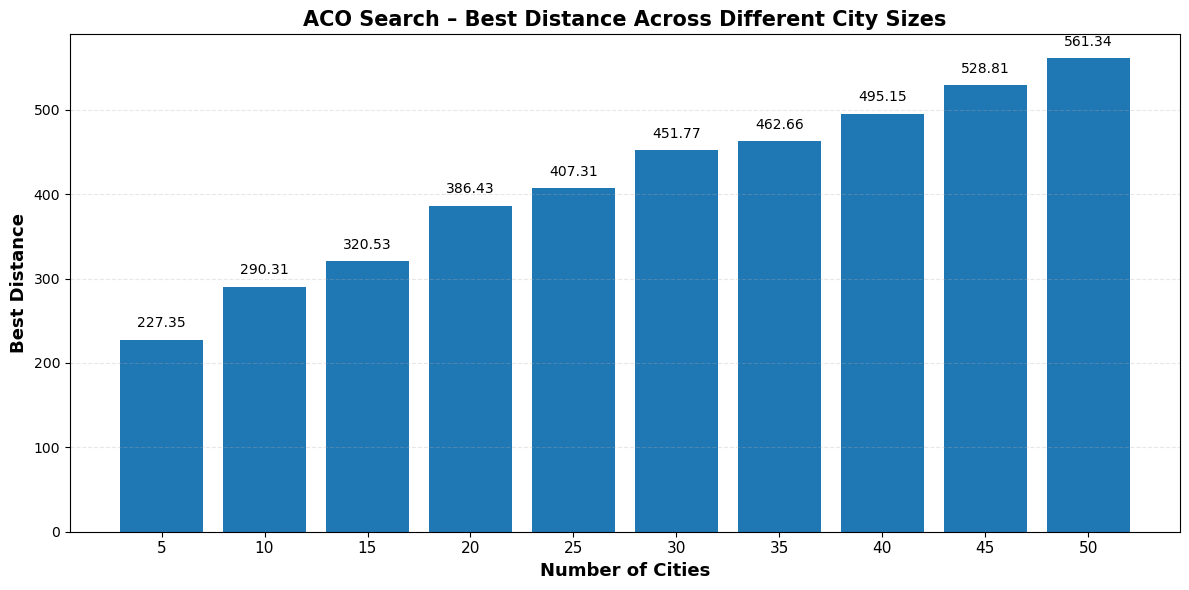

In [9]:
# Load best hyperparameters file
best_df = pd.read_csv("../results/aco_tuning_best_fused.csv")

plt.figure(figsize=(12, 6))

# X positions and bar values
x = np.arange(len(best_df["num_cities"]))
distances = best_df["best_distance"]

bars = plt.bar(x, distances)

# Labels
plt.xlabel("Number of Cities", fontsize=13, fontweight="bold")
plt.ylabel("Best Distance", fontsize=13, fontweight="bold")
plt.title("ACO Search – Best Distance Across Different City Sizes", fontsize=15, fontweight="bold")

# X-axis ticks
plt.xticks(x, best_df["num_cities"], fontsize=11)

# Adding numbers above the bars (clean spacing)
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + (0.02 * distances.max()),   # slight offset to avoid overlap
        f"{height:.2f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

# Optional grid
plt.grid(axis="y", alpha=0.3, linestyle="--")

plt.tight_layout()
plt.show()

# Part 4 : Analysis Between Tabu Search and Ant Colony Optimization

In this part we will run each algorithm multiple times using different seeds. Our goal is to run 20 times each time different seeds. The seed will change in every loop. We will also save the result then from that we will do further analysis

In [66]:
# Loading hyper parameters
tabu_hyperparameters = pd.read_csv ('../results/tabu_best_hyperparameters.csv')
aco_hyperparameters = pd.read_csv ('../results/aco_tuning_best_fused.csv')
# Loading number of city list and also seeds
city_sizes = list(range(5, 55, 5))
seeds = list(range(1, 21)) 
        

## Running loop on Tabu Search for different seeds and the hyperparameters

In [67]:
# Output for tabu search 
output_file = "../results/final_tabu_results.csv"
with open(output_file, "w", newline="") as f:
    writer = csv.writer(f)
    # Write the header row
    writer.writerow(["seed", "n_cities", "best_distance", "time_sec"])

    # Loop over different city sizes
    for city in city_sizes:
        # Getting city coordinate for this city count
        coords = cities_based_on_numbers(city)
        # Select the hyperparameter row for this city size
        hp_row = tabu_hyperparameters[tabu_hyperparameters['num_cities'] == city].iloc[0]
        # Extracting hyper parameters for this city size
        tabu_size = int(hp_row['tabu_size'])
        max_iterations = int(hp_row['max_iterations'])
        # Handling where neighborhood size is NAN
        neighborhood_sample_size = None if np.isnan(hp_row['neighborhood_size']) else int(hp_row['neighborhood_size'])
        stall_limit = int(hp_row['stall_limit'])

        # List to store best distance for multiple seeds 
        distances = []

        # Running tabu for different random seeds
        for seed in seeds:
            np.random.seed(seed)
            import random
            random.seed(seed)
            import time
            start_time = time.time()

            # Initialize tabu search with selected hyper parameters
            ts = TabuSearch(
                cities=coords,
                tabu_size=tabu_size,
                max_iterations=max_iterations,
                neighborhood_sample_size=neighborhood_sample_size,
                stall_limit=stall_limit
            )

            # Solve TSP with Tabu search
            best_tour, best_distance = ts.solve()
            elapsed = time.time() - start_time

            writer.writerow([seed, city, best_distance, elapsed])
            f.flush()
            distances.append(best_distance)
            #print(f"City {city}, Seed {seed} -> Best Distance: {best_distance:.3f}, Time: {elapsed:.2f}s")
        mean_distance = np.mean(distances)
        print(f"City {city} completed. Mean Best Distance over {len(seeds)} runs: {mean_distance:.3f}")    

City 5 completed. Mean Best Distance over 20 runs: 227.346
City 10 completed. Mean Best Distance over 20 runs: 290.307
City 15 completed. Mean Best Distance over 20 runs: 324.163
City 20 completed. Mean Best Distance over 20 runs: 395.288
City 25 completed. Mean Best Distance over 20 runs: 454.871
City 30 completed. Mean Best Distance over 20 runs: 521.332
City 35 completed. Mean Best Distance over 20 runs: 583.762
City 40 completed. Mean Best Distance over 20 runs: 614.606
City 45 completed. Mean Best Distance over 20 runs: 700.369
City 50 completed. Mean Best Distance over 20 runs: 731.392


## Running loop on Ant Colony Optimization based for different seeds and hyper parameters

In [68]:
# Output file for saving ACO results
output_file = "../results/final_aco_results.csv"
with open(output_file, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["seed", "n_cities", "best_distance", "time_sec"])

    # Loop over different city sizes
    for city in city_sizes:
        coords = cities_based_on_numbers(city)
        # Get the hyperparameter row for this city
        hp_row = aco_hyperparameters[aco_hyperparameters['num_cities'] == city].iloc[0]

        # Extracting hyperparameter values
        n_ants = int(hp_row['n_ants']) # Number of ants
        alpha = float(hp_row['alpha']) # Pheromone influence
        beta = float(hp_row['beta']) # Heuristic influence
        evaporation_rate = float(hp_row['evaporation_rate']) # Pheromone evaporation rate
        q = int(hp_row['q']) # Pheromone deposit factor
        max_iterations = int(hp_row['max_iterations']) # Max number of iterations

        distances = []

        # Running ACO for different random seeds
        for seed in seeds:
            # Setting random seeds for reproducibility
            np.random.seed(seed)
            random.seed(seed)

            start_time = time.time() # Starting timer
            # Initializing ACO with chosen hyper parameters
            aco = AntColonyOptimization(
                cities=coords,
                n_ants=n_ants,
                alpha=alpha,
                beta=beta,
                evaporation_rate=evaporation_rate,
                q=q,
                max_iterations=max_iterations
            )
            # Solving TSP using ACO
            best_tour, best_distance = aco.solve()
            elapsed_time = time.time() - start_time
            # Writing results of this to run CSV
            writer.writerow([seed, city, best_distance, elapsed_time])
            f.flush()
            # Storing distance for averaging later
            distances.append(best_distance)

        mean_distance = np.mean(distances)
        print(f"City {city} completed. Mean Best Distance over {len(seeds)} runs: {mean_distance:.3f}")

City 5 completed. Mean Best Distance over 20 runs: 227.346
City 10 completed. Mean Best Distance over 20 runs: 290.307
City 15 completed. Mean Best Distance over 20 runs: 320.526
City 20 completed. Mean Best Distance over 20 runs: 387.132
City 25 completed. Mean Best Distance over 20 runs: 416.151
City 30 completed. Mean Best Distance over 20 runs: 493.986
City 35 completed. Mean Best Distance over 20 runs: 468.683
City 40 completed. Mean Best Distance over 20 runs: 519.539
City 45 completed. Mean Best Distance over 20 runs: 544.110
City 50 completed. Mean Best Distance over 20 runs: 568.200


## Statistical Analysis

In [69]:
tabu_df = pd.read_csv("../results/final_tabu_results.csv")
aco_df = pd.read_csv("../results/final_aco_results.csv")

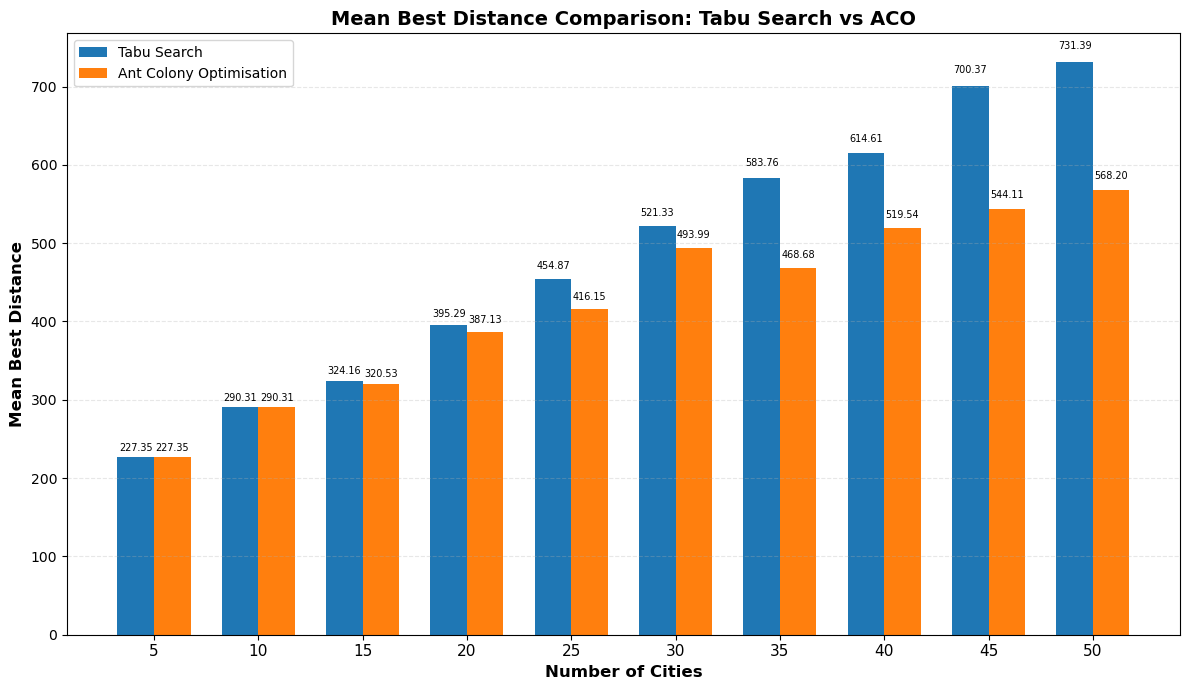

In [82]:
# Load data
tabu_df = pd.read_csv("../results/final_tabu_results.csv")
aco_df = pd.read_csv("../results/final_aco_results.csv")

# Compute mean distances
tabu_mean = tabu_df.groupby('n_cities')['best_distance'].mean().reset_index()
aco_mean = aco_df.groupby('n_cities')['best_distance'].mean().reset_index()

# Merge aligned
merged = tabu_mean.merge(aco_mean, on='n_cities', suffixes=('_tabu', '_aco'))

x = np.arange(len(merged['n_cities']))
width = 0.35

# Larger figure height prevents overlap
fig, ax = plt.subplots(figsize=(12, 7))

bars1 = ax.bar(x - width/2, merged['best_distance_tabu'], width, label='Tabu Search')
bars2 = ax.bar(x + width/2, merged['best_distance_aco'], width, label='Ant Colony Optimisation')

ax.set_xlabel("Number of Cities", fontsize=12, fontweight='bold')
ax.set_ylabel("Mean Best Distance", fontsize=12, fontweight='bold')
ax.set_title("Mean Best Distance Comparison: Tabu Search vs ACO", fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(merged['n_cities'], fontsize=11)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.legend()

# Add non-overlapping labels
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            height + (height * 0.02),   # extra offset (2%)
            f'{height:.2f}',
            ha='center',
            va='bottom',
            fontsize=7,
            rotation=0           # Change to 45 if still overlapping
        )

add_labels(bars1)
add_labels(bars2)

plt.tight_layout()
plt.show()

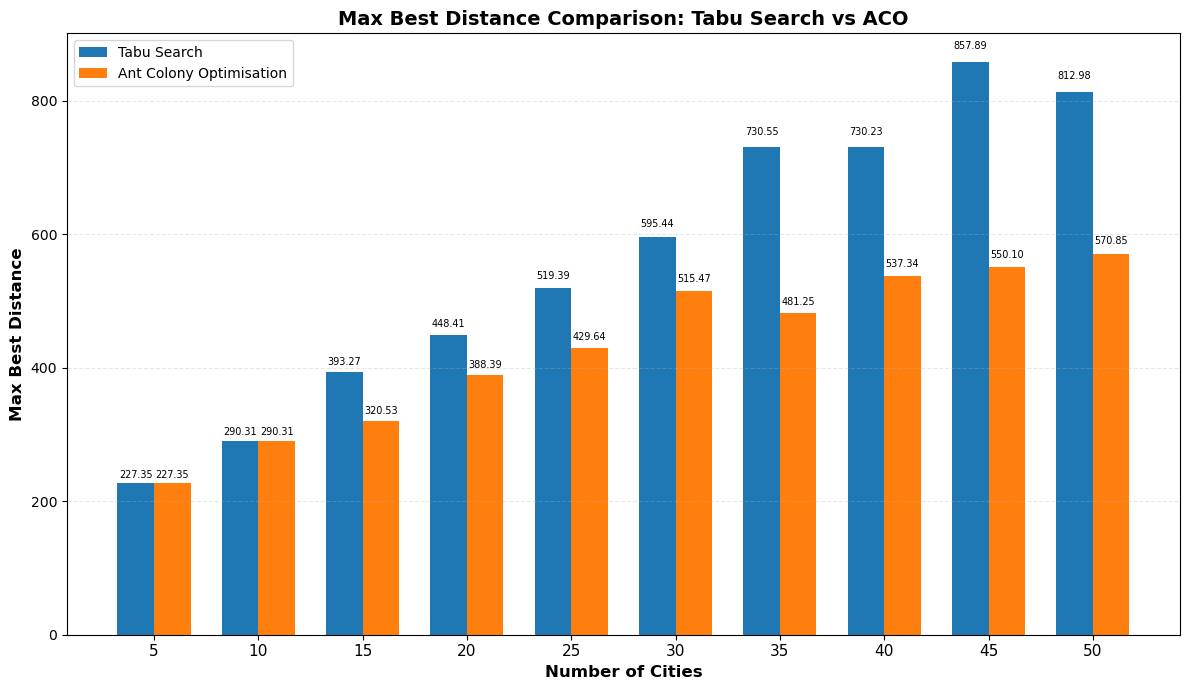

In [11]:
# Load data
tabu_df = pd.read_csv("../results/final_tabu_results.csv")
aco_df = pd.read_csv("../results/final_aco_results.csv")

# Get max distances
tabu_max = tabu_df.groupby('n_cities')['best_distance'].max().reset_index()
aco_max = aco_df.groupby('n_cities')['best_distance'].max().reset_index()

# Merge aligned
merged = tabu_max.merge(aco_max, on='n_cities', suffixes=('_tabu', '_aco'))

x = np.arange(len(merged['n_cities']))
width = 0.35

# Larger figure height prevents overlap
fig, ax = plt.subplots(figsize=(12, 7))

bars1 = ax.bar(x - width/2, merged['best_distance_tabu'], width, label='Tabu Search')
bars2 = ax.bar(x + width/2, merged['best_distance_aco'], width, label='Ant Colony Optimisation')

ax.set_xlabel("Number of Cities", fontsize=12, fontweight='bold')
ax.set_ylabel("Max Best Distance", fontsize=12, fontweight='bold')
ax.set_title("Max Best Distance Comparison: Tabu Search vs ACO", fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(merged['n_cities'], fontsize=11)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.legend()

# Add non-overlapping labels
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            height + (height * 0.02),   # extra offset (2%)
            f'{height:.2f}',
            ha='center',
            va='bottom',
            fontsize=7,
            rotation=0           # Change to 45 if still overlapping
        )

add_labels(bars1)
add_labels(bars2)

plt.tight_layout()
plt.show()

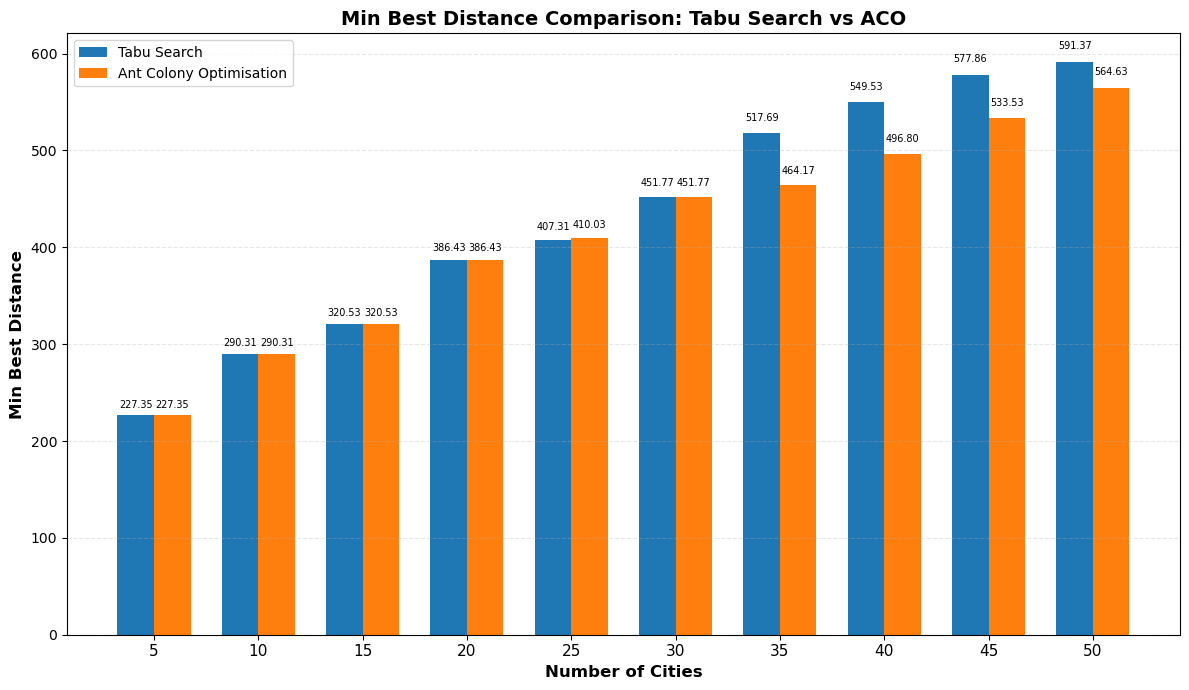

In [12]:
# Load data
tabu_df = pd.read_csv("../results/final_tabu_results.csv")
aco_df = pd.read_csv("../results/final_aco_results.csv")

# Get min distances
tabu_min = tabu_df.groupby('n_cities')['best_distance'].min().reset_index()
aco_min = aco_df.groupby('n_cities')['best_distance'].min().reset_index()

# Merge aligned
merged = tabu_min.merge(aco_min, on='n_cities', suffixes=('_tabu', '_aco'))

x = np.arange(len(merged['n_cities']))
width = 0.35

# Larger figure height prevents overlap
fig, ax = plt.subplots(figsize=(12, 7))

bars1 = ax.bar(x - width/2, merged['best_distance_tabu'], width, label='Tabu Search')
bars2 = ax.bar(x + width/2, merged['best_distance_aco'], width, label='Ant Colony Optimisation')

ax.set_xlabel("Number of Cities", fontsize=12, fontweight='bold')
ax.set_ylabel("Min Best Distance", fontsize=12, fontweight='bold')
ax.set_title("Min Best Distance Comparison: Tabu Search vs ACO", fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(merged['n_cities'], fontsize=11)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.legend()

# Add non-overlapping labels
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            height + (height * 0.02),   # extra offset (2%)
            f'{height:.2f}',
            ha='center',
            va='bottom',
            fontsize=7,
            rotation=0           
        )

add_labels(bars1)
add_labels(bars2)

plt.tight_layout()
plt.show()

In [14]:
# We will compute stats in here where we will find mean , standard daviation , min and max
def compute_stats(df, algo_name):
    stats = df.groupby('n_cities')['best_distance'].agg(
        mean_distance='mean',
        std_distance='std',
        best_distance='min',
        worst_distance='max'
    ).reset_index()
    stats['algorithm'] = algo_name
    return stats

tabu_stats = compute_stats(tabu_df, "Tabu Search")
aco_stats = compute_stats(aco_df, "Ant Colony")


In [15]:
tabu_stats

,n_cities,mean_distance,std_distance,best_distance,worst_distance,algorithm
0,5,227.345519,0.000000,227.345519,227.345519,Tabu Search
1,10,290.306774,0.000000,290.306774,290.306774,Tabu Search
2,15,324.162705,16.265332,320.525666,393.266444,Tabu Search
3,20,395.287903,21.544503,386.429689,448.407474,Tabu Search
4,25,454.870749,37.140961,407.307567,519.385425,Tabu Search
5,30,521.331905,34.908660,451.767001,595.441825,Tabu Search
6,35,583.761528,50.031948,517.690990,730.545455,Tabu Search
7,40,614.605700,43.908279,549.525006,730.233462,Tabu Search
8,45,700.368955,72.998595,577.857109,857.891319,Tabu Search
9,50,731.392372,61.074913,591.368361,812.983748,Tabu Search


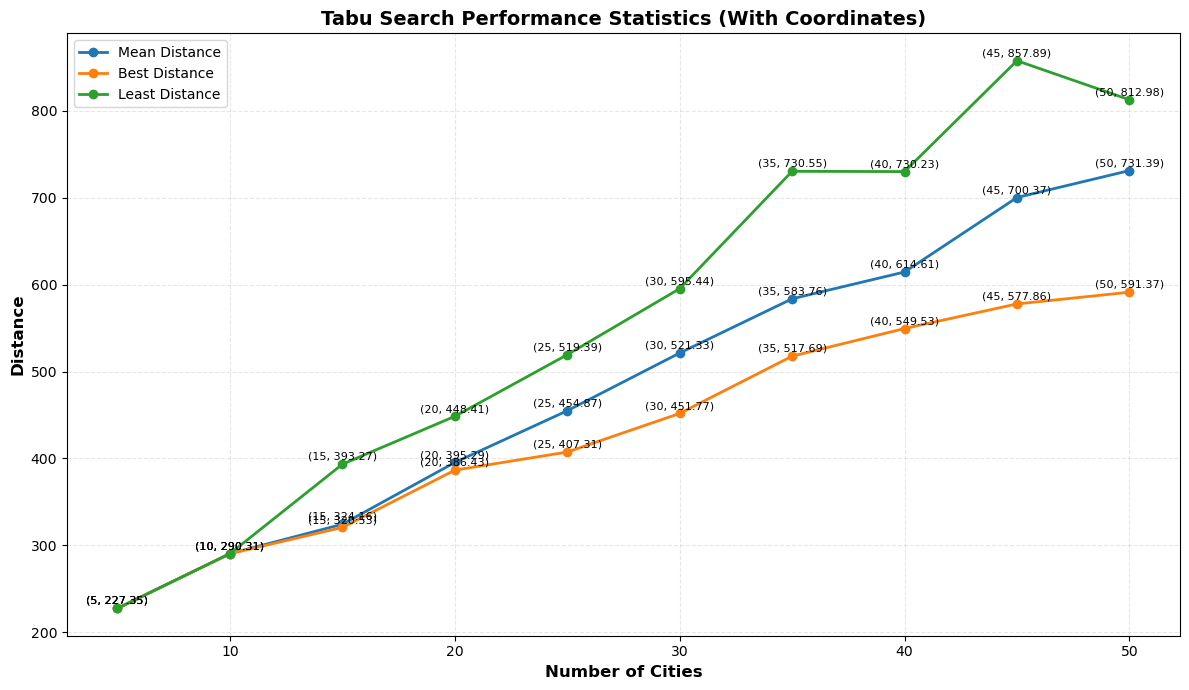

In [45]:
x = tabu_stats['n_cities']
mean_y = tabu_stats['mean_distance']
best_y = tabu_stats['best_distance']
worst_y = tabu_stats['worst_distance']

plt.figure(figsize=(12, 7))

# Plot curves
plt.plot(x, mean_y, marker='o', label='Mean Distance', linewidth=2)
plt.plot(x, best_y, marker='o', label='Best Distance', linewidth=2)
plt.plot(x, worst_y, marker='o', label='Least Distance', linewidth=2)

# Add coordinate labels
def add_labels(x, y):
    for i in range(len(x)):
        plt.text(
            x[i], 
            y[i] + 5,                     # small offset upward
            f"({x[i]}, {y[i]:.2f})",
            ha='center',
            fontsize=8
        )

add_labels(x, mean_y)
add_labels(x, best_y)
add_labels(x, worst_y)

plt.xlabel("Number of Cities", fontsize=12, fontweight='bold')
plt.ylabel("Distance", fontsize=12, fontweight='bold')
plt.title("Tabu Search Performance Statistics (With Coordinates)", fontsize=14, fontweight='bold')

plt.grid(alpha=0.3, linestyle="--")
plt.legend()
plt.tight_layout()
plt.show()

In [16]:
aco_stats

,n_cities,mean_distance,std_distance,best_distance,worst_distance,algorithm
0,5,227.345519,0.000000e+00,227.345519,227.345519,Ant Colony
1,10,290.306774,0.000000e+00,290.306774,290.306774,Ant Colony
2,15,320.525666,2.608155e-14,320.525666,320.525666,Ant Colony
3,20,387.131665,8.611390e-01,386.429689,388.394746,Ant Colony
4,25,416.150799,7.344339e+00,410.032202,429.638853,Ant Colony
5,30,493.986108,1.539174e+01,451.767001,515.470478,Ant Colony
6,35,468.682871,4.142892e+00,464.168284,481.246471,Ant Colony
7,40,519.538790,1.189858e+01,496.797594,537.344931,Ant Colony
8,45,544.110073,4.173054e+00,533.528290,550.100994,Ant Colony
9,50,568.200076,1.689690e+00,564.626075,570.850387,Ant Colony


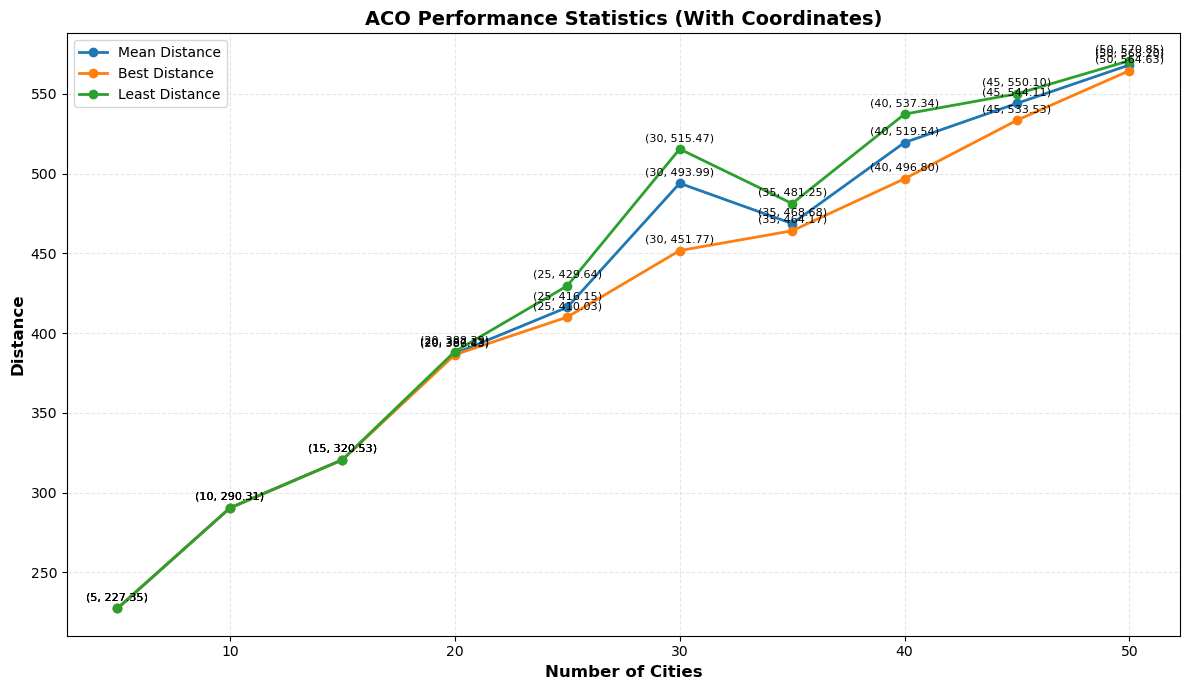

In [44]:
# Extracting x axis and y axis values
x = aco_stats['n_cities']
mean_y = aco_stats['mean_distance']
best_y = aco_stats['best_distance']
worst_y = aco_stats['worst_distance']

# Creating the figure with a fixed size
plt.figure(figsize=(12, 7))

# Plot curves (mean, best and worst distance)
plt.plot(x, mean_y, marker='o', label='Mean Distance', linewidth=2)
plt.plot(x, best_y, marker='o', label='Best Distance', linewidth=2)
plt.plot(x, worst_y, marker='o', label='Least Distance', linewidth=2)

# Add coordinate labels
def add_labels(x, y):
    for i in range(len(x)):
        plt.text(
            x[i], 
            y[i] + 5,                     # small offset upward
            f"({x[i]}, {y[i]:.2f})",
            ha='center',
            fontsize=8
        )

# Adding labels
add_labels(x, mean_y)
add_labels(x, best_y)
add_labels(x, worst_y)

plt.xlabel("Number of Cities", fontsize=12, fontweight='bold')
plt.ylabel("Distance", fontsize=12, fontweight='bold')
plt.title("ACO Performance Statistics (With Coordinates)", fontsize=14, fontweight='bold')

# Grid for readability
plt.grid(alpha=0.3, linestyle="--")
plt.legend()
plt.tight_layout()
# Displaying the plot
plt.show()

In [71]:
stats_df = pd.concat([tabu_stats, aco_stats], ignore_index=True)
stats_df

,n_cities,mean_distance,std_distance,best_distance,worst_distance,algorithm
0,5,227.345519,0.000000e+00,227.345519,227.345519,Tabu Search
1,10,290.306774,0.000000e+00,290.306774,290.306774,Tabu Search
2,15,324.162705,1.626533e+01,320.525666,393.266444,Tabu Search
3,20,395.287903,2.154450e+01,386.429689,448.407474,Tabu Search
4,25,454.870749,3.714096e+01,407.307567,519.385425,Tabu Search
5,30,521.331905,3.490866e+01,451.767001,595.441825,Tabu Search
6,35,583.761528,5.003195e+01,517.690990,730.545455,Tabu Search
7,40,614.605700,4.390828e+01,549.525006,730.233462,Tabu Search
8,45,700.368955,7.299860e+01,577.857109,857.891319,Tabu Search
9,50,731.392372,6.107491e+01,591.368361,812.983748,Tabu Search


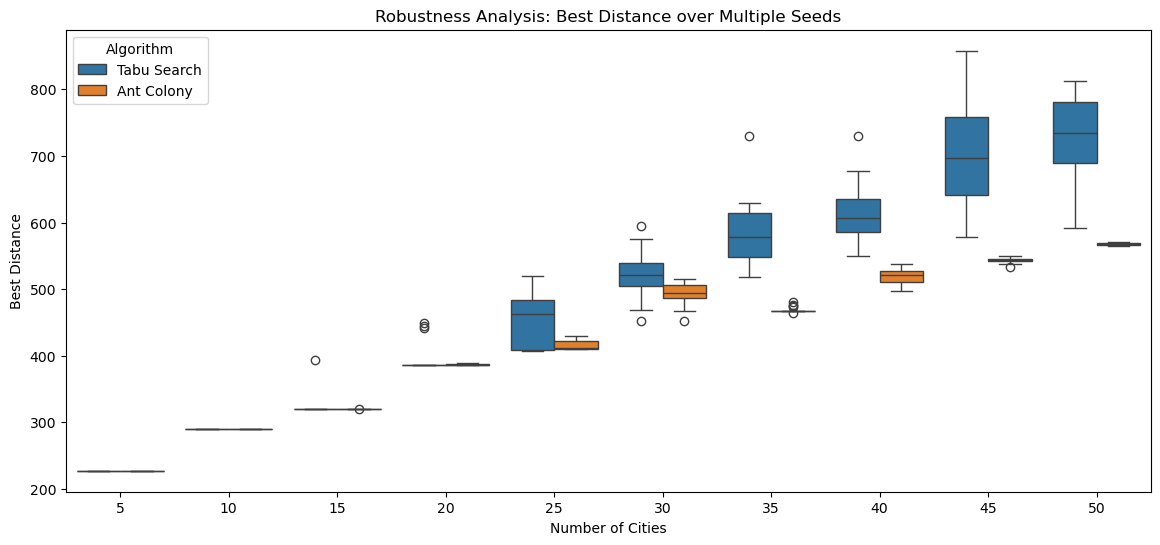

In [73]:
# Concating the dataframe from tabu search and ACO to get a combined result
combined_df = pd.concat([tabu_df.assign(algorithm='Tabu Search'),aco_df.assign(algorithm='Ant Colony')])

plt.figure(figsize=(14,6))
sns.boxplot(x='n_cities', y='best_distance', hue='algorithm', data=combined_df)
plt.xlabel("Number of Cities")
plt.ylabel("Best Distance")
plt.title("Robustness Analysis: Best Distance over Multiple Seeds")
plt.legend(title='Algorithm')
plt.show()

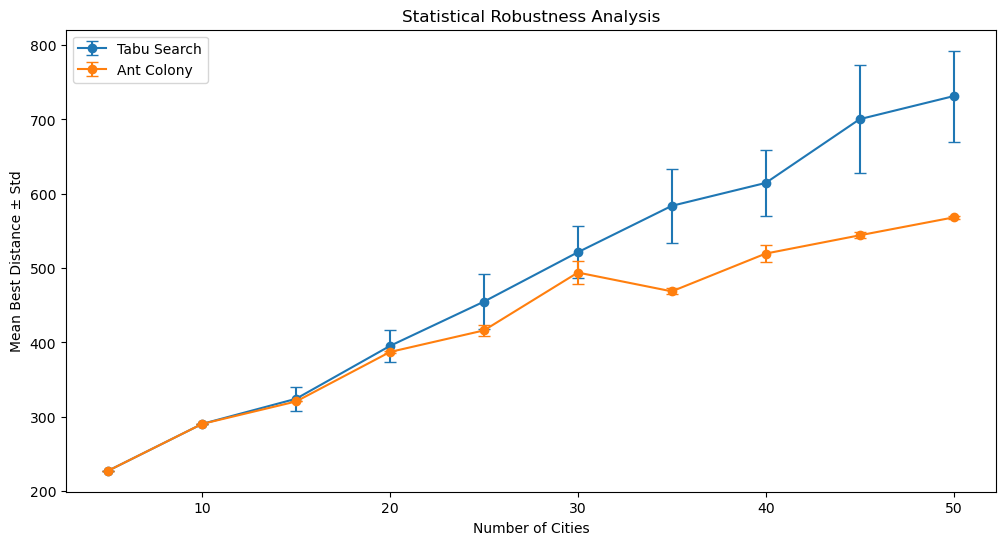

In [74]:
plt.figure(figsize=(12,6))
for algo, df in [('Tabu Search', tabu_stats), ('Ant Colony', aco_stats)]:
    plt.errorbar(df['n_cities'], df['mean_distance'], yerr=df['std_distance'], label=algo, marker='o', capsize=4)

plt.xlabel("Number of Cities")
plt.ylabel("Mean Best Distance ± Std")
plt.title("Statistical Robustness Analysis")
plt.legend()
plt.show()


## Paired t test

In [48]:
# Generative AI help was taken in this part
# Merging tabu and ACO results on seed + number of cities
merged_df = pd.merge(
    tabu_df, aco_df,
    on=['seed', 'n_cities'],
    suffixes=('_tabu', '_aco')
)
results = [] # Storing statistical test results

# Iterating over each unique city count
for city in sorted(merged_df['n_cities'].unique()):
    # Extracting rows for this specific number of cities
    subset = merged_df[merged_df['n_cities'] == city]
    # Performing paired t test
    t_stat, p_val = ttest_rel(subset['best_distance_tabu'], subset['best_distance_aco'])
    # Computing mean performance for reporting
    mean_tabu = subset['best_distance_tabu'].mean()
    mean_aco = subset['best_distance_aco'].mean()
    # Storing the computed statistics
    results.append({
        'n_cities': city,
        'mean_distance_tabu': mean_tabu,
        'mean_distance_aco': mean_aco,
        't_statistic': t_stat,
        'p_value': p_val
    })
# Converting all results into a dataframe
ttest_df = pd.DataFrame(results)
ttest_df


,n_cities,mean_distance_tabu,mean_distance_aco,t_statistic,p_value
0,5,227.345519,227.345519,NaN,NaN
1,10,290.306774,290.306774,NaN,NaN
2,15,324.162705,320.525666,1.000000,3.298768e-01
3,20,395.287903,387.131665,1.709170,1.037032e-01
4,25,454.870749,416.150799,4.564782,2.116903e-04
5,30,521.331905,493.986108,3.387732,3.088987e-03
6,35,583.761528,468.682871,10.204974,3.791897e-09
7,40,614.605700,519.538790,9.729234,8.174596e-09
8,45,700.368955,544.110073,9.449987,1.298787e-08
9,50,731.392372,568.200076,12.022726,2.509393e-10


Now from all analysis we find that ACO shows the least distance. Now we will plot the cities covered with the least distance from 5 cities to 50 cities

In [47]:
"""
Getting the seeds which brings least distance
"""
df = pd.read_csv("../results/final_aco_results.csv")

# Dictionary to store results
best_seeds = []

# Loop over each unique n_cities value 
for city in sorted(df["n_cities"].unique()):
    # Filter rows where number of cities = current city count
    subset = df[df["n_cities"] == city]

    # Find the row with the minimum (best) distance
    best_row = subset.loc[subset["best_distance"].idxmin()]

    # Store the result
    best_seeds.append({
        "n_cities": city,
        "best_seed": best_row["seed"],
        "best_distance": best_row["best_distance"],
        "time_sec": best_row["time_sec"]
    })

# Convert results into a new DataFrame
best_df_for_seeds = pd.DataFrame(best_seeds)

best_df_for_seeds

,n_cities,best_seed,best_distance,time_sec
0,5,1.0,227.345519,0.124311
1,10,1.0,290.306774,0.242160
2,15,16.0,320.525666,0.376266
3,20,6.0,386.429689,1.619635
4,25,5.0,410.032202,2.154515
5,30,12.0,451.767001,0.986858
6,35,7.0,464.168284,3.700271
7,40,6.0,496.797594,11.420089
8,45,2.0,533.528290,4.253119
9,50,17.0,564.626075,6.501369


Plotting best tour for 5 cities (Distance: 227.346)


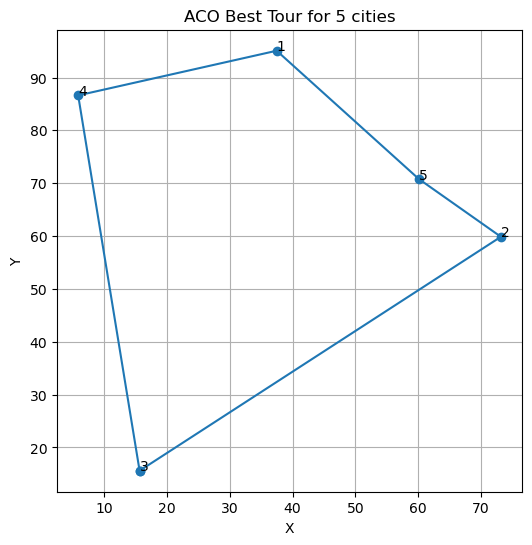

Plotting best tour for 10 cities (Distance: 290.307)


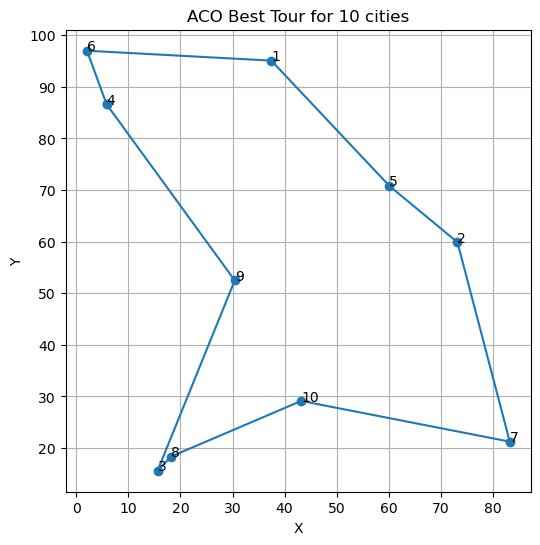

Plotting best tour for 15 cities (Distance: 320.526)


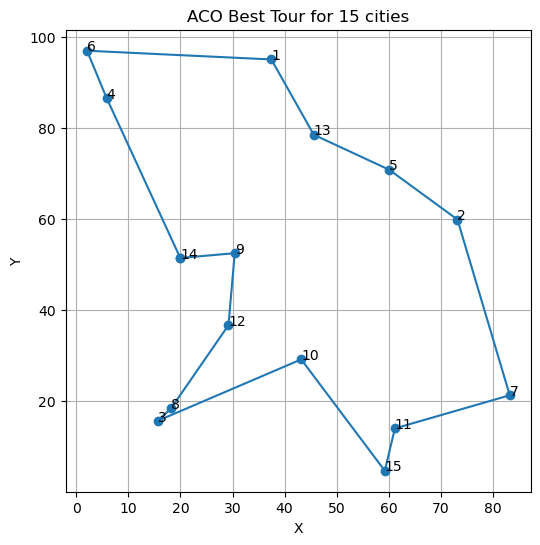

Plotting best tour for 20 cities (Distance: 386.430)


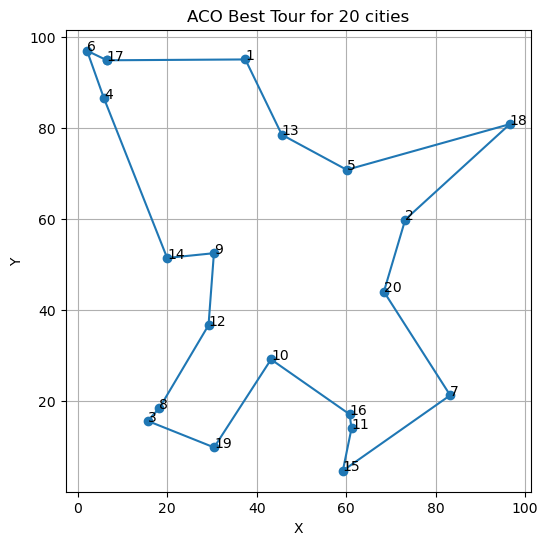

Plotting best tour for 25 cities (Distance: 410.032)


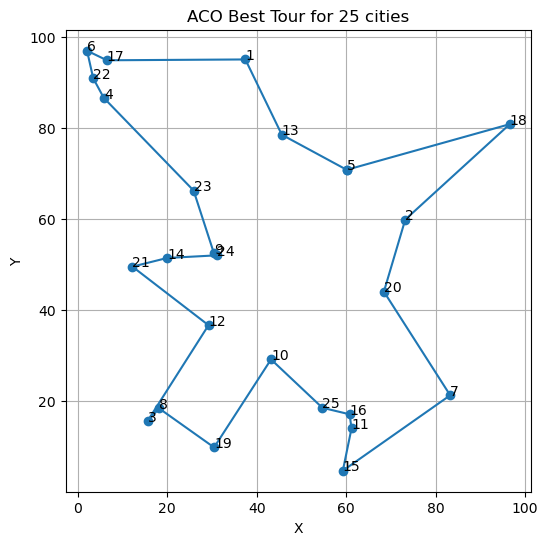

Plotting best tour for 30 cities (Distance: 451.767)


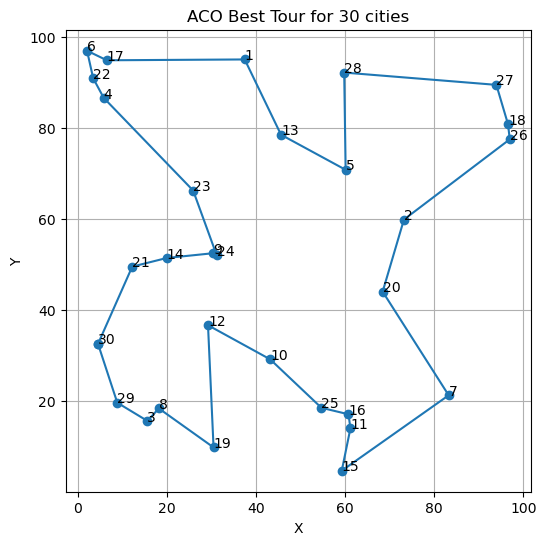

Plotting best tour for 35 cities (Distance: 464.168)


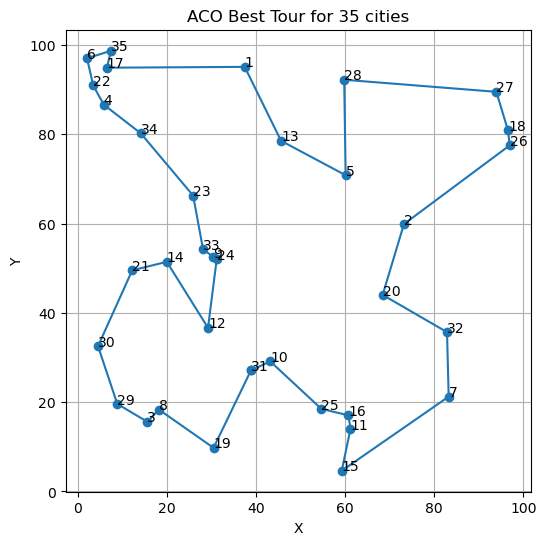

Plotting best tour for 40 cities (Distance: 496.798)


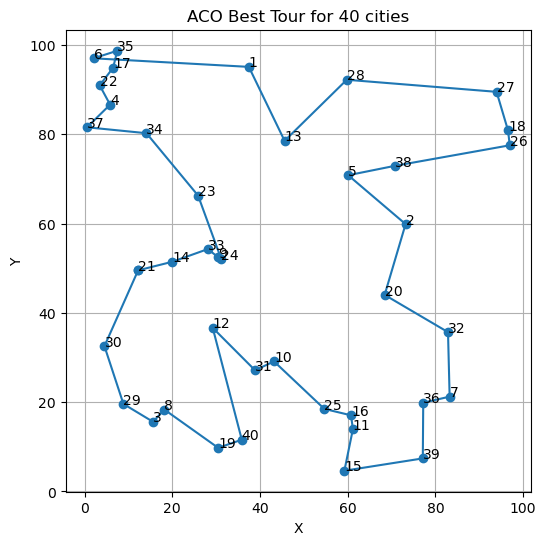

Plotting best tour for 45 cities (Distance: 533.528)


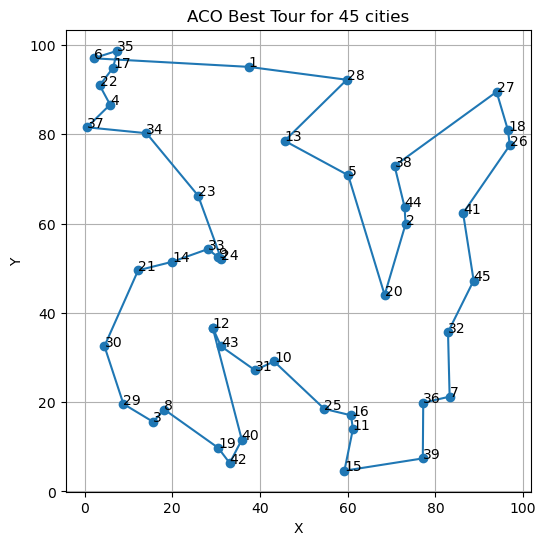

Plotting best tour for 50 cities (Distance: 564.626)


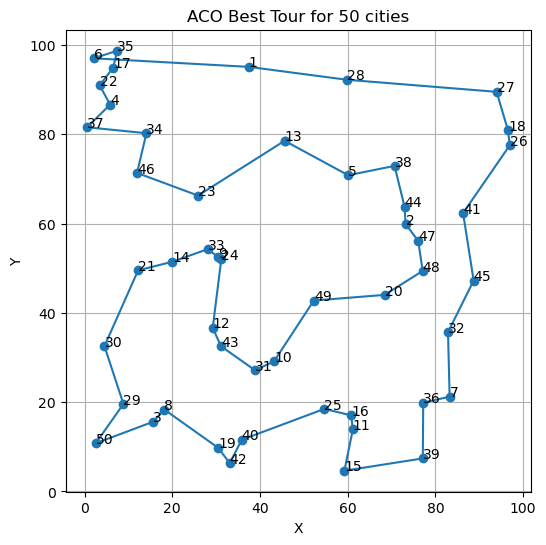

Saved best routes to TSP_best_routes_by_ACO.csv


In [55]:
"""
Here for the best seeds, best hyper parameters we are extracting the best tour from ACO
"""
# Generative AI help was taken to plot the tour but concept was own

# Load best hyperparameters
aco_params = pd.read_csv("../results/aco_tuning_best_fused.csv")
aco_params.set_index('num_cities', inplace=True)

# Load best seeds
best_seeds_df = pd.read_csv("../results/final_aco_results.csv")
best_seeds = []

for city in sorted(best_seeds_df["n_cities"].unique()):
    subset = best_seeds_df[best_seeds_df["n_cities"] == city]
    best_row = subset.loc[subset["best_distance"].idxmin()]
    best_seeds.append({
        "n_cities": city,
        "best_seed": best_row["seed"]
    })

best_seeds_df = pd.DataFrame(best_seeds)

# Load city coordinates
cities_df = pd.read_csv('../data/cities.csv')
def cities_based_on_numbers(number):
    return cities_df.head(number)[['X', 'Y']].values.astype(float)

# Function to run ACO and get best route
def run_aco_for_best_route(num_cities, seed=42):
    params = aco_params.loc[num_cities]
    cities = cities_based_on_numbers(num_cities)

    random.seed(seed)
    np.random.seed(seed)

    aco = AntColonyOptimization(
        cities=cities,
        n_ants=int(params['n_ants']),
        alpha=float(params['alpha']),
        beta=float(params['beta']),
        evaporation_rate=float(params['evaporation_rate']),
        q=float(params['q']),
        max_iterations=int(params['max_iterations'])
    )

    best_tour, best_distance = aco.solve()

    # Convert to human-readable format
    route_str = " -> ".join([f"City_{i+1}" for i in best_tour])

    return cities, best_distance, best_tour, route_str

# Function to plot tour
def plot_tour(coords, tour, title="TSP Tour"):
    tour_c = tour + [tour[0]]  # close the loop
    xs = coords[tour_c, 0]
    ys = coords[tour_c, 1]

    plt.figure(figsize=(6, 6))
    plt.plot(xs, ys, marker='o', linestyle='-')
    for i, txt in enumerate(tour):
        plt.annotate(f"{txt+1}", (coords[tour[i]][0], coords[tour[i]][1]))
    plt.title(title)
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.grid(True)
    plt.show()

# Collect all best routes and plot
all_best_routes = []

for _, row in best_seeds_df.iterrows():
    n = int(row['n_cities'])
    seed = int(row['best_seed'])
    
    cities_coords, best_distance, best_tour, best_route = run_aco_for_best_route(n, seed)
    
    # Save info
    all_best_routes.append({
        "n_cities": n,
        "best_seed": seed,
        "best_distance": best_distance,
        "best_route": best_route
    })
    
    # Plot the best tour
    print(f"Plotting best tour for {n} cities (Distance: {best_distance:.3f})")
    plot_tour(cities_coords, best_tour, title=f"ACO Best Tour for {n} cities")

best_routes_df = pd.DataFrame(all_best_routes)
# Save to CSV
best_routes_df.to_csv("../results/TSP_best_routes_by_ACO.csv", index=False)
print("Saved best routes to TSP_best_routes_by_ACO.csv")

# Conclusion

City sizes 5 and 10:

* Means are identical → t-test returns NaN because there’s no variance (all runs gave the same result).
* No difference between Tabu and ACO here.

City sizes 15–50:

* p-values < 0.05 from 25 cities onward → difference is statistically significant.
* ACO has lower mean distance than Tabu Search consistently.
* t-statistics are positive when Tabu mean > ACO mean, negative when Tabu mean < ACO mean (for smaller sizes some minor fluctuations).

Based on paired t-tests comparing Tabu Search and ACO across multiple seeds and varying city sizes, we observe that ACO significantly outperforms Tabu Search for medium to large problem instances (25–50 cities). For small instances (5–20 cities), both algorithms perform similarly. This indicates that ACO provides better robustness and scalability in terms of minimizing total distance.

# Reference 

Machine Learning Mastery (2021) Simulated annealing from scratch in Python. Available at: https://machinelearningmastery.com/simulated-annealing-from-scratch-in-python/ [Accessed: 16 November 2025].

Wikipedia (no date) Euclidean distance. Available at: https://en.wikipedia.org/wiki/Euclidean_distance [Accessed: 16 November 2025].

Flexiple (no date) Calculate distance in Python. Available at: https://flexiple.com/python/calculate-distance-python [Accessed: 16 November 2025].

Zhan, S. et al. (2016) ‘List-based simulated annealing algorithm for traveling salesman problem’, Computational Intelligence and Neuroscience, 2016, Article ID 1712630. Available at: https://pmc.ncbi.nlm.nih.gov/articles/PMC4808530/ [Accessed: 18 November 2025].

GeeksforGeeks (2025) Difference between hill climbing and simulated annealing algorithm. Available at: https://www.geeksforgeeks.org/machine-learning/difference-between-hill-climbing-and-simulated-annealing-algorithm/ [Accessed: 25 November 2025].

Tutorialspoint (no date) Difference between hill climbing and simulated annealing algorithm. Available at: https://www.tutorialspoint.com/difference-between-hill-climbing-and-simulated-annealing-algorithm [Accessed: 25 November 2025].

Medium (2021) Tabu search in Python. Available at: https://medium.com/swlh/tabu-search-in-python-3199c44d44f1 [Accessed: 27 November 2025].

Guo, B., Hu, J., Wu, W., Peng, Q. and Wu, F. (2019) ‘The Tabu_Genetic algorithm: A novel method for hyper-parameter optimization of learning algorithms’, Electronics, 8(5), p. 579. Available at: https://www.mdpi.com/2079-9292/8/5/579 [Accessed: 27 November 2025].

Train in Data (2025) Grid search vs random search: which one should you use? Available at: https://www.blog.trainindata.com/grid-search-vs-random-search-which-one-should-you-use/ [Accessed: 28 November 2025].

‘Discrete comprehensive learning particle swarm optimization algorithm with Metropolis acceptance criterion for traveling salesman problem’ (2018) [Journal details unknown]. Available at: https://www.sciencedirect.com/science/article/abs/pii/S2210650216304680 [Accessed: 28 November 2025].

Elloumi, W., El Abed, H., Abraham, A. and Alimi, A. M. (2014) ‘A comparative study of the improvement of performance using a PSO modified by ACO applied to TSP’, Applied Soft Computing, 25. Available at: https://www.sciencedirect.com/science/article/abs/pii/S1568494614004840 [Accessed: 28 November 2025].

‘NeuFACO: Neural focused ant colony optimization for traveling salesman problem’ (2025) arXiv preprint. Available at: https://arxiv.org/html/2509.16938v1 [Accessed: 28 November 2025].

Machine Learning Mastery (2021) A gentle introduction to particle swarm optimization. Available at: https://machinelearningmastery.com/a-gentle-introduction-to-particle-swarm-optimization/ [Accessed: 28 November 2025].

‘Comparative analysis of ant colony and particle swarm optimization algorithms for distance optimization’ (2020) [Conference paper]. Available at: https://www.sciencedirect.com/science/article/pii/S1877050920315337 [Accessed: 28 November 2025].

Ant Colony Optimization in Action (2023). Available at: https://towardsdatascience.com/ant-colony-optimization-in-action-6d9106de60af/ [Accessed: 29 November 2025]

Tabu search Algorithm (no date). Available at: https://python.algorithmexamples.com/web/searches/tabu_search.html#:~:text=The%20tabu%20search%20algorithm%20begins,the%20quality%20of%20the%20solution. 
[Accessed: 30 November 2025]

GeeksforGeeks (2025) Traveling salesman problem using genetic algorithm. Available at: https://www.geeksforgeeks.org/dsa/traveling-salesman-problem-using-genetic-algorithm/ [Accessed: 29 November 2025].

Chatgpt (2025) Available at: https://chat.openai.com [Accessed: 29 November 2025]
